# Анализ данных

Установим необходимые библиотеки

In [ ]:
!pip install -q dtaianomaly numba==0.61.2 optuna ruptures umap-learn

In [ ]:
!git clone https://github.com/83160574CKW/Neural-GC.git

Cloning into 'Neural-GC'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 45 (delta 1), reused 0 (delta 0), pack-reused 43 (from 1)
Receiving objects: 100% (45/45), 1.09 MiB | 2.94 MiB/s, done.
Resolving deltas: 100% (21/21), done.


Импортируем их

In [ ]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.decomposition import PCA, KernelPCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from dtaianomaly.anomaly_detection import (
    IsolationForest,
    KMeansAnomalyDetector,
    MatrixProfileDetector
)

from optuna import create_study
from optuna.distributions import (
    CategoricalDistribution,
    FloatDistribution,
    IntDistribution
)

from ruptures import Binseg, BottomUp
from ruptures.metrics import (
    hausdorff,
    precision_recall,
    randindex
)

from umap import UMAP

import sys

project_path = '/content/Neural-GC'
if project_path not in sys.path:
    sys.path.append(project_path)

from models.clstm import cLSTM, train_model_gista as train_clstm
from models.cmlp import cMLP, train_model_gista as train_cmlp

import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch

import random

from tqdm.auto import tqdm

from typing import Iterable

Напишем функцию для фиксирования всех неопределённостей

In [ ]:
random_state = 42

def set_random_seed(random_seed=random_state):
    globals()['RANDOM_SEED'] = random_seed
    random.seed(random_seed)
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)

Определим девайс, на котором будет происходить обучение

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

В качетве данных для поиска аномалий будет использовать SKAB (Skoltech anomaly benchmark) - данные собраны с реального промышленного стенда с водяным насосом и трубопроводом в Сколтехе

Для каждого отдельного файла (эксперимента) еть следующие 10 признаков:
- Accelerometer1RMS - вибрационное ускорение первого датчика в насосе (измеряется в g)
- Accelerometer2RMS - вибрационное ускорение второго датчика в насосе (измеряется в g)
- Current - сила тока в электродвигателе (измеряется в Амперах)
- Voltage - напряжение в электродвигателе (измеряется в Вольтах)
- Pressure - давление в контуре после водяного насоса (измеряется в Барах)
- Temperature - температура корпуса двигателя (измеряется в градусах Цельсия)
- Thermocouple - температура жидкости в циркулярном контуре (измеряется в градусах Цельсия)
- Volume Flow RateRMS - объёмная скорость потока жидкости (измеряется в литрах в минуту)
- anomaly - является ли объект аномалией
- changepoint - является ли момент времени переключением точки режима (точкой изменения, changepoint)

Итак, разархивируем эти данные

In [ ]:
!unzip -q SKAB.zip && rm SKAB.zip

Я выбрал данные из эксперимента valve1 - когда частично перекрывается выходной поток жидкости (output flow closure). Это классический отказ промышленного оборудования, при котором клапан на выходе насоса прикрывается, изменяя гидравлическое сопротивление системы

Какие последствия:
- Гидравлическое сопротивление контура возрастает
- Давление после насоса растёт, потому что системе сложнее "продавить" жидкость
- Потребляемый ток увеличивается – насос тратит больше энергии
- Поток жидкости (объёмная скорость) падает
- Температура двигателя и жидкости постепенно повышается
- Напряжение при этом остаётся практически неизменным

Собственно, аномалиями в датасете считаются именно временные точки, соответствующие проведению эксперимента (примерно 40% данных каждого файла), а точками изменениями - начало и конец эсперимента (2 на файл). Получается, ч о в наем случае аномалии групповые

Объединим все файлы в один (благо, эксперименты проводились последовательно)

In [ ]:
base_dir = 'SKAB/valve1'
files = {
    int(file[:-4]): pd.read_csv(f'{base_dir}/{file}', sep=';') \
    for file in list(os.listdir(base_dir))
}
for key, value in files.items():
    files[key] = value.assign(
        datetime=lambda x: pd.to_datetime(x['datetime'])
    ).set_index('datetime')
files = dict(sorted(files.items()))
experiments = pd.concat(files.values())
experiments.index.name = 'datettime'
experiments[['anomaly', 'changepoint']] = experiments[
    ['anomaly', 'changepoint']
].astype(int)
X, y = (
    experiments.drop(columns=['anomaly', 'changepoint']),
    experiments[['anomaly', 'changepoint']]
)

Напишем функцию для отображения признаков и указания точек аномалий

In [ ]:
def plot_features_with_anomalies(
    df,
    plot_anomalies=True,
    plot_changepoints=False,
    start_date=None,
    end_date=None,
    found_anomalies=None,
    found_changepoints=None,
    figsize=(18, 6),
    ncols=1,
    s=100
):
    used = False
    if isinstance(ncols, int):
        ncols = [ncols]
    begin = 0
    for local_ncols in ncols:
        axes = plt.subplots(ncols=local_ncols, figsize=figsize)[1]
        if local_ncols == 1:
            axes = np.array([axes])
        for feature, ax in zip(
            df.columns[begin:(begin + axes.shape[0])],
            axes
        ):
            ax.plot(df[feature], color='blue')
            if start_date is not None:
                ax.vlines(
                    start_date,
                    df[feature].min(),
                    df[feature].max(),
                    color='green',
                    label='Начало аномалии'
                )
            if end_date is not None:
                ax.vlines(
                    end_date,
                    df[feature].min(),
                    df[feature].max(),
                    color='green',
                    label='Конец аномалии'
                )
            if plot_anomalies:
                anomalies = df[df['anomaly'] == 1]
                ax.scatter(
                    anomalies.index,
                    anomalies[feature],
                    color='red',
                    s=s
                )
            if plot_changepoints:
                changepoints = df[df['changepoint'] == 1]
                ax.scatter(
                    changepoints.index,
                    changepoints[feature],
                    color='purple',
                    s=s
                )
            if found_anomalies is not None:
                subsample = df.iloc[np.where(found_anomalies == 1)[0]]
                ax.scatter(
                    subsample.index,
                    subsample[feature],
                    color='orange',
                    s=s // 2
                )
            if found_changepoints is not None:
                subsample = df.iloc[found_changepoints[:-1]]
                ax.scatter(
                    subsample.index,
                    subsample[feature],
                    color='yellow',
                    s=s // 2
                )
            ax.set_title(feature)
        if not used:
            plt.suptitle('Признаки с отмеченными аномалиями')
            used = True
        begin += axes.shape[0]
        plt.tight_layout()
    plt.show()

Визуализируем признаки

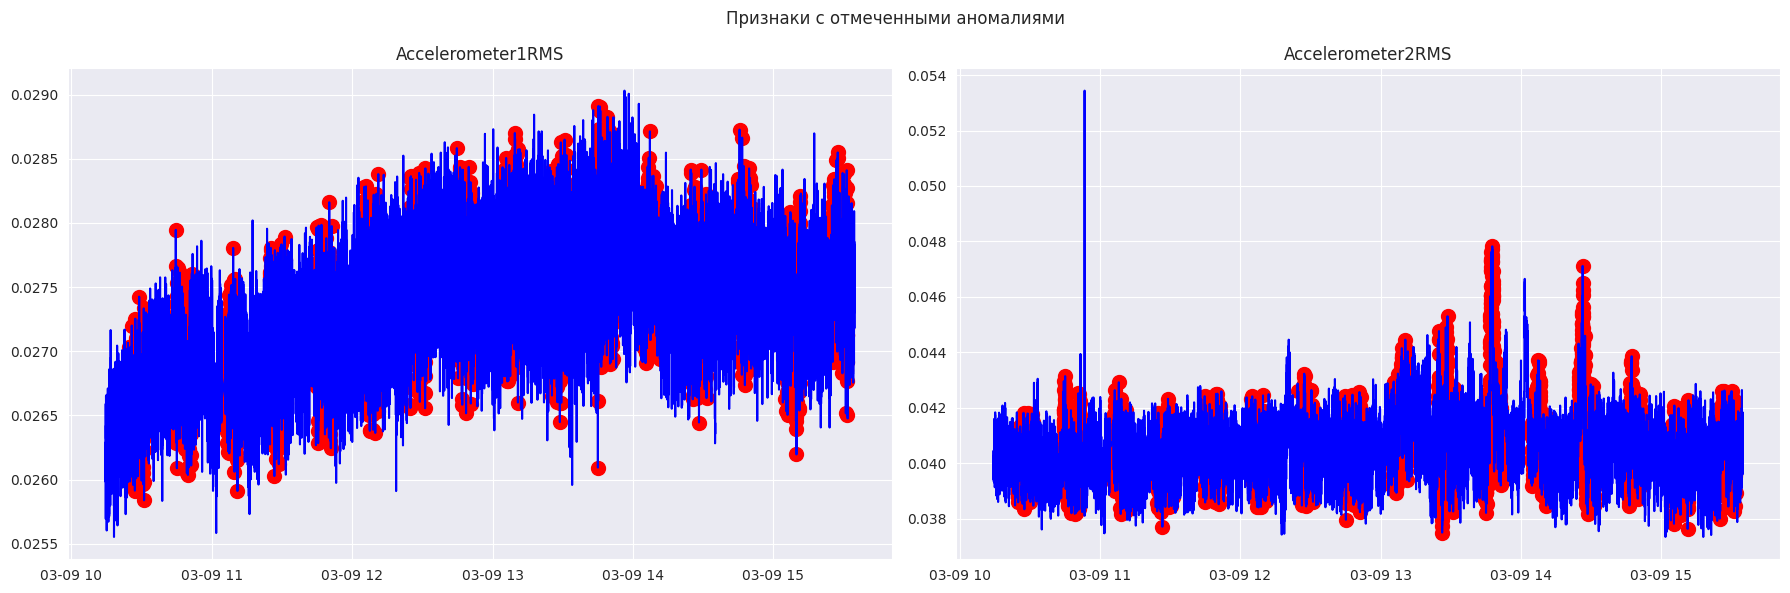

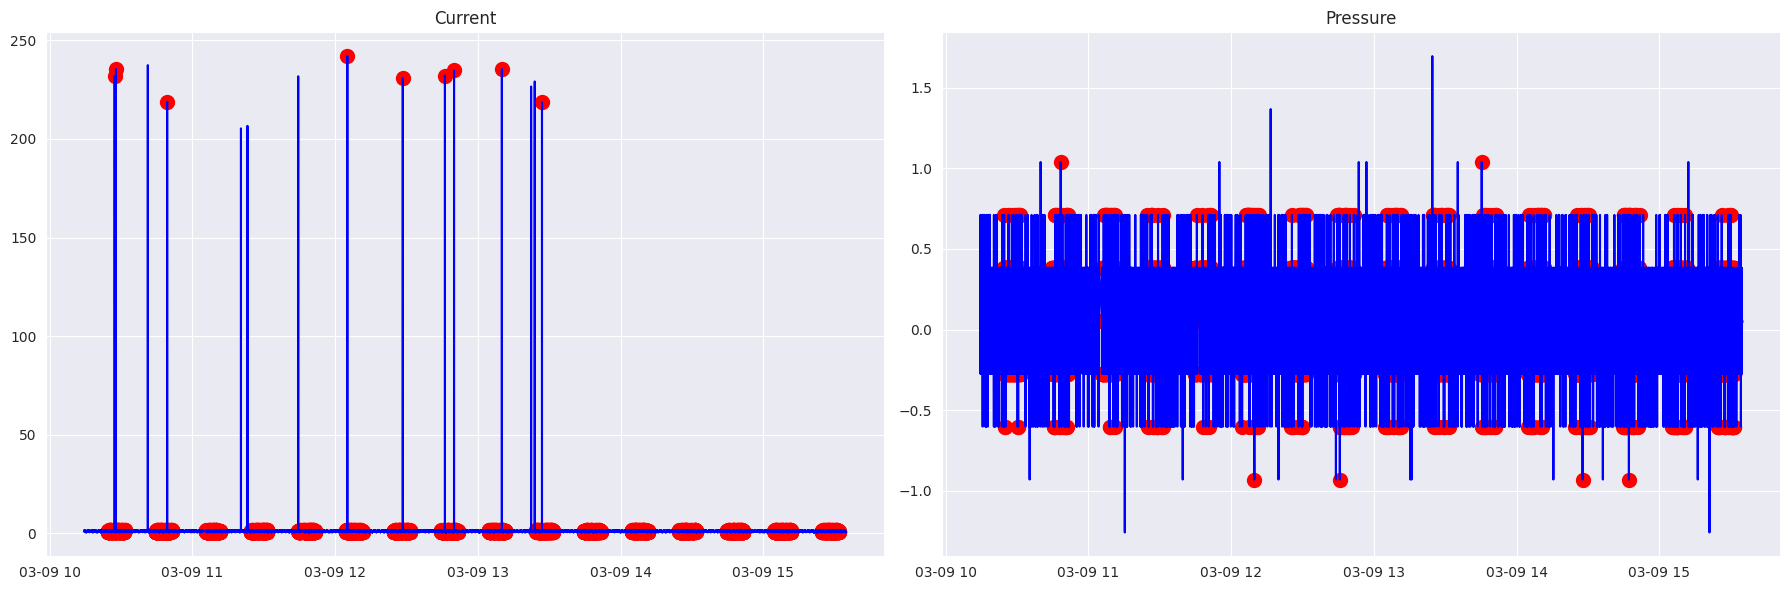

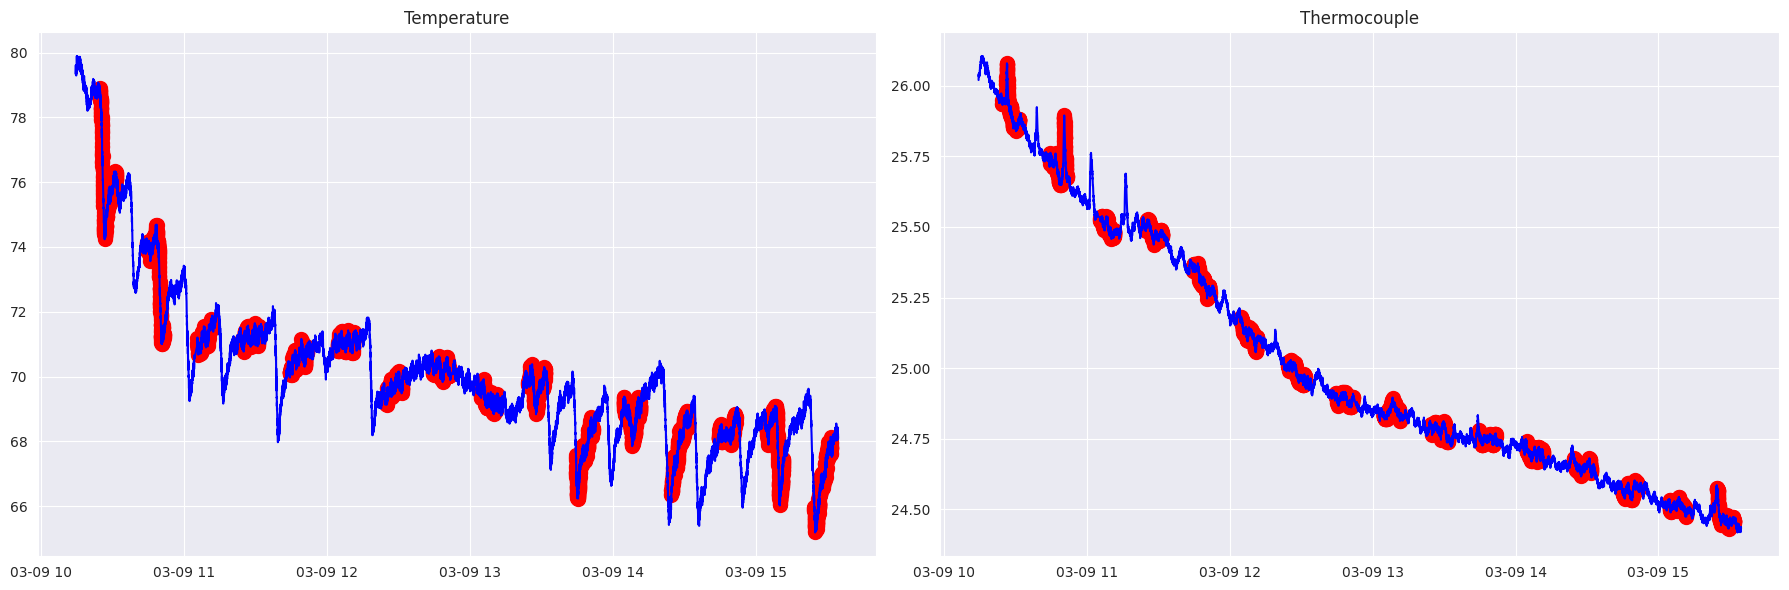

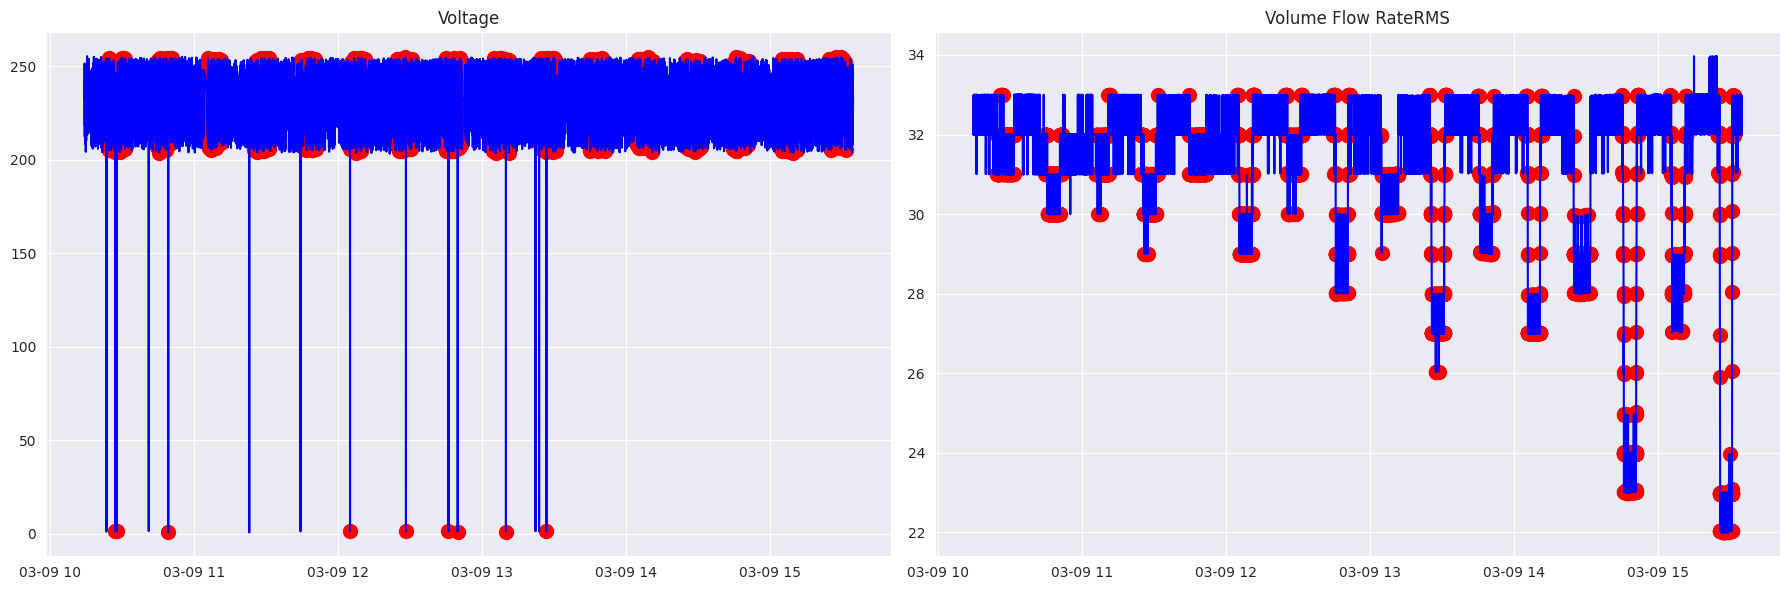

In [ ]:
plot_features_with_anomalies(experiments, ncols=[2] * 4)

Мне пришла в голову б̶е̶з̶у̶м̶н̶а̶я̶ идея, заключающаяся в том, чтобы заполнить пропушенные значения в даныных (в ежесекундных данных есть пропуски)

Там, где пропуски единичные, мы просто линейно интерполируем их, а вот там, где есть более серьёзные пропуски (данных нет несколько десятков секунд), уже нужно попробовать нечто другое - и это другое является Гауссовским процессом с добавлением шума

Итак, Гауссовский процесс — это байесовский непараметрический метод регрессии. Он не учит фиксированную функцию, а работает с распределением над функциями. На выходе мы получаем не только предсказание, но и оценку неопределённости (дисперсию)

Вместо того чтобы искать одну «лучшую» функцию $\large{f(x)}$, мы задаём априорное распределение над всеми возможными функциями. Когда приходят данные $\large{(X, y)}$, мы обновляем это распределение через теорему Байеса и получаем апостериорное распределение $\large{p(f|x,y)}$

Гауссовский процесс — это распределение над функциями, полностью задаваемое:
- Средним функции $\large{}m(x)=\mathbb{E}\left[f(x)\right]$
- Ковариационной функцией (ядром) $\large{k(x,x')=Cov\left(f(x),f(x')\right)}$

Обозначается как $\large{f(x) \sim \mathcal{GP}(m(x),k(x,x'))}$ (пол умолчанию среднее $\large{m(x)}$ равно нулю)

Итак, путь есть обучающая выборка $\large{X} \in \mathbb{R}^{T \times p}$ и целевые значения $\large{y} \in \mathbb{R}^{T \times r}$. Совместное распределение значений функции в точках $\large{X}$ — многомерное нормальное:
$$\large{f=\left(f(x_1),...,f(x_n)\right) \sim \mathcal{N}\left(0, K(X, X)\right),}$$
где $\large{K(X, X)}$ - ковариационная матрица размерами $\large{n \times n}$:
$$\large{K(X, X)=\begin{pmatrix}k(x_1, x_1) \ \ldots \ k(x_1, x_T) \\ \vdots \quad \quad \ddots \quad \quad \vdots \\ k(x_T, x_1) \ \ldots \ k(x_T, x_T)\end{pmatrix}}$$

Ядро $\large{k(x, x')}$ определяет "гладкоть" и структуру функций. У меня в работе используется сумма 2 ядер:
- Ядро с радиальными базисными функциями (RBF) - $\large{k(x, x')=\sigma^2e^{-\frac{\left|\left|x-x'\right|\right|^2}{2l^2}} \ ,}$
где:
   - $\large{\sigma^2}$ - амплитуда
   - $\large{l}$ - масштаб длины
- Ядрос белым шумом - $\large{k(x_i, x_j)=\sigma^2\delta_{ij} \ ,}$
где:
   - $\large{\sigma^2}$ - амплитуда

Наблюдаемые значения $\large{y}$ содержат шум $\large{\epsilon \sim \mathcal{N}(0, \sigma_T^2)}$:
$$\large{y_i=f(x_i) + \epsilon}$$

Поэтому ковариационная матрица для наблюдаемых значений дополняется шумом:
$$\large{K_y=K(X, X) + \sigma_T^2I_T}$$

Совместное же распределение наблюдений выглядит следующим образом:
$$\large{y \sim \mathcal{N}(0, K_y)}$$

Итак, пусть теперь есть тестоые точки $\large{X^*}$ и мы хотим узнать апостериорные значения их целевых переменных $\large{y^*}$ при условии наблюдаемых данных. Оно имеет следующий вид:
$$\large{\begin{pmatrix}y \\ y^*\end{pmatrix} \sim \mathcal{N}\begin{pmatrix}K_y \quad \quad \quad \quad K(X, X^*) \\ K(X^*, X) \quad K(X^*, X^*)\end{pmatrix} \ ,}$$
где:
- $\large{K(X, X^*)}$ - матрица размера $\large{T \times V}$ ковариаций между обучающими и тестовыми точками
- $\large{K(X^*, X^*)}$ - матрица размера $\large{V \times V}$ ковариаций тестовых точек между собой

Гиперпараметры (например, $\large{l, \sigma^2, \sigma_T^2}$ в ядре) подбираются через максимизацию логарифмического маржинального правдоподобия (LML):
$$\large{LML(\theta)=-\log p(y|X, \theta)=-\frac{1}{2}y^TK_y^{-1}y - \frac{1}{2}\log\left|K_y\right| - \frac{T}{2}\log2\pi}$$

Теперь можно предсказать среднее и ковариацию для апостериорного раcпределения целевой переменной $\large{y^*}$:
- $\large{\overline{y^*} = K(X^*, X)K_y^{-1}y}$
- $\large{\sigma(y^*) = K(X^*, X) - K(X^*, X)K_y^{-1}K(X, X*)}$

Зная среднее и стандартное отклонение нормального распределения, можно нагенерировать много данных самостоятельно - именно таким образом и будут заполняться пропуски. Однако в моём алгоритме есть особенность - для каждого отрезка и каждого признака подбирается вручную отдельный фактор шума (noise factor), который домножается на найденное стандартное отклонение, чтобы чисто визуально всё выглядело более или менее правдоподобным



In [ ]:
experiments_full = pd.DataFrame(
    index=pd.date_range(
        start=experiments.index.min(),
        end=experiments.index.max(),
        freq='s'
    )
).merge(experiments, how='left', left_index=True, right_index=True)
X_full, y_full = (
    experiments_full.drop(columns=['anomaly', 'changepoint']),
    experiments_full[['anomaly', 'changepoint']]
)
y_full = y_full.interpolate()
y_full['anomaly'] = np.ceil(y_full['anomaly']).astype(int)
y_full['changepoint'] = y_full['changepoint'].astype(int)
X_full = X_full.interpolate(limit=1)

Итак, всего еть 3 временных отрезка, когда ежесекундные данные неизвестны:
1) 11:04:25-11:05:39
2) 11:45:34-11:46:36
3) 12:51:57-12:53:00

Эти пропуски и предстоит заполнить

In [ ]:
begin_indices = [
    '2020-03-09 11:04:24', '2020-03-09 11:45:43', '2020-03-09 12:51:56'
]
end_indices = [
    '2020-03-09 11:05:40', '2020-03-09 11:46:37', '2020-03-09 12:53:01'
]

Напишем функцию для заполнения пропусков с помощью Гауссовского процесса

Следует отметить, что для признаков Thermocouple и Volume Flow RateRMS в качестве заполнения будут браться следующие после пропуска значения, так как форма этих признаков слишком специфическая

In [ ]:
def gp_fill_dataframe(
    df,
    begin_date,
    end_date,
    noise_scales,
    border,
    length_scale=50,
    forward=None,
    up=None,
    random_state=random_state
):
    begin_index = df.index.get_loc(begin_date)
    end_index = df.index.get_loc(end_date)
    result = df.iloc[(begin_index - border):(end_index + border)].copy()
    local_begin = border
    local_end = local_begin + (end_index - begin_index)
    time = np.arange(len(result)).reshape(-1, 1)
    forward = forward or []
    up = up or {}
    for column in tqdm(
        result.columns,
        desc='Восстановление столбцов',
        total=len(result.columns)
    ):
        series = result[column]
        if column in forward:
            right_start = end_index + 1
            right_end = right_start + (end_index - begin_index + 1)
            right_values = df.iloc[right_start:right_end][column].values
            result.iloc[
                local_begin:local_end + 1,
                result.columns.get_loc(column)
            ] = right_values
        else:
            known_index = ~series.isna()
            unknown_index = series.isna()
            noise_scale = noise_scales[column]
            time_known = time[known_index]
            time_unknown = time[unknown_index]
            y_known = series[known_index].values
            kernel = RBF(length_scale=length_scale) + \
                WhiteKernel(noise_level=0.01)
            gp = GaussianProcessRegressor(
                kernel=kernel,
                alpha=0.0,
                random_state=random_state,
                n_restarts_optimizer=3,
            )
            gp.fit(time_known, y_known)
            y_mean, y_std = gp.predict(time_unknown, return_std=True)
            y_noisy = np.random.normal(
                loc=y_mean,
                scale=y_std * noise_scale,
                size=len(y_mean)
            )
            if column in up:
                y_noisy += up[column]
            result.loc[unknown_index, column] = y_noisy
    return result

С помощью этой функции свызововм предыдущей заполняется каждый отдельный пропуск

In [ ]:
def impute(
    df,
    begin_date,
    end_date,
    noise_scales,
    border=250,
    length_scale=50,
    up=None,
    forward=None
):
    result = gp_fill_dataframe(
        df,
        begin_date,
        end_date,
        noise_scales=noise_scales,
        border=border,
        length_scale=length_scale,
        up=up,
        forward=forward
    )
    df.loc[result.index] = result

Итак, заполняем!

In [ ]:
impute(
    X_full,
    begin_indices[0],
    end_indices[0],
    noise_scales={
        'Accelerometer1RMS': 0.075,
        'Accelerometer2RMS': 0.2,
        'Current': 0.5,
        'Temperature': 0.001,
        'Thermocouple': 0.1,
        'Voltage': 0.025,
    },
    up={
        'Temperature': 63,
        'Thermocouple': -0.03,
        'Voltage': 224
    },
    forward=['Pressure', 'Volume Flow RateRMS']
)

impute(
    X_full,
    begin_indices[1],
    end_indices[1],
    noise_scales={
        'Accelerometer1RMS': 0.075,
        'Accelerometer2RMS': 0.2,
        'Current': 0.05,
        'Temperature': 0.001,
        'Thermocouple': 0.5,
        'Voltage': 0.025,
    },
    up={
        'Temperature': 62.5,
        'Thermocouple': 0.01,
        'Voltage': 224
    },
    forward=['Pressure', 'Volume Flow RateRMS']
)

impute(
    X_full,
    begin_indices[2],
    end_indices[2],
    noise_scales={
        'Accelerometer1RMS': 0.1,
        'Accelerometer2RMS': 0.3,
        'Current': 0.05,
        'Temperature': 0.001,
        'Thermocouple': 0.5,
        'Voltage': 0.05,
    },
    up={
        'Temperature': 62,
        'Thermocouple': 0.01,
        'Voltage': 224
    },
    forward=['Pressure', 'Volume Flow RateRMS']
)

Восстановление столбцов:   0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Convergence

Восстановление столбцов:   0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Convergence

Восстановление столбцов:   0%|          | 0/8 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Convergence

Теперь надо отобразить реконструированные отрезки

In [ ]:
def plot_reconstructed_intervals(index, seconds=150, ncols=[2] * 4):
    begin = pd.to_datetime(begin_indices[index]) - pd.Timedelta(seconds=seconds)
    end = pd.to_datetime(end_indices[index]) + pd.Timedelta(seconds=seconds)
    time_interval = pd.concat([X_full.loc[begin:end], y_full.loc[begin:end]])
    plot_features_with_anomalies(
        time_interval,
        start_date=pd.to_datetime(begin_indices[index]),
        end_date=pd.to_datetime(end_indices[index]),
        ncols=ncols
    )

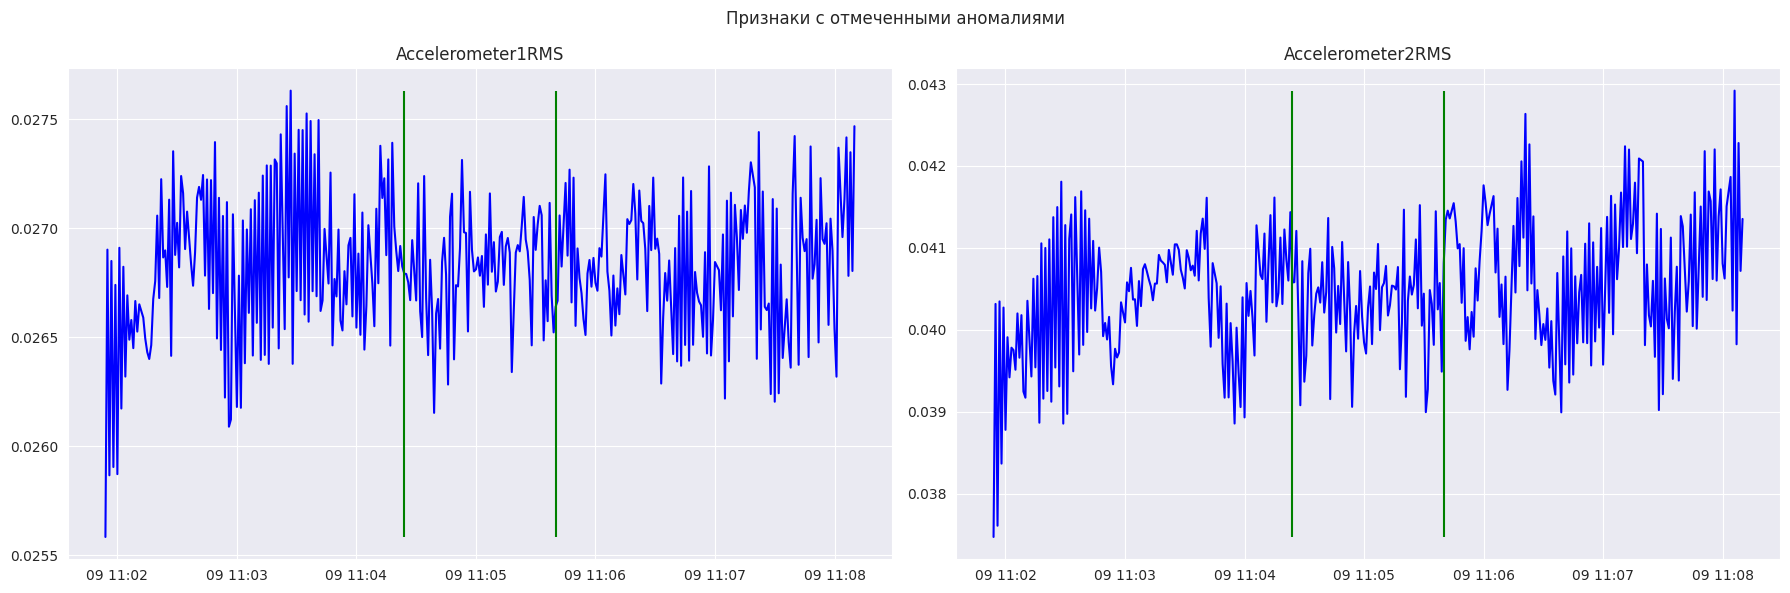

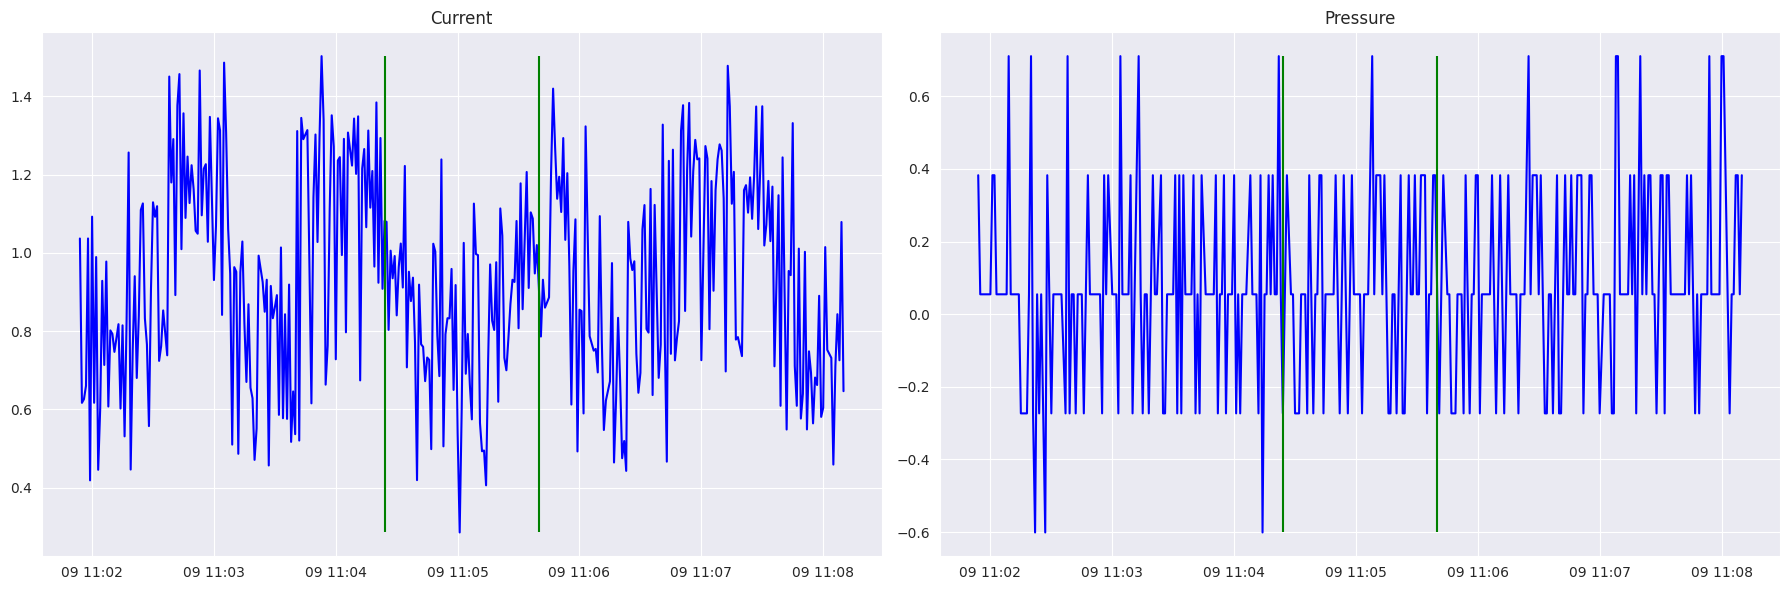

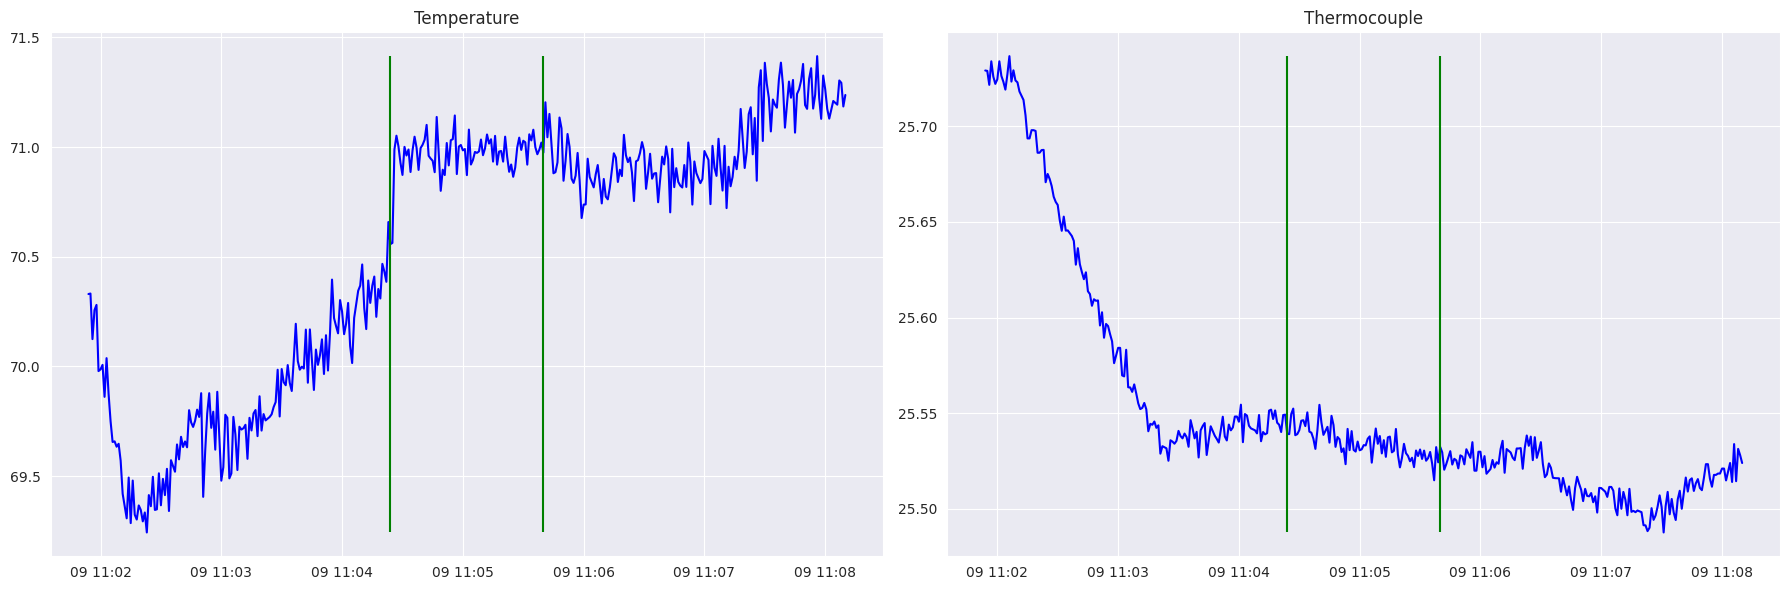

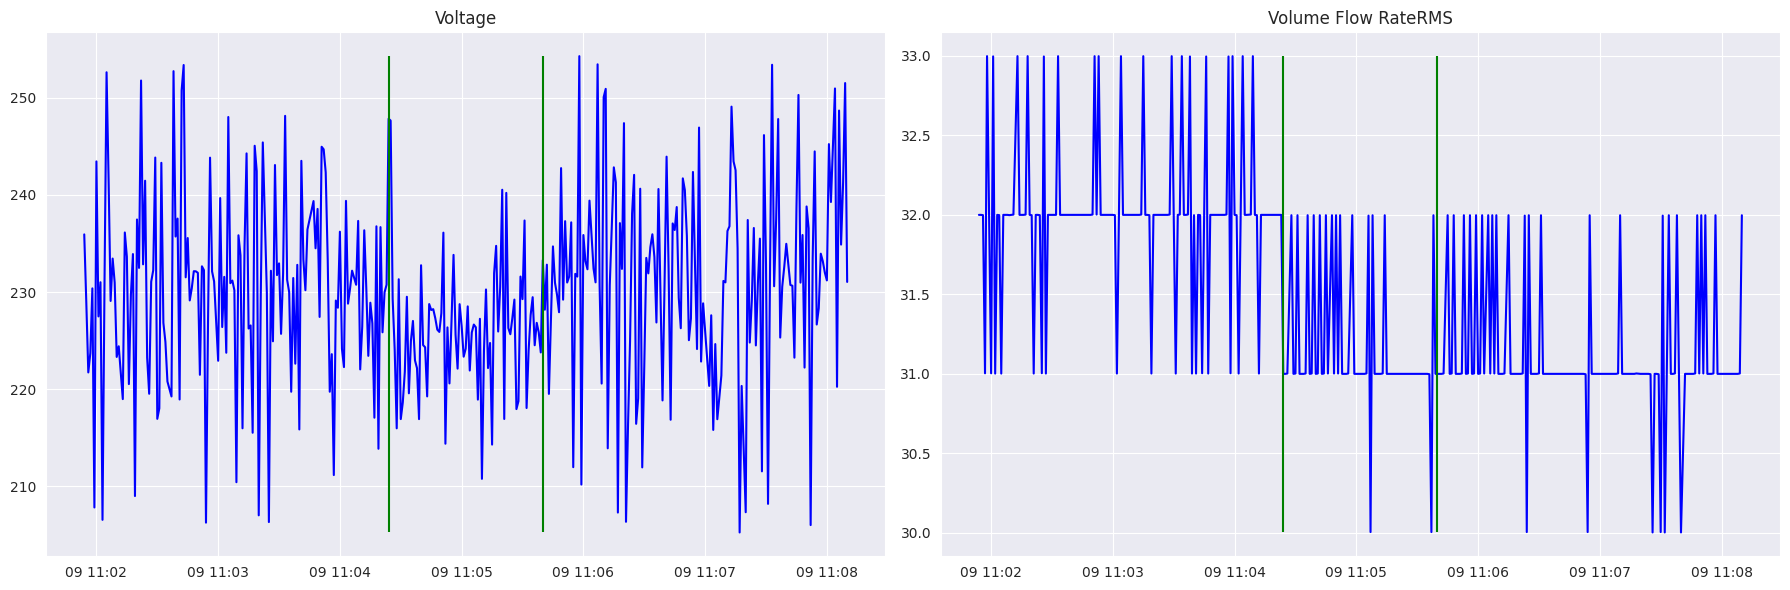

In [ ]:
plot_reconstructed_intervals(0)

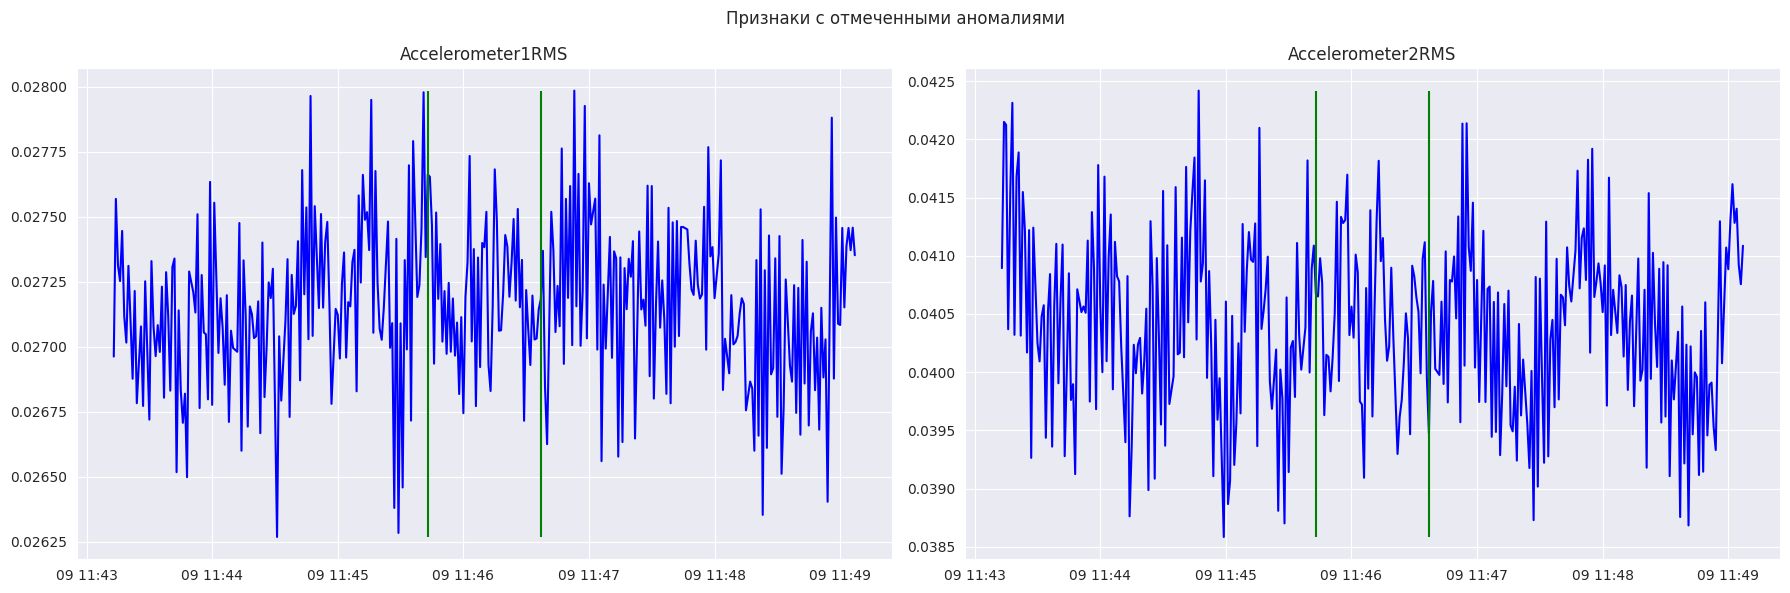

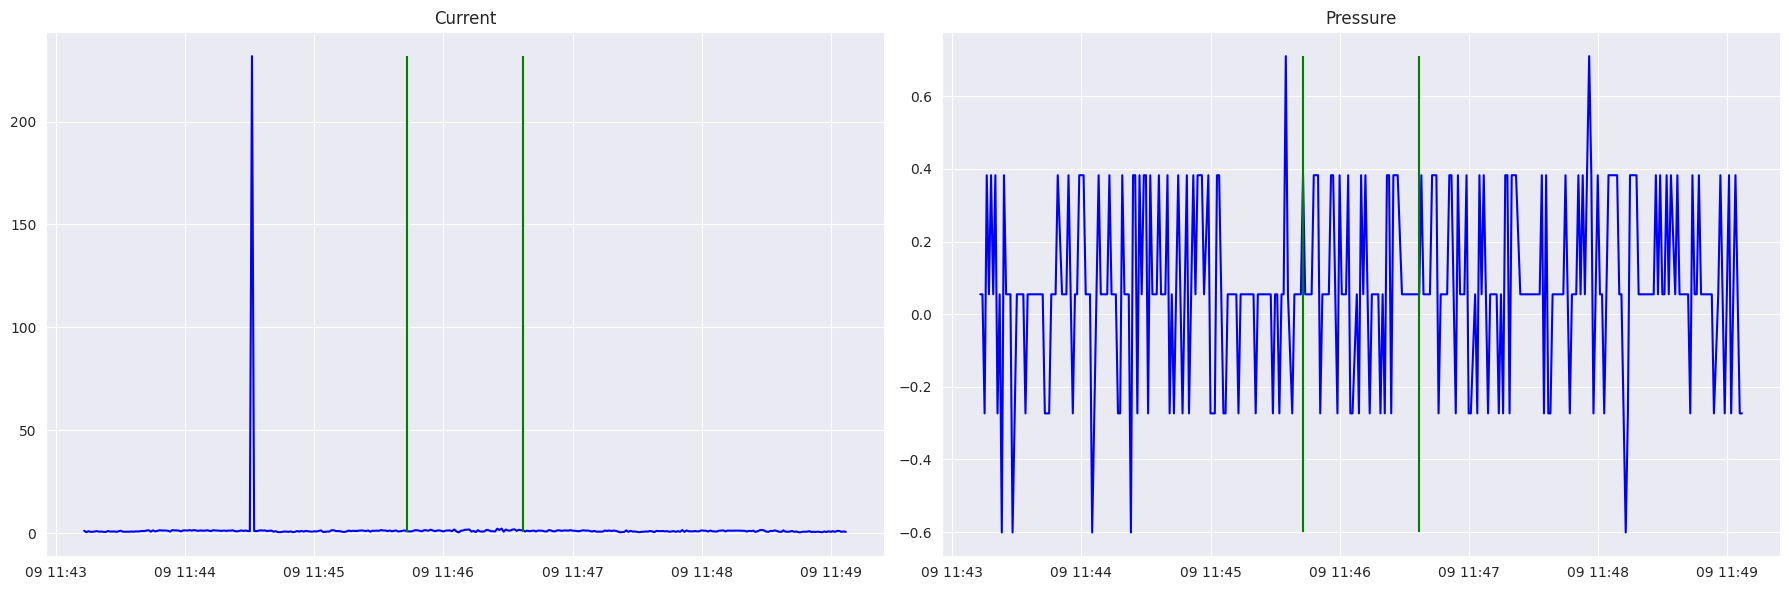

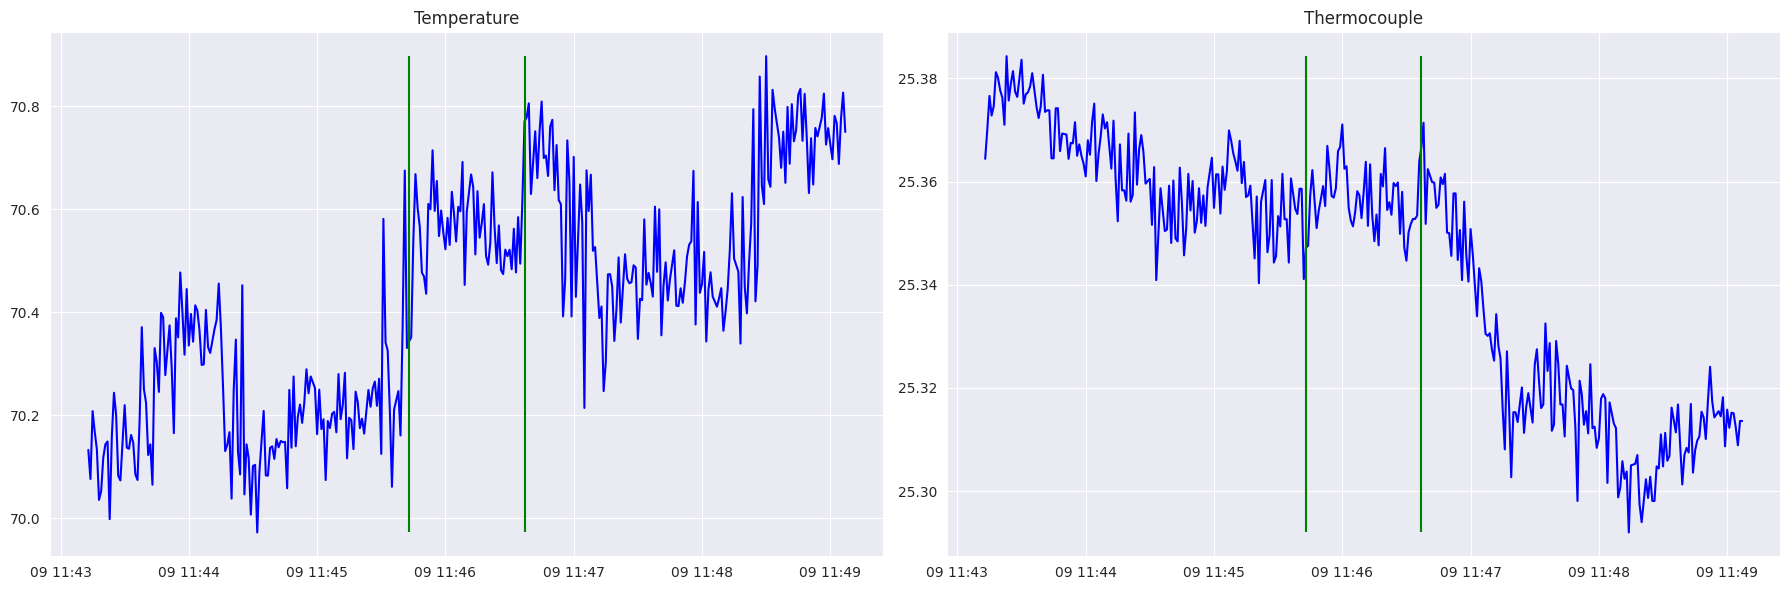

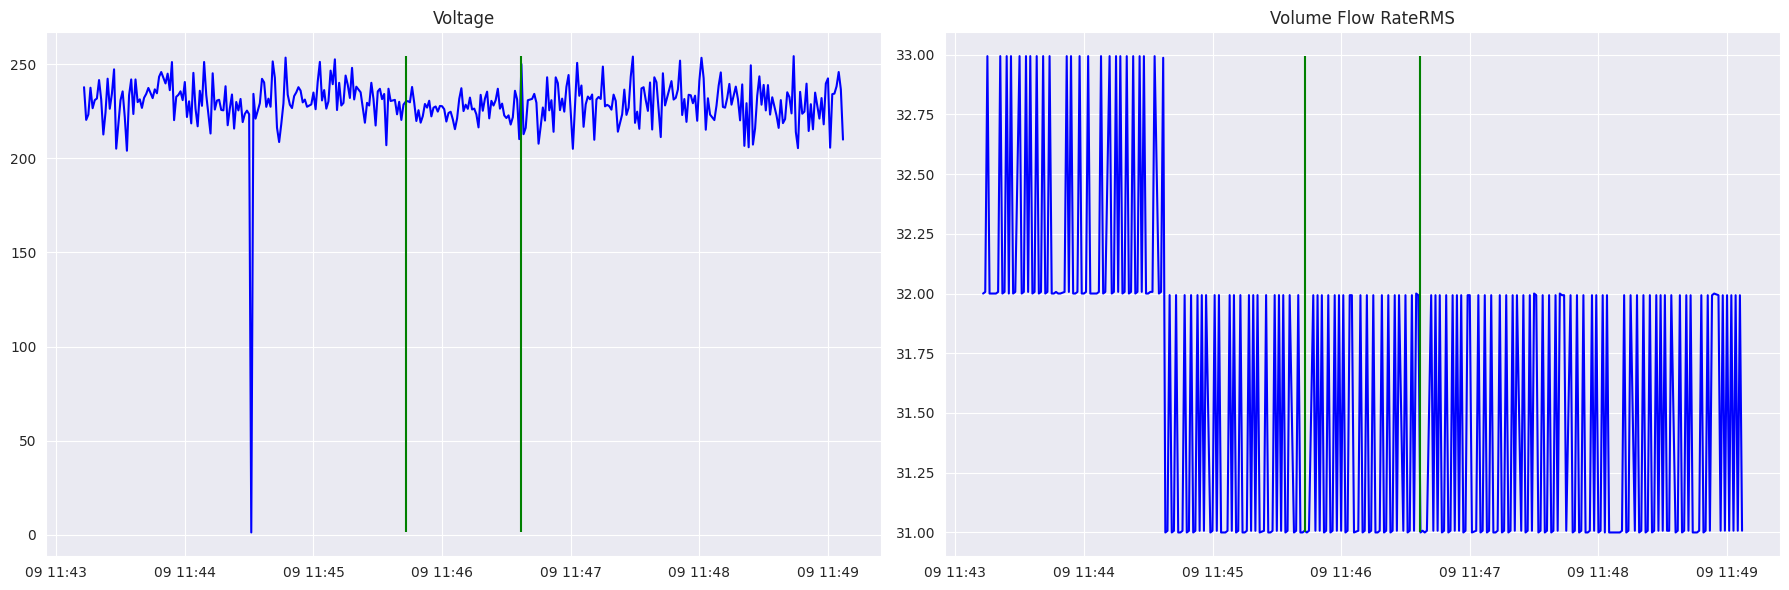

In [ ]:
plot_reconstructed_intervals(1)

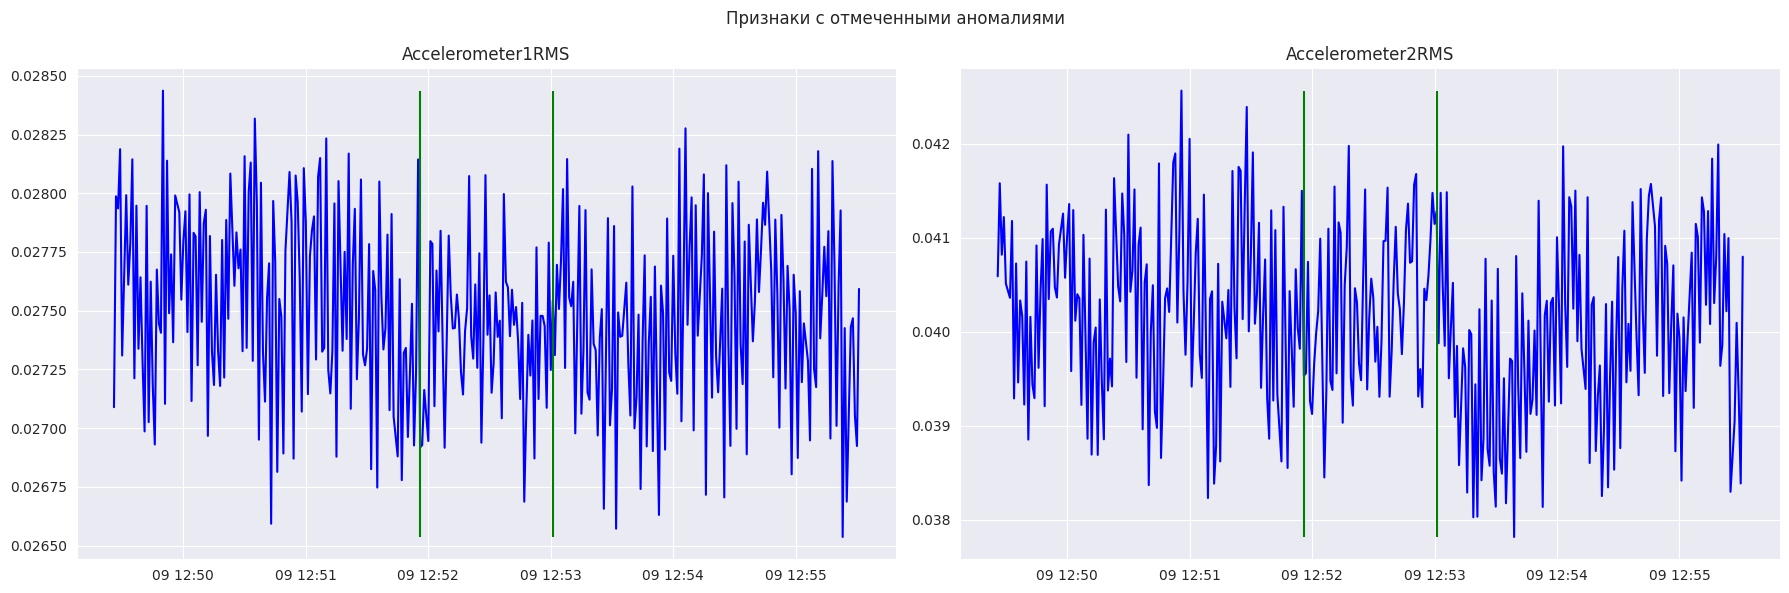

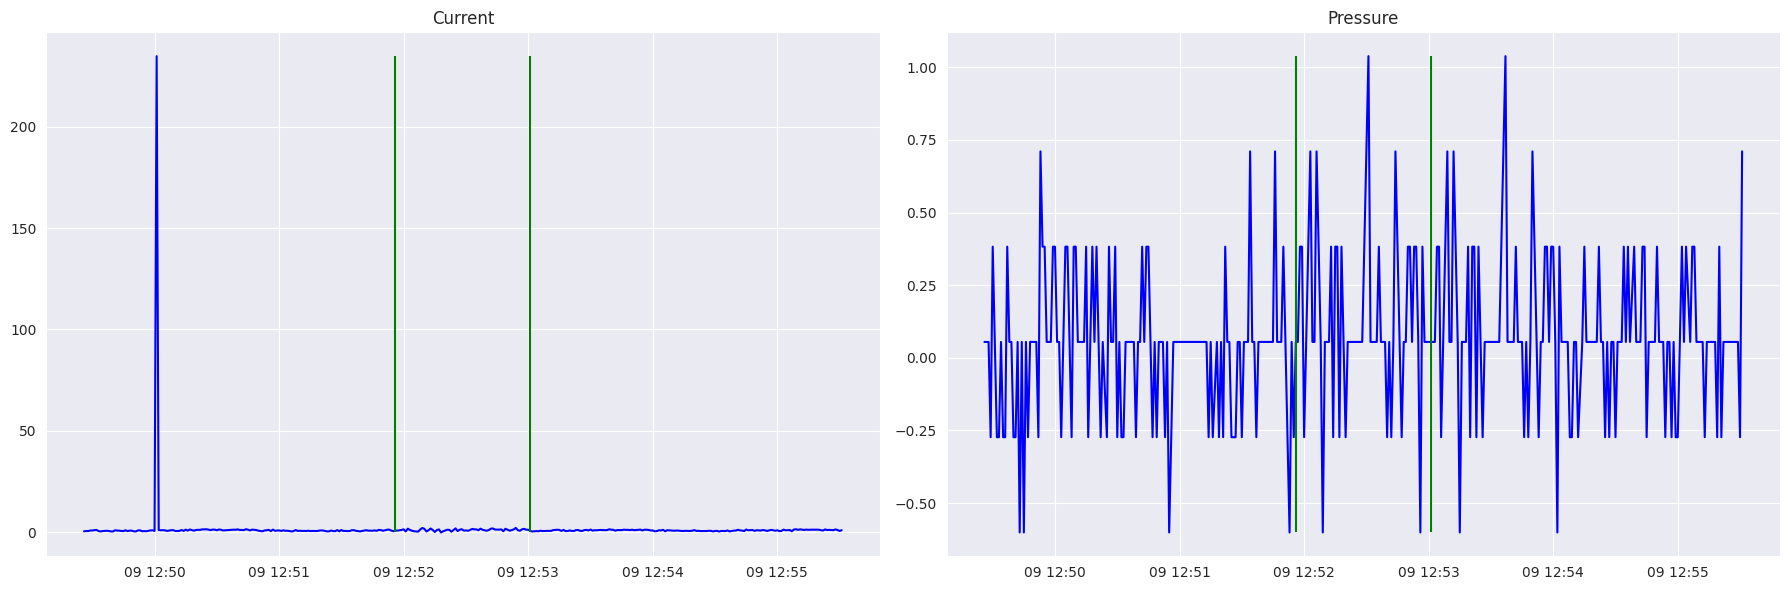

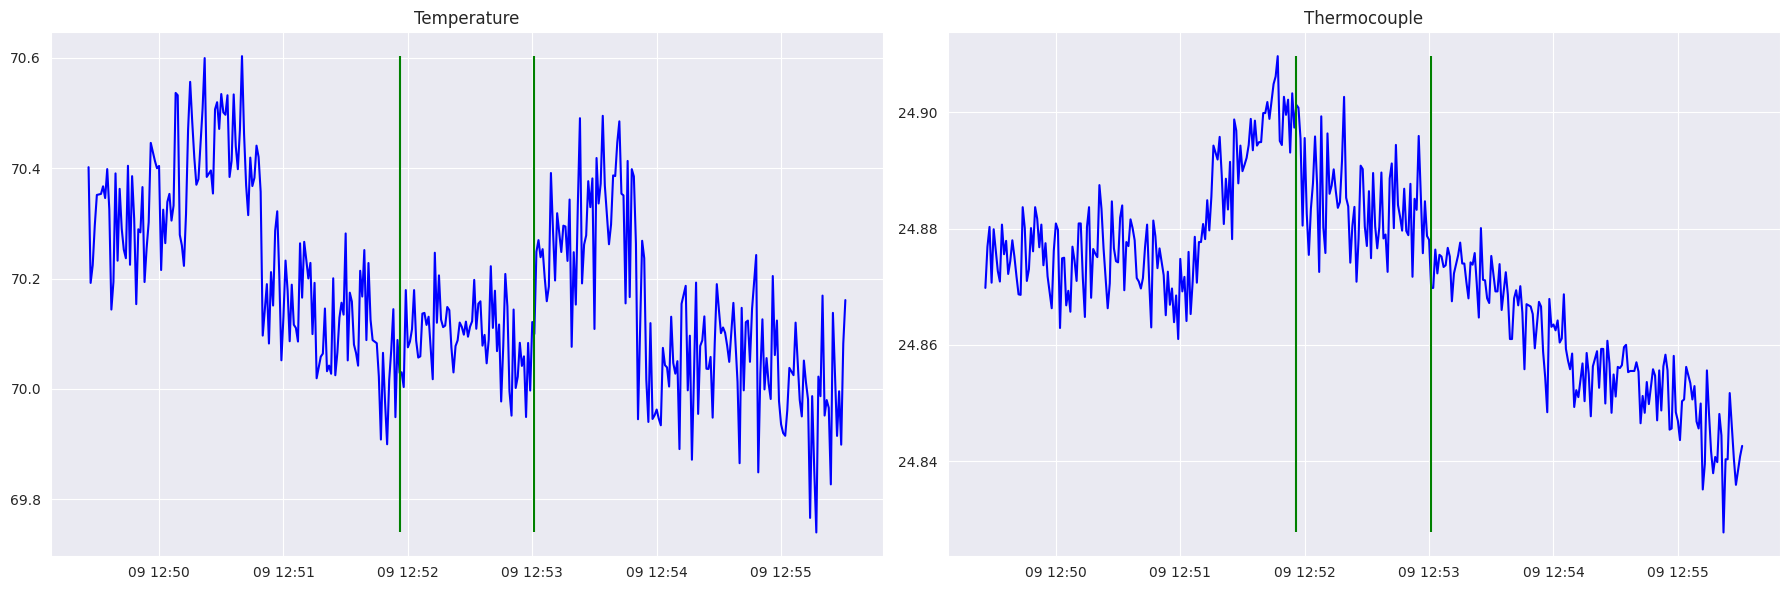

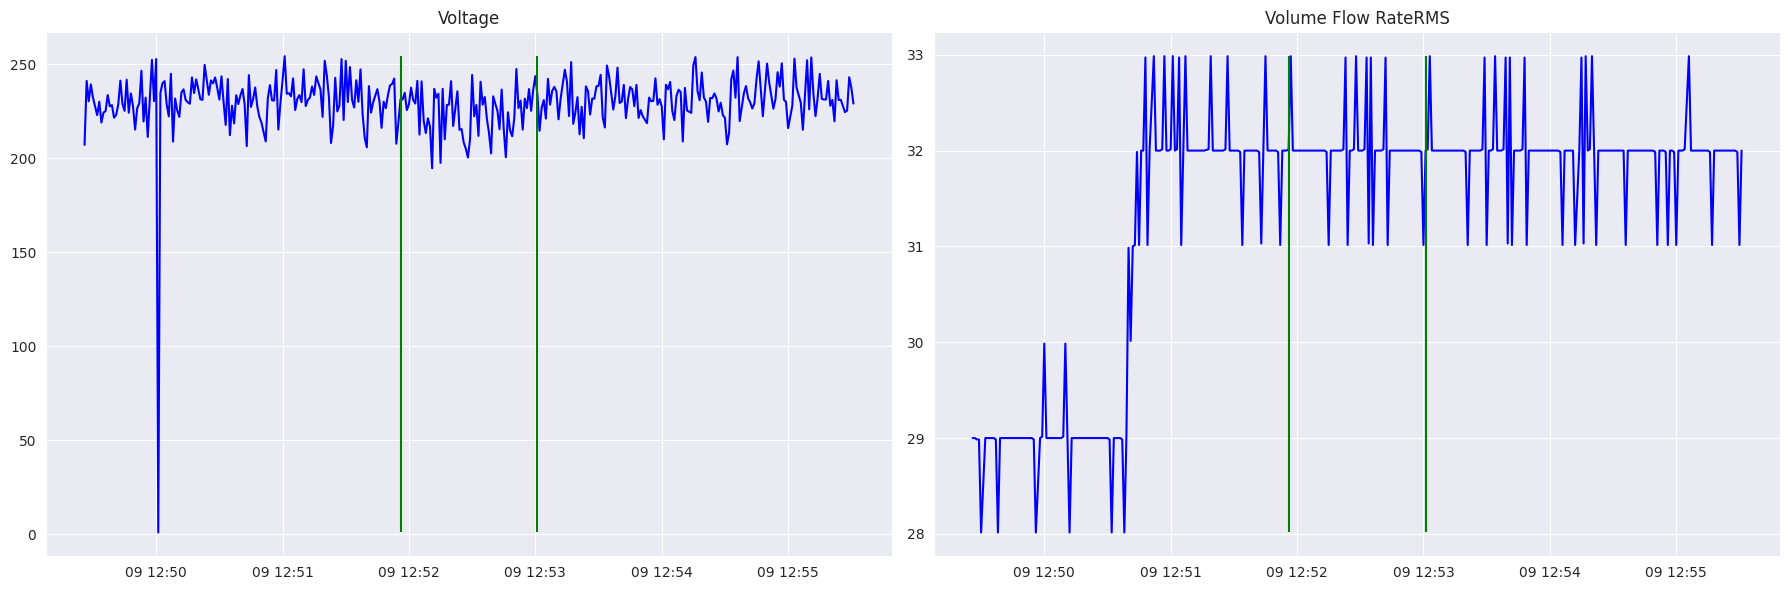

In [ ]:
plot_reconstructed_intervals(2)

Что ж, выглядит правдоподобно

Теперь заменим все отдельные файлы с учётом исправлений

In [ ]:
last_indices = np.array([
    X_full.index.get_loc(file.iloc[-1].name) + 1 for file in files.values()
])
prev = 0
for i, key in enumerate(files.keys()):
    files[key] = pd.concat([
        X_full.iloc[prev:last_indices[i]],
        y_full.iloc[prev:last_indices[i]]
    ], axis=1)
    prev = last_indices[i]

In [ ]:
X, y = X_full.copy(), y_full.copy()

Было решено добавить некоторые признаки в данные:
- Hydraulic Resistance (Гидравлическое сопротивление) — это прямой аналог закона Ома для гидравлики. Сопротивление показывает, насколько сильно система "мешает" потоку жидкости. При закрытии клапана этот признак резко возрастет, так как давление растет, а поток падает
- Thermal Delta (Дельта температур) — это перегрев двигателя относительно жидкости. Если двигатель греется, а жидкость его плохо охлаждает (из-за упавшего потока), эта разница растет
- Efficiency (Эффективность насоса) — это КПД насоса. Числитель — это гидравлическая мощность (полезная работа), знаменатель — электрическая мощность (затраченная энергия). При закрытии клапана полезная работа падает, а ток растет, поэтому эффективность резко снижается
- Thermal per Flow (Нагрев на единицу потока) — показывает, насколько греется двигатель относительно количества прокачанной жидкости. При падении потока и росте температуры этот признак сильно возрастает, сигнализируя об ухудшении теплоотвода

In [ ]:
X['Hydraulic Resistance'] = X['Pressure'] / X['Volume Flow RateRMS']
X['Thermal Delta'] = X['Temperature'] - X['Thermocouple']
X['Efficiency'] = (X['Pressure'] * X['Volume Flow RateRMS']) / \
   (X['Voltage'] * X['Current'])
X['Thermal per Flow'] = X['Temperature'] / X['Volume Flow RateRMS']

Визуализируем теперь уже эти новые признаки

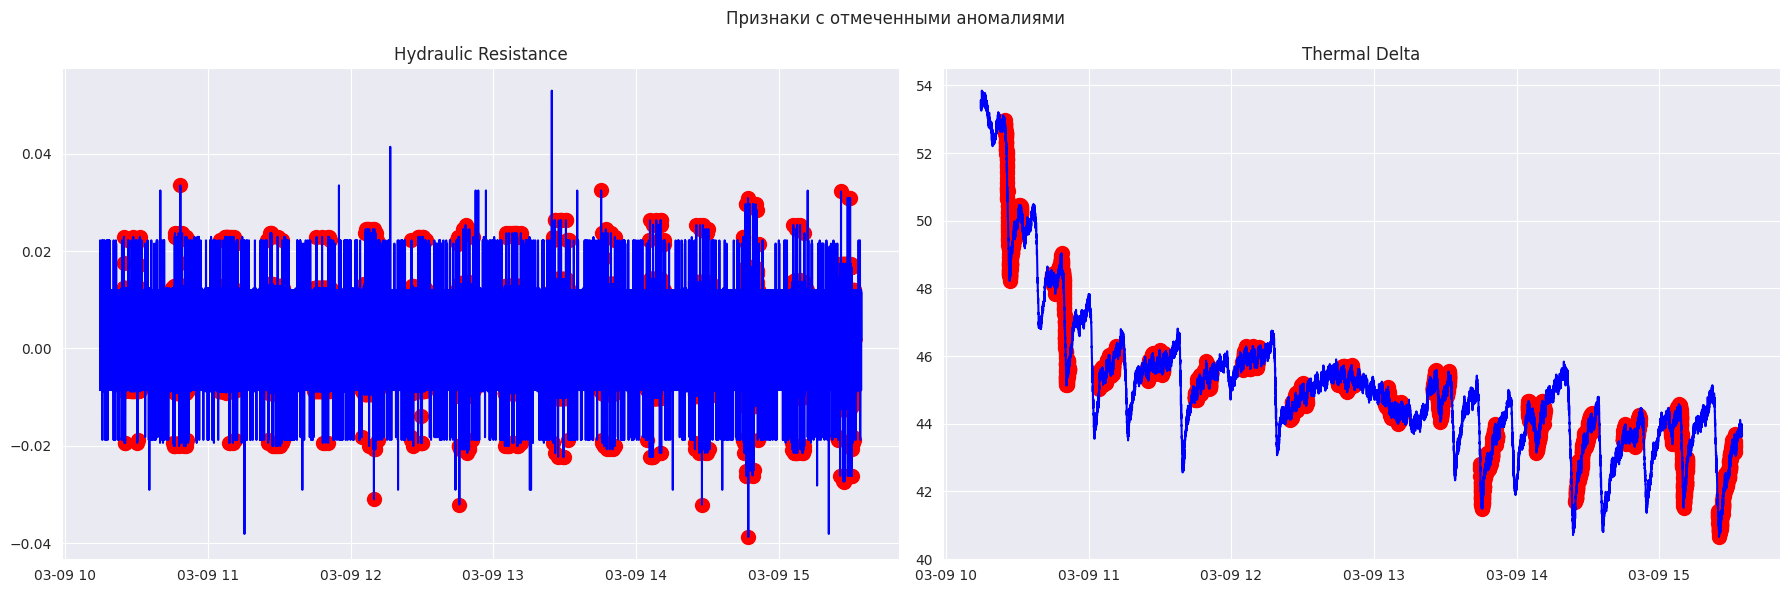

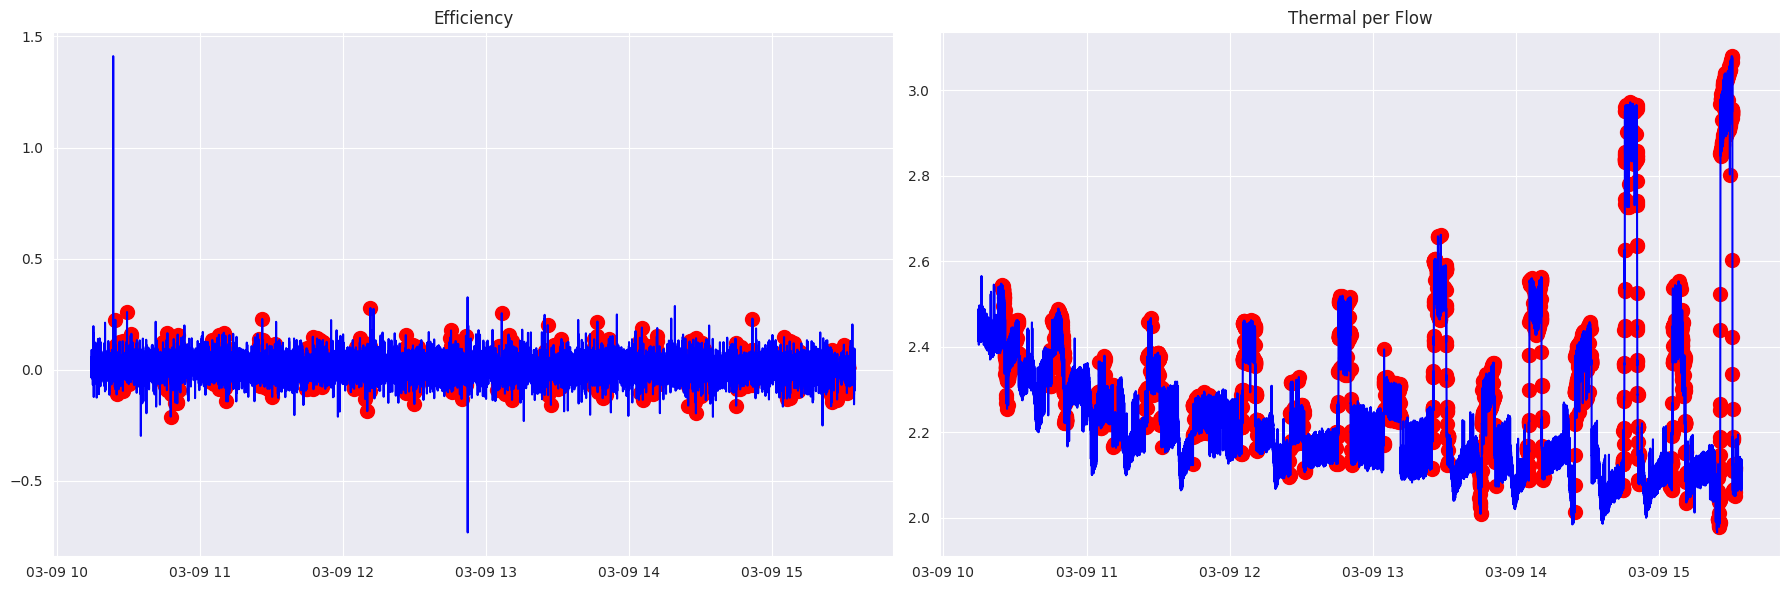

In [ ]:
plot_features_with_anomalies(
    pd.concat([X.iloc[:, X_full.shape[1]:], y], axis=1),
    ncols=[2, 2]
)

Далее мне захотелось узнать, насколько сильно одни переменные влияют на предсказание других. Можно было бы обучить Prophet для каждого признака и проанализировать коэффициенты при экзогенных переменных (остальных признаках), но я решил пойти немного далее и сделать что-то поинтереснее

Итак, встречайте, модель cLSTM из библиотеки Neural-GC! Модель ставит себе цель выявить нелинейные причинности в многомерных рядах по Грейнджеру. Классический тест Грейнджера улавливает только линейные зависимости, а здесь нелинейность приходит через обучение моделей

Итак, cLSTM моделирует многомерный ряд из $\large{p}$ переменных - для каждой переменной $\large{x_i}$ обучается своя модель $\large{LSTM_i}$, принимающая на вход все $\large{p}$ переменных:
$$\large{\hat{x}_i\left(x\right)=LSTM_i\left(x_1^{\left(t-1\right)}, x_2^{\left(t-1\right)}, ..., x_p^{\left(t-1\right)}\right)}$$

Обычная LSTM принимает все входные переменные без ограничений. cLSTM зануляет некоторые веса во входном слое $\large{W^{in} \in \mathbb{R}^{p \times h}}$, где $\large{h}$ — размер скрытого состояния:
$$\large{\widetilde{x}\left(t\right)=W^{in} \cdot x\left(t\right),}$$
при этом $\large{M}$ обнуляет веса нерелевантных входных переменных, именно через эту маску и определяется причинность

Чтобы маска формировалась автоматически в процессе обучения, добавляется штраф group Lasso на веса входного слоя. Для модели целевой переменной $\large{x_i}$:
$$\large{\mathcal{L_i}=\underbrace{\sum_{t}\left(x_t - \hat{x}_t\right)^2}_{ошибка \ прогноза} \ + \ \underbrace{\lambda_1\left|\left|W\right|\right|_2^2}_{Ridge} \ + \ \underbrace{\lambda_2\sum_{j}\left|\left|W^{in}_j\right|\right|}_{grouped \ Lasso}\ ,}$$
при этом:
1) Ridge-регуляризация навешивается на все веса модели, а нетолько на входные
2) Групповое (grouped) Lasso используетя, так как входная переменная $\large{x_j}$ связана с группой весов $\large{W_j^{in}=\{w_{j_1}, w_{j_2}, ..., w_{j_p}\}}$ размера $\large{h}. Нам нужно либо оставить всю группу, либо обнулить всю - это и обрабатывает групповое Lasso

Функция потерь невыпуклая (из-за LSTM) и негладкая (из-за group Lasso). Стандартный оптимизатор не работает с негладкими штрафами. Используется GISTA (Generalized Iterative Shrinkage and Thresholding Algorithm):
$$\large{W_j^{in} = prox_{\lambda}\left(W_j^{in}-\eta\triangledown_{W_j^{in}}\mathcal{L}\right),}$$
где проксимальный оператор является групповым пороговым отсечением:
$$\large{prox_{\lambda}\left(v\right)=max\left(1-\frac{\lambda}{\left|\left|v\right|\right|_2}, 0\right)v \ ,}$$
то есть если норма группы весов меньше $\large{\lambda}$, то вся группа обнуляется. В противном случае она сжимается пропорцонально

После обучения всех $\large{p}$ моделей матрица причинности $\large{GC}$ вычисляется следующим образом:
$$\large{GC_{ij}=\mathbf{1}\left[\left|\left|W_{ji}\right|\right|_2 > 0\right] \ ,}$$
то есть единиа стоит в ячейке, если переменная под индексом $\large{j}$ значимо влияет на переменную под индексом $\large{i}$

Итак, разобьём наши данные на батчи и отрежем лишний хвостик, формирующий маленький батч

In [ ]:
batch_size = 64
X_tensor = torch.from_numpy(StandardScaler().fit_transform(X.values)).to(
    torch.float32
)
X_tensor = X_tensor[
    :(X_tensor.shape[0] // batch_size * batch_size)
].view(batch_size, -1, X_tensor.shape[1]).to(device)

Напишем функцию для тренировки модели и возвращения матрицы попарных влияний признака

In [ ]:
def train_GC(
    cls,
    X,
    train_function,
    init_params,
    train_params,
    threshold=False,
    device=device
):
    model = cls(
        num_series=X.shape[-1],
        **init_params
    ).to(device)
    train_function(
        model,
        X,
        **train_params
    )
    return model.GC(threshold=threshold).cpu().detach().numpy()

Обучим модель cLSTM

In [ ]:
set_random_seed()

clstm_GC = train_GC(
    cLSTM,
    X_tensor,
    train_clstm,
    {
        'hidden': 16
    },
    {
        'context': 150,
        'lam': 1,
        'lam_ridge': 1e-2,
        'lr': 5e-3,
        'max_iter': 235,
        'check_every': 5,
        'verbose': True
    }
)

clstm_GC_binary = (clstm_GC > 0).astype(int)

----------Iter = 5----------
Total loss = 14.786330
MSE = 1.020176, Ridge = 0.216087, Nonsmooth = 13.550067
Variable usage = 100.00%
----------Iter = 10----------
Total loss = 14.472529
MSE = 1.006541, Ridge = 0.215868, Nonsmooth = 13.250121
Variable usage = 100.00%
----------Iter = 15----------
Total loss = 14.159763
MSE = 0.993794, Ridge = 0.215655, Nonsmooth = 12.950315
Variable usage = 100.00%
----------Iter = 20----------
Total loss = 13.847956
MSE = 0.981862, Ridge = 0.215448, Nonsmooth = 12.650646
Variable usage = 100.00%
----------Iter = 25----------
Total loss = 13.536985
MSE = 0.970635, Ridge = 0.215246, Nonsmooth = 12.351105
Variable usage = 100.00%
----------Iter = 30----------
Total loss = 13.226772
MSE = 0.960030, Ridge = 0.215049, Nonsmooth = 12.051693
Variable usage = 100.00%
----------Iter = 35----------
Total loss = 12.917263
MSE = 0.949992, Ridge = 0.214857, Nonsmooth = 11.752414
Variable usage = 100.00%
----------Iter = 40----------
Total loss = 12.608416
MSE = 0.94

Напишем функцию для отрисовки коэффициентов влияния

In [ ]:
def plot_impact_coefs(matrix, fmt='d', figsize=(8, 6), feature_names=X.columns):
    ax = plt.subplots(figsize=figsize)[1]
    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        xticklabels=feature_names,
        yticklabels=feature_names
    )
    plt.show()

Отобразим коэффициенты для модели cLSTM

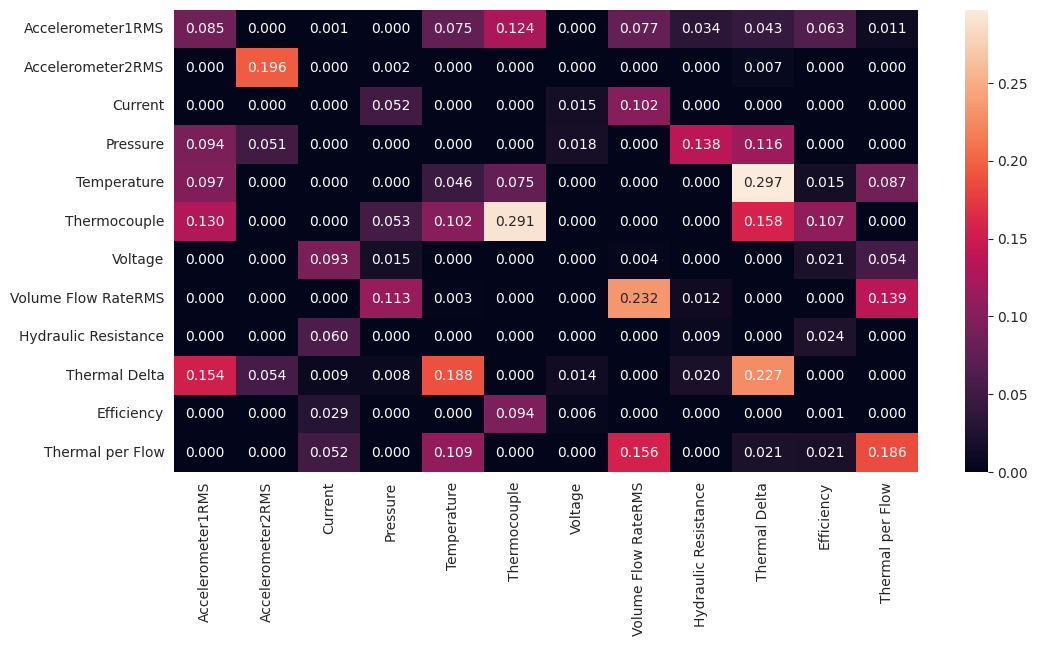

In [ ]:
plot_impact_coefs(clstm_GC, fmt='.3f', figsize=(12, 6))

Выводы:
- Много больших значения находится на диагонали - это характерно для признаков Accelerometer2RMS, Thermocouple, Volume Flow RateRMS, Thermal Delta Thermal per Flow
- Из недиагональных элементов высокие значения характерны для таких пар признаков, как Temperature-"Thermal Delta", "Thermal Delta"-Temperature, Thermocouple-"Thermal Delta", "Thermal Delta"-Accelerometer1RMS, Pressure-"Hydraulic Resistance"
- У Accelerometer1RMS больше влияния на другие признаки, чем у Accelerometer2RMS
- На признак Voltage почти никто значимоне влияет

Здесь можно видеть бинаризованную матрицу влияния

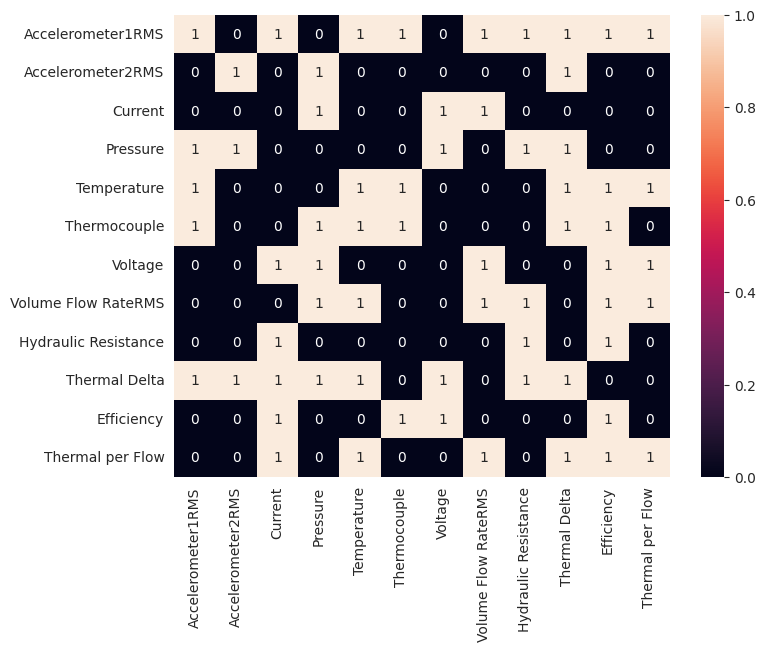

In [ ]:
plot_impact_coefs(clstm_GC_binary)

Вышеописанная теория полностью аналогична и для модели cMLP, за исключением того, что базовая модель - многослойный перцептрон

Здесь комментарии я буду оставлять только к результатам матриц

In [ ]:
set_random_seed()

cmlp_GC = train_GC(
    cMLP,
    X_tensor,
    train_cmlp,
    {
        'lag': 299,
        'hidden': [128, 128]
    },
    {
        'lam': 1,
        'lam_ridge': 1e-2,
        'lr': 5e-4,
        'penalty': 'H',
        'max_iter': 305,
        'check_every': 5,
        'verbose': True
    }
)

cmlp_GC_binary = (cmlp_GC > 0).astype(int)

----------Iter = 5----------
Total loss = 2852.479248
MSE = 0.830073, Ridge = 0.430328, Nonsmooth = 2851.218750
Variable usage = 100.00%
----------Iter = 10----------
Total loss = 1526.320679
MSE = 0.811960, Ridge = 0.430288, Nonsmooth = 1525.078491
Variable usage = 100.00%
----------Iter = 15----------
Total loss = 755.089844
MSE = 0.812650, Ridge = 0.430250, Nonsmooth = 753.846924
Variable usage = 100.00%
----------Iter = 20----------
Total loss = 409.930634
MSE = 0.817480, Ridge = 0.430211, Nonsmooth = 408.682953
Variable usage = 100.00%
----------Iter = 25----------
Total loss = 245.164551
MSE = 0.821366, Ridge = 0.430171, Nonsmooth = 243.913010
Variable usage = 100.00%
----------Iter = 30----------
Total loss = 157.979187
MSE = 0.824238, Ridge = 0.430132, Nonsmooth = 156.724808
Variable usage = 100.00%
----------Iter = 35----------
Total loss = 107.768974
MSE = 0.826616, Ridge = 0.430092, Nonsmooth = 106.512268
Variable usage = 100.00%
----------Iter = 40----------
Total loss = 76

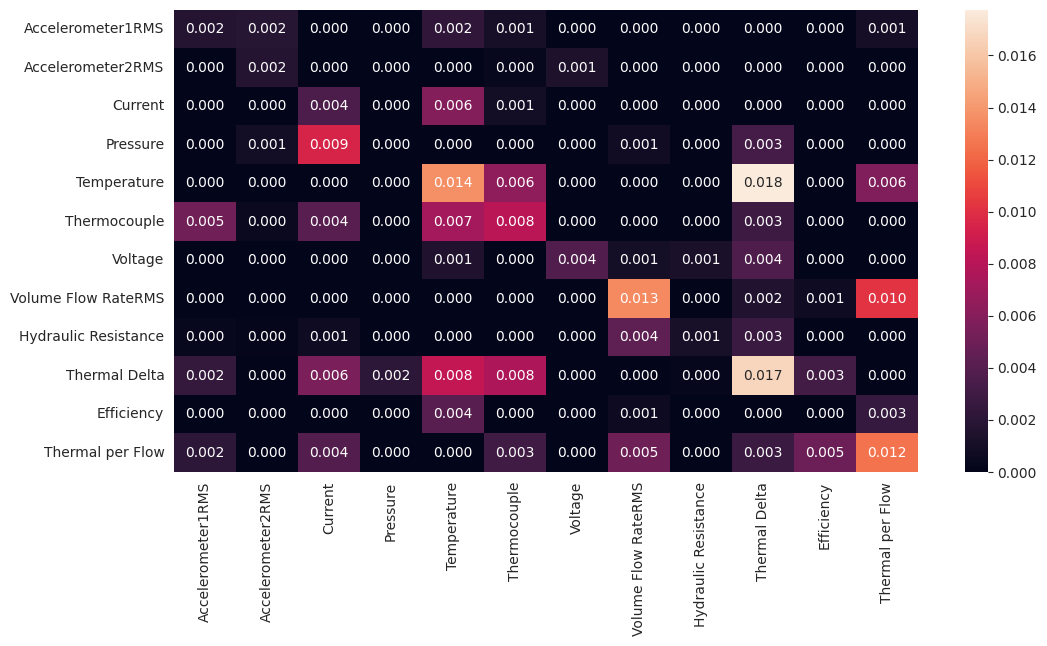

In [ ]:
plot_impact_coefs(cmlp_GC, fmt='.3f', figsize=(12, 6))

Выводы:
- Здесь в прицнипе уменьшилась сила влияния по сравнению с моделью cLSTM
- Как и в предыдущем случае, почти во всех ячейках, где ненулевое число, хотя бы один из признаков так или иначе связан с температурой
- Из "нетемпературных" пар самый большой коэффициент у пары Pressure-Current

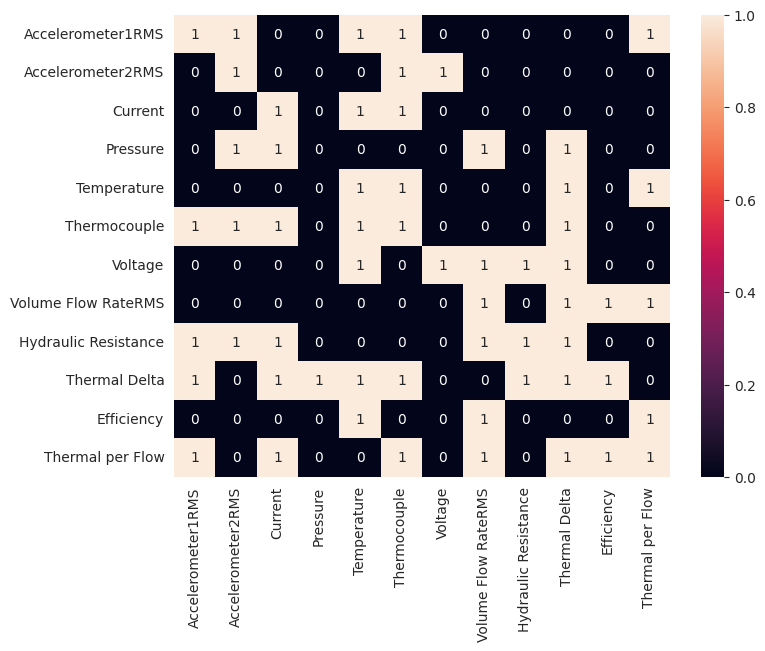

In [ ]:
plot_impact_coefs(cmlp_GC_binary)

Здесь можно видеть бинаризованную матрицу влияний, где один стоит в тех ячейках, где хотя бы один алгоритм засёк какое-нибудь влияние

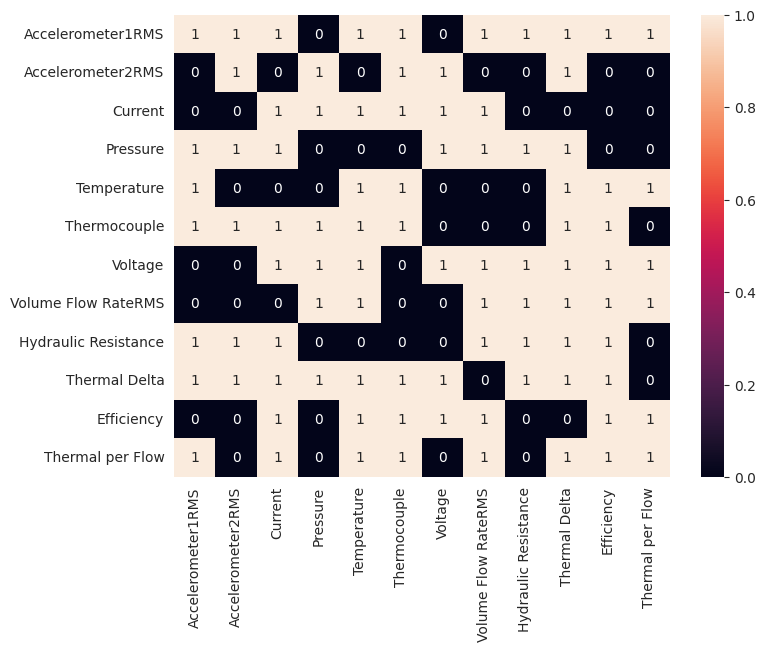

In [ ]:
plot_impact_coefs(
    clstm_GC_binary + cmlp_GC_binary - clstm_GC_binary * cmlp_GC_binary
)

А здесь один стоит только в тех ячейках, где хотя оба алгоритма засекликакое-нибудь влияние - видим, что здесь многое так или иначе связано с температурой

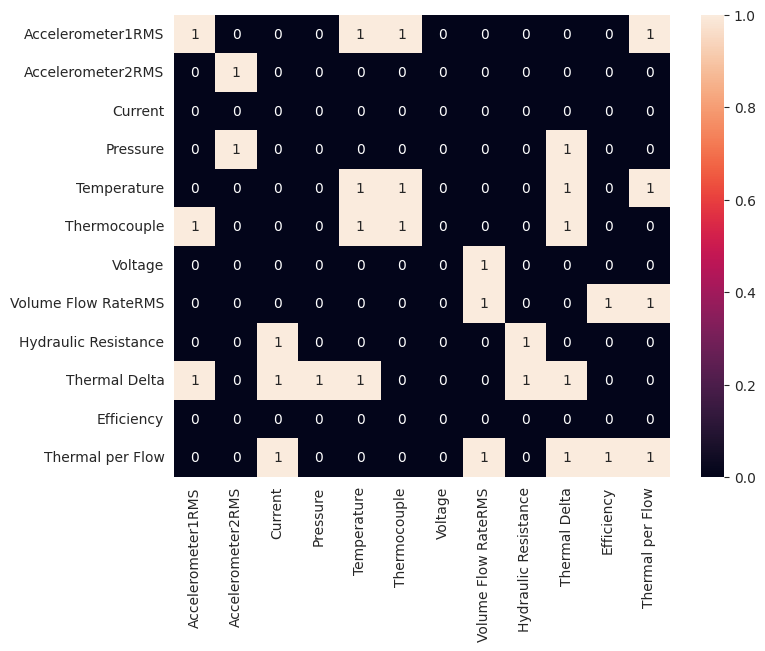

In [ ]:
plot_impact_coefs(clstm_GC_binary * cmlp_GC_binary)

# Нахождение точек, соответствующих проведению эксперимента

## Нахождение аномалий

Здесь будут перепробованы различные алгоритмы и оптимальные гиперпараметры будут подбираться с помошью библиотеки Optuna. Оптимизироваться будет метрика recall, так не выявить реальную аномалию будет хуже

Следующие 4 функции реализуют пайплайн передачи класса модели, данных и границ гиперпараметров и получения на выходе массива с найденными аномалиями

In [ ]:
def predict(model, X, N, left=None, right=None):
    if left is None or right is None:
        if hasattr(model, 'decision_scores_'):
            y_pred = model.decision_scores_
        else:
            y_pred = model.predict_proba(X.values)
        diff = X.shape[0]
    else:
        if hasattr(model, 'decision_function'):
            y_pred = model.decision_function(X.values[:right])[left:]
        else:
            y_pred = model.predict_proba(X.values[:right])[left:]
        diff = right - left
    y_pred = (y_pred >= np.quantile(y_pred, (diff - N) / diff)).astype(int)
    return y_pred

def optimization_step(
    cls,
    X,
    y,
    N,
    indices=None,
    return_preds=False,
    scaler_cls=None,
    **params
):
    scores, coefs = [], []
    if return_preds:
        preds = []
    if indices is None:
        model = cls(**params)
        if scaler_cls is not None:
            X.loc[:] = scaler_cls().fit_transform(X)
        model.fit(X.values)
        y_pred = predict(model, X, N)
        score = recall_score(y.values, y_pred)
        if return_preds:
            preds.append(y_pred)
    else:
        for i in range(indices.shape[0] - 1):
            model = cls(**params)
            if scaler_cls is not None:
                scaler = scaler_cls()
                X.iloc[:indices[i]] = scaler.fit_transform(X.iloc[:indices[i]])
                X.iloc[indices[i]:indices[i + 1]] = scaler.transform(
                    X.iloc[indices[i]:indices[i + 1]]
                )
            model.fit(X.values[:indices[i]])
            if return_preds and i == 0:
                preds.append(predict(model, X, N, 0, indices[i]))
            y_pred = predict(model, X, N, indices[i], indices[i + 1])
            scores.append(
                recall_score(y.values[indices[i]:indices[i + 1]], y_pred)
            )
            coefs.append(indices[i + 1] / X.shape[0])
            if return_preds:
                preds.append(y_pred)
        scores, coefs = np.array(scores), np.array(coefs) / sum(coefs)
        score = (scores * coefs).sum().item()
    if return_preds:
        return np.concatenate(preds)
    return score

In [ ]:
def full_optimization(
    trial,
    cls,
    X,
    y,
    N,
    indices=None,
    scaler_cls=None,
    **params
):
    trial_params = {}
    for key, value in params.items():
        if isinstance(value, (tuple, list)):
            if value[1] == object:
                trial_params[key] = trial.suggest_categorical(key, value[0])
            else:
                log = False if not isinstance(value[-1], bool) else value[-1]
                if value[1] == float:
                    trial_params[key] = trial.suggest_float(
                        key,
                        *value[0],
                        log=log
                    )
                elif value[1] == int:
                    trial_params[key] = trial.suggest_int(
                        key,
                        *value[0],
                        log=log
                    )
                else:
                    trial_params[key] = trial.suggest_categorical(key, value[0])
        else:
            trial_params[key] = value
    score = optimization_step(
        cls,
        X,
        y,
        N,
        indices=indices,
        scaler_cls=scaler_cls,
        **trial_params
    )
    return score

In [ ]:
def fit_model(
    cls,
    X,
    y,
    N=6720,
    indices=None,
    scaler_cls=None,
    n_trials=50,
    **params
):
    study = create_study(
        direction='maximize',
        study_name=f'Оптимизация алгоритма {cls.__name__}'
    )
    study.optimize(
        lambda trial: full_optimization(
            trial,
            cls=cls,
            X=X,
            y=y,
            N=N,
            indices=indices,
            scaler_cls=scaler_cls,
            **params,
        ),
        n_trials=n_trials
    )
    default_params = {
        key: value for key, value in params.items() \
        if not isinstance(value, (tuple, list))
    }
    y_pred = optimization_step(
        cls=cls,
        X=X,
        y=y,
        N=N,
        indices=indices,
        return_preds=True,
        scaler_cls=scaler_cls,
        **{
            **study.best_params,
            **default_params
        }
    )
    return y_pred

Эта функция нужна для отрисовки кривой ROC-AUC

In [ ]:
def plot_roc_curve(y_true, y_scores, figsize=(8, 6)):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    plt.figure(figsize=figsize)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC-AUC ~ {auc:.3f}')
    plt.plot(
        [0, 1], [0, 1], color='gray', linestyle='--', lw=1,
        label='Случайный класификатор'
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('Кривая ROC-AUC')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

А эта для отрисовки матрицы ошибок (confusion matrix)

In [ ]:
def plot_confusion_matrix(y_true, y_pred):
    ConfusionMatrixDisplay.from_predictions(y_true['anomaly'].values, y_pred)
    plt.show()

### Матричный профиль

Первый алгоритм, который мы рассмотрим - Matrix Profile (матричный профиль). Далее будет объяснено его устройство

Для каждой подпоследовательности ряда длины mm
m находится её ближайший сосед среди всех других подпоследовательностей. Расстояние до этого соседа и есть значение Matrix Profile в данной точке. Чем больше расстояние — тем более уникальна подпоследовательность, тем выше аномальноть объекта

Сначала выбирается целое положительное число $\large{m}$ и из ряда $\large{x=\left(x_1, x_2, ..., X_T\right)}$ извлекаются все подпоследовательности длины $\large{m}$:
$$\large{Q_i=\left(x_i, x_{i+1}, ..., x_{i+m-1}\right), i=\overline{1, T - m + 1}}$$

Далее перед сравнением каждая подпоследовательность нормализуется:
$$\large{\hat{Q}_i=\frac{Q_i - \mu_i}{\sigma_i} \ ,}$$
где $\large{\mu_i}, $\large{\sigma_i}$ среднее и стандартное отклонение внутри окна $\large{Q_i}$. Именно поэтому Matrix Profile нечувствителен к масштабу признаков — нормализация происходит локально внутри каждого окна

Расстояние между двумя нормализованными подпоследовательностями вычисляется через евклидово расстояние:
$$\large{d\left(i,j\right)=\left|\left|\hat{Q}_i - \hat{Q}_j\right|\right|=\sqrt{\sum_{k=0}^{m-1} \left(\hat{x}_{i+k} - \hat{x}_{j+k}\right)} \ ,}$$
важное ограничение — исключается зона исключения вокруг $\large{i}$, чтобы не сравнивать подпоследовательность с самой собой или перекрывающимися соседями:
$$\large{j \notin \left[i - \frac{m}{2}; i + \frac{m}{2}\right]}$$

Для многомерного ряда, имеющего $\large{p}$ признаков, расстояние считается по каждому признаку отдельно, а затем суммируется:
$$\large{d^{multi}\left(i,j\right)=\sum_{k=1}^pd_k\left(i,j\right)}$$

Значения Matrix Profile вычисляются следующим образом - для каждой позиции $\large{i}$ берётся расстояние до ближайшего соседа:
$$\large{MP_{i}=\underset{j, \ j \notin \left[i - \frac{m}{2}; i + \frac{m}{2}\right]}{min}d\left(i,j\right) \ ,}$$
результатом является вектор $\large{MP}$, где каждый элемент — расстояние до ближайшей похожей подпоследовательности

Аномалиями считаются те точки, у которых значения вектора $\large{MP}$ максимальные

Считаем, что в наших данных алгоритм должен найти около 6000 аномалий

In [ ]:
set_random_seed()

y_pred_mp = fit_model(
    MatrixProfileDetector,
    X,
    y['anomaly'],
    n_trials=25,
    window_size=((300, 600), int),
    p=((1., 10.,), float, True),
    k=((1, 25), int)
)

[I 2026-07-06 07:37:16,459] A new study created in memory with name: Оптимизация алгоритма MatrixProfileDetector
[I 2026-07-06 07:39:22,635] Trial 0 finished with value: 0.2558243062768957 and parameters: {'window_size': 530, 'p': 4.627096451360772, 'k': 1}. Best is trial 0 with value: 0.2558243062768957.
[I 2026-07-06 07:41:21,910] Trial 1 finished with value: 0.18890043033090964 and parameters: {'window_size': 357, 'p': 3.3739271477209556, 'k': 23}. Best is trial 0 with value: 0.2558243062768957.
[I 2026-07-06 07:43:18,843] Trial 2 finished with value: 0.25463718652619083 and parameters: {'window_size': 524, 'p': 6.453915813794469, 'k': 22}. Best is trial 0 with value: 0.2558243062768957.
[I 2026-07-06 07:45:19,086] Trial 3 finished with value: 0.1906811099569669 and parameters: {'window_size': 301, 'p': 1.0017572567745696, 'k': 8}. Best is trial 0 with value: 0.2558243062768957.
[I 2026-07-06 07:47:15,717] Trial 4 finished with value: 0.25048226739872387 and parameters: {'window_siz

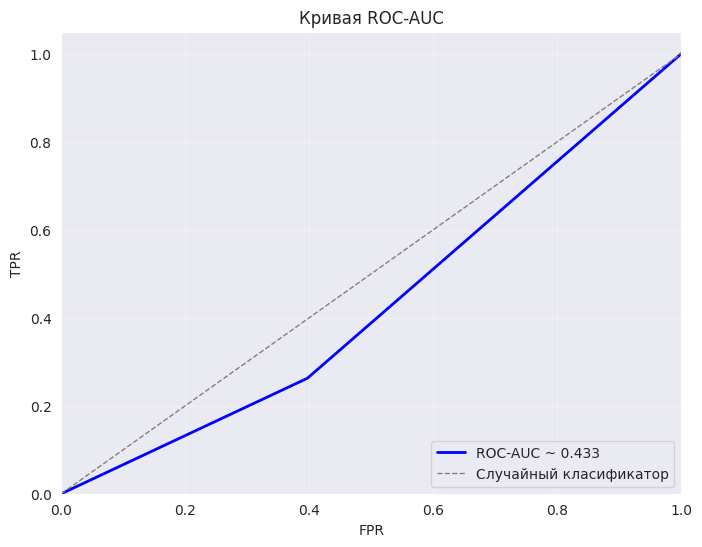

In [ ]:
plot_roc_curve(y_full['anomaly'].values, y_pred_mp)

Эта функция нужна для вычисления различных классификационных метрик

In [ ]:
def get_classification_metrics(y_true, y_pred):
    return pd.DataFrame(
        classification_report(y_true, y_pred, output_dict=True)
    )

In [ ]:
get_classification_metrics(y['anomaly'].values, y_pred_mp)

,0,1,accuracy,macro avg,weighted avg
precision,0.602050,0.263244,0.483523,0.432647,0.483188
recall,0.602967,0.262502,0.483523,0.432734,0.483523
f1-score,0.602508,0.262872,0.483523,0.432690,0.483355
support,12470.000000,6739.000000,0.483523,19209.000000,19209.000000


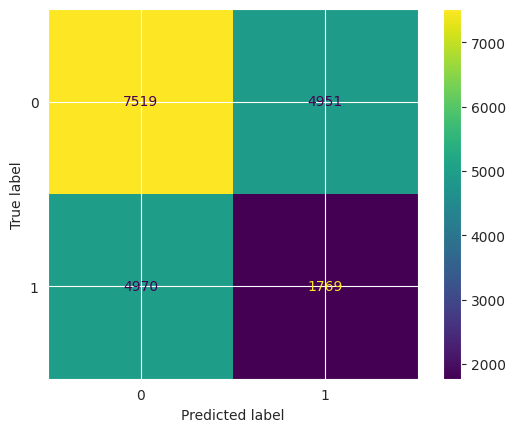

In [ ]:
plot_confusion_matrix(y, y_pred_mp)

Визуализируем признаки заново. Оранжевые кружочки здесь - это найденные алгоритмом аномалии

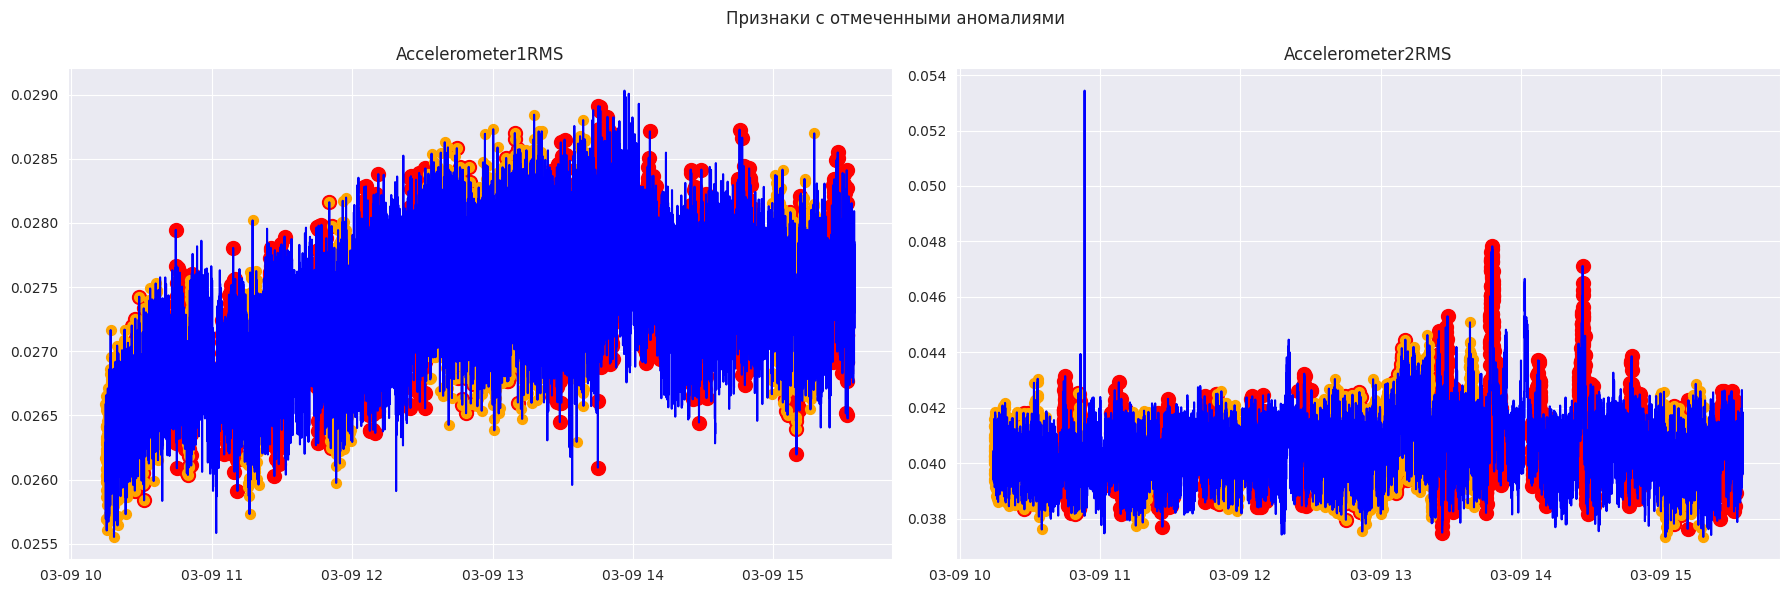

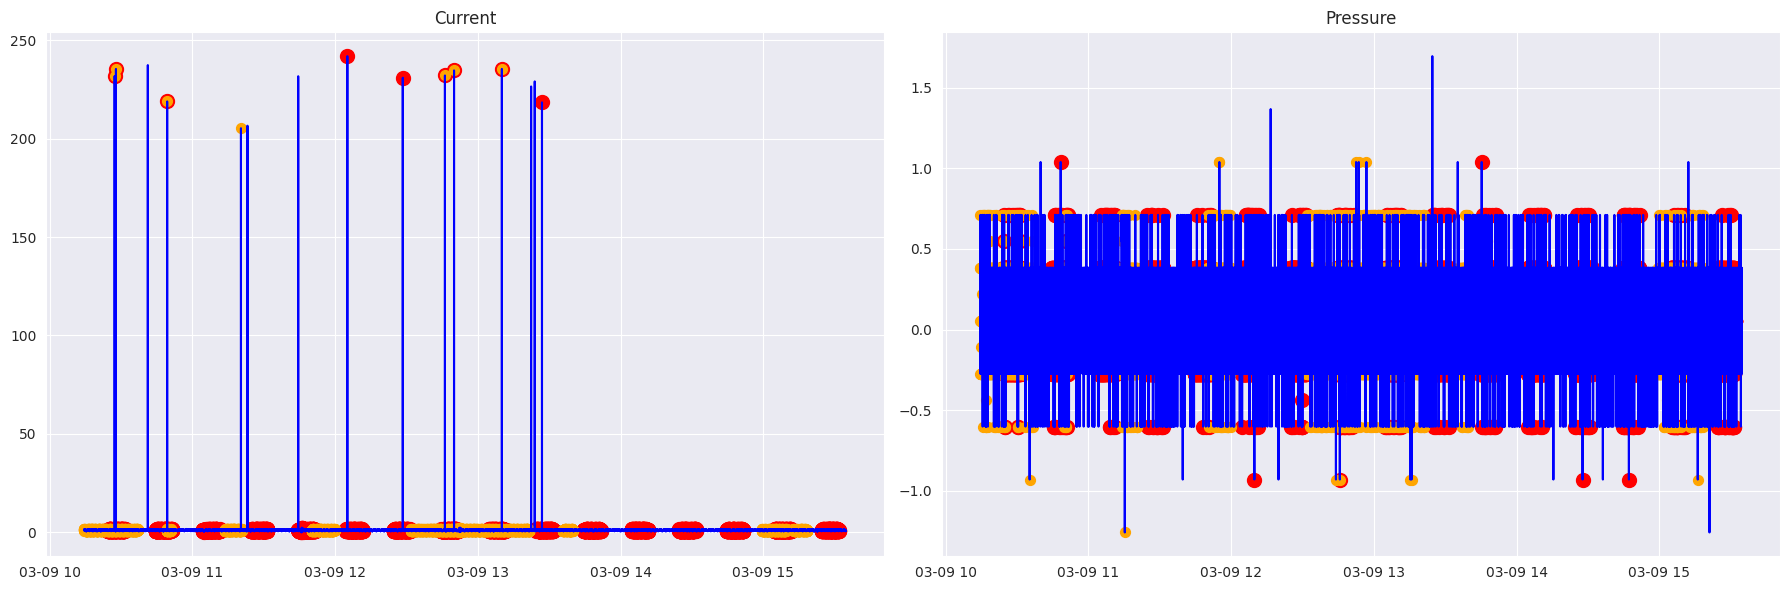

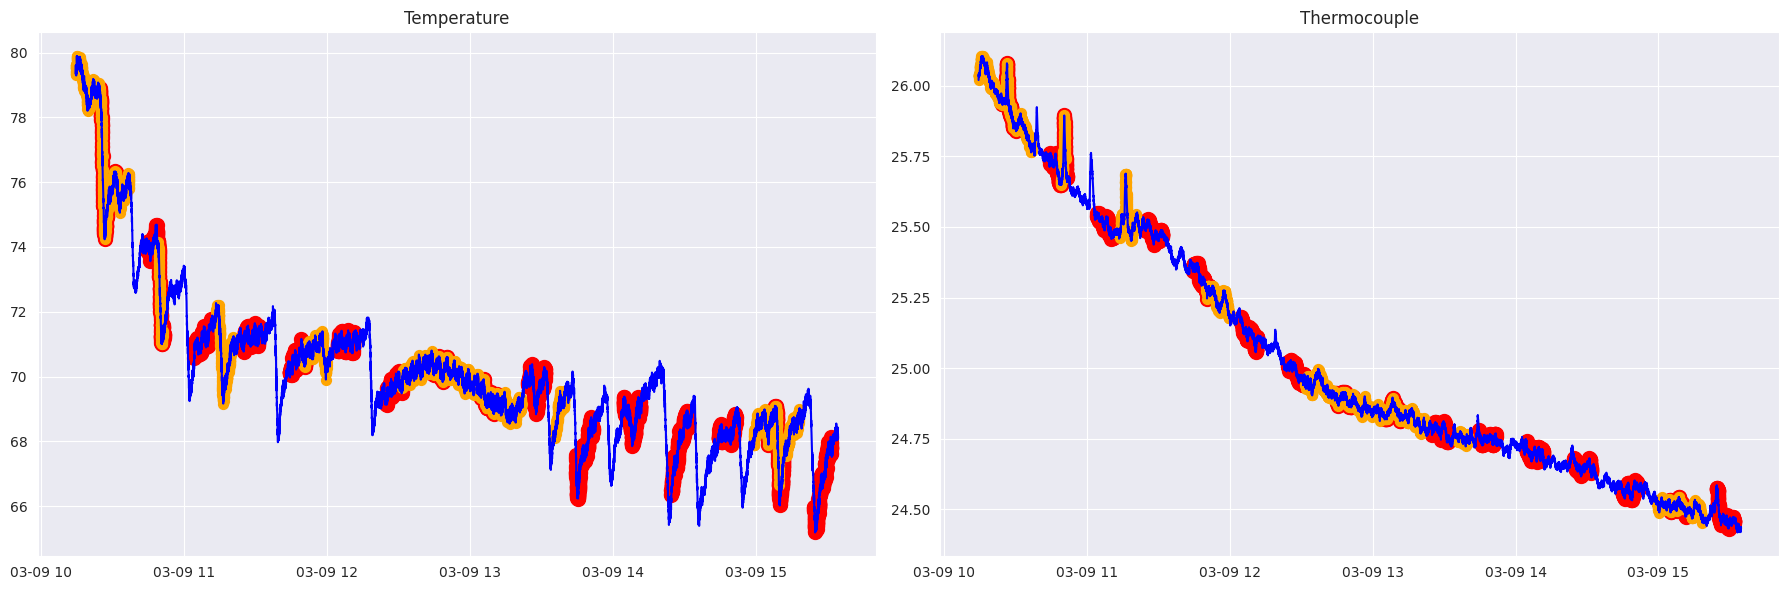

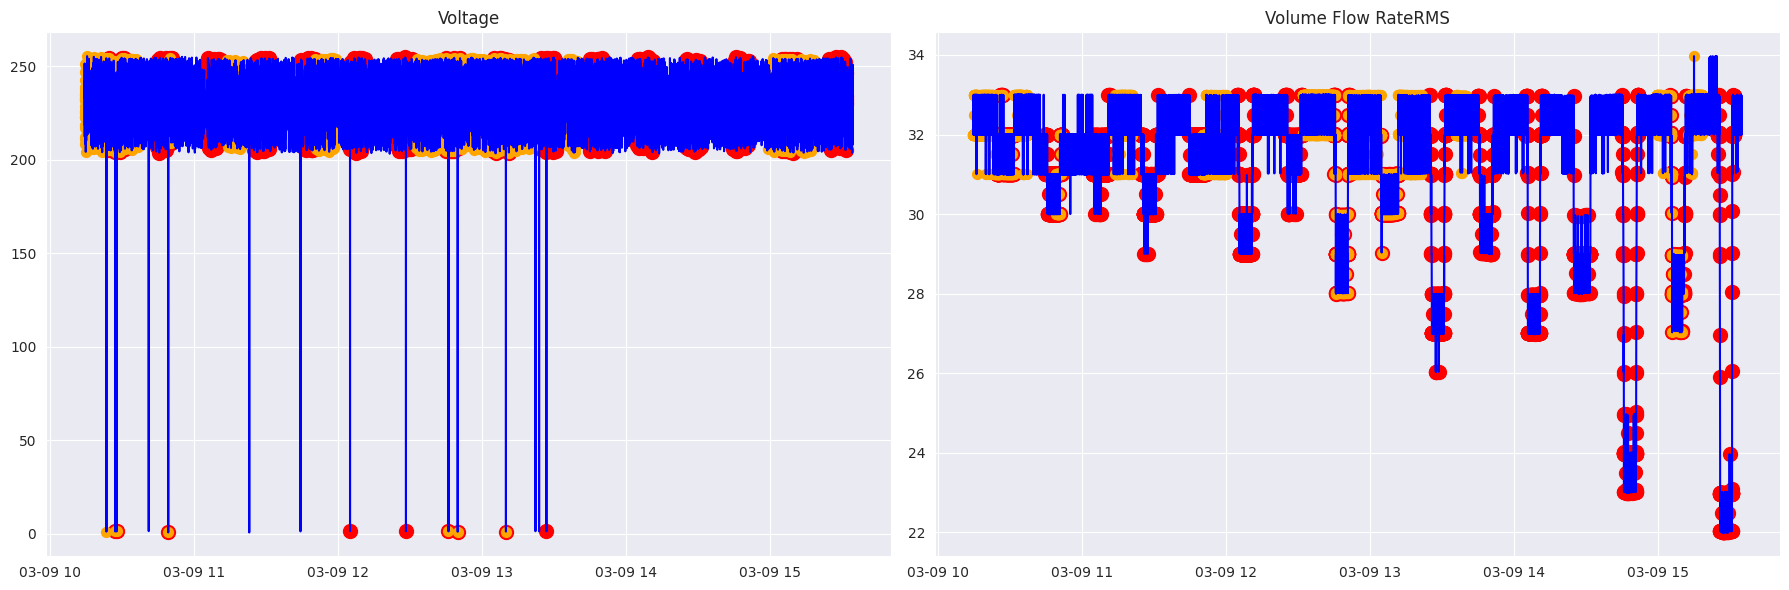

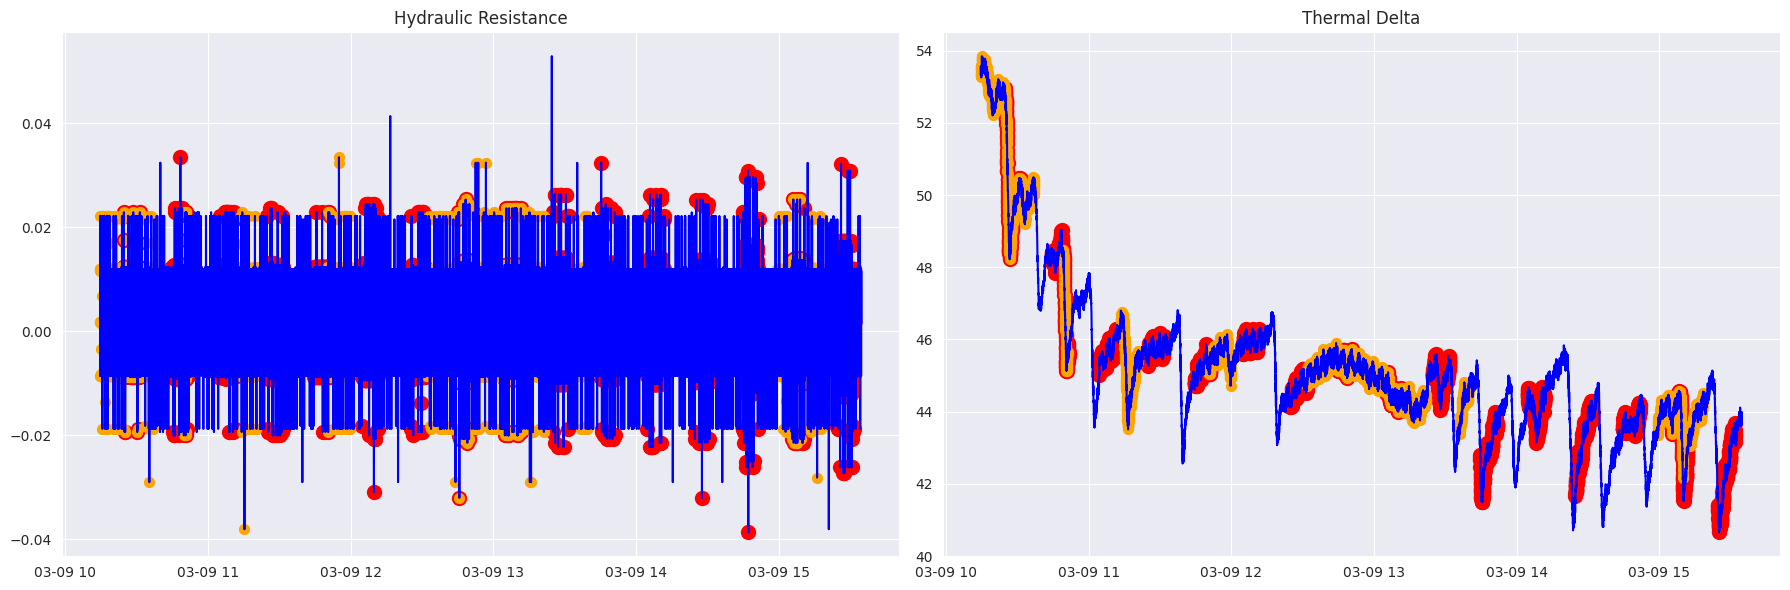

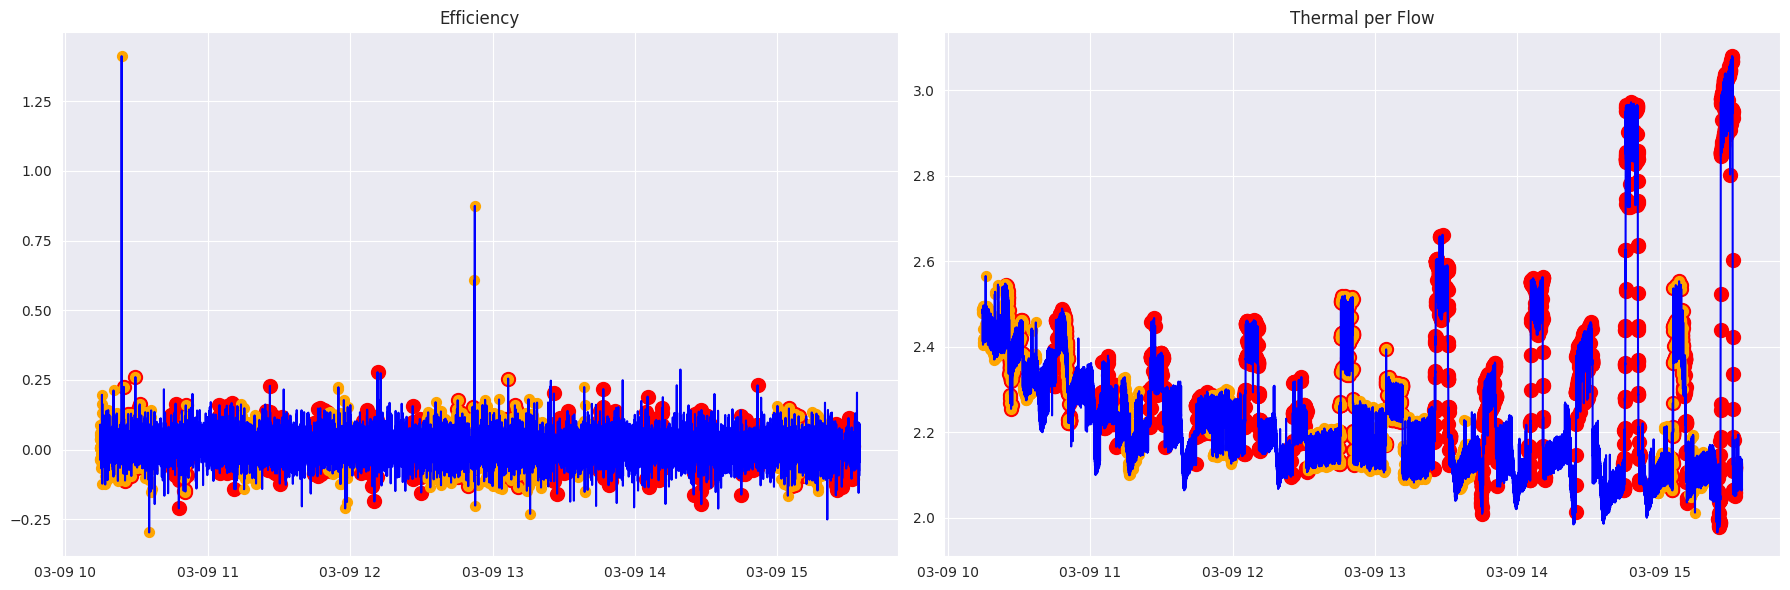

In [ ]:
plot_features_with_anomalies(
    pd.concat([X, y], axis=1),
    found_anomalies=y_pred_mp,
    ncols=[2] * 6
)

Выводы:
- Видим, что алгоритм отработал довольно слабо
- Он хуже случайного классификатора по метрике ROC-AUC
- Значения метрики precision и recall в 0.26 говорит о том. что лишь четверть предсказанных аномалий действительно являюся аномалиями и что лишь четверть аномалий была предсказана верно

Это неудовлетворительный резальтута, который надо будет улучшать

### K-Means

Следующий на очереди алгоритм - KMeans

Начало здесь такое же - данные нарезаются на окна $\large{Q_i}$. Если ряд многомерный (в большинстве случаев это так), то получившееся двумерное окно размера $\large{m \times p}$ разворачивается в одномерный вектор длины $\large{m\cdot p}$:
$$\large{Q_i=\begin{pmatrix}x_i\\ x_{i+1}\\ ... \\ x_{i+m-1}\end{pmatrix} \rightarrow \hat{Q}_i = \left(x_i^1, x_i^2, ..., x_i^p, ..., x_{i+1}^1,...,x_{i+1}^p,...,x_{i+m-1}^p\right)}$$

Длаее алгоритм K-Means обучается следующим образом - сначала он находит $\large{k}$ центроидов $\large{C=\left(\mu_1, \mu_2, ..., \mu_k\right)}$. Итоговая цель алгоритма - минимизировать внутрикластерную дисперсию (сумму квадратов расстояний от каждого окна до ближайшего центроида). Целевая функция выглядит так:
$$\large{J=\sum_{i=1}^{T-m+1}\underset{j=\overline{1,k}}{min}\left|\left|\hat{Q}_i-\mu_j\right|\right|_2^2}$$

Оптимизация происходит с помощью алгоритма Ллойда:
- Сначала каждому объекту сопоставляется кластер с юлижайшим центроидом:
$$\large{r_{ij}=\begin{cases}1, \ если \ j = \underset{j\in\overline{1,k}}{\left|\left|\hat{Q}_i-\mu_j\right|\right|_2^2} \ , \\ 0 \ , \ иначе\end{cases}}$$
- Центроиды пересчитываются как среднее арифметическое всех окон, назначенных в данный кластер:
$$\large{\mu_j=\frac{\sum_{i=1}^{T-m+1}r_{ij}\hat{Q}_i}{\sum_{i=1}^{T-m+1}r_{ij}}}$$

Оценка аномальности объекта вычисляется по следующей формуле:
$$\large{A\left(\hat{Q}_i\right)=\underset{j=\overline{1,k}}{min}\left|\left|\hat{Q}_i-\mu_j\right|\right|_2^2}$$

Аномалиями считается те объекты, у которых оценка аномальности максимальная

При этом схема предсказания представлена на рисунке. Сначала обучаемся на малой тренировочной части и подбирем оптимальные гиперпараметры на кросс-валидации, а затем предсказываем аномалии на тестовой выборке. На следующей итерации кросс-валидация и тестовая выборка сдвигаются, а тренировочная выбоорка увеличивается в размерах и модель обучается заново с теми же гиперпараметрами. То есть получается такое итеративное предказание аномалий с учётом только прошлых значений

Итоговое значение метрики recall вычисляется как взвешенное значение метрик recall на отдельных тестовых выборках. В качестве весов выступают размеры тренировочных выборок

![image.png](https://www.angioi.com/assets/pics/nestedcv/traincv.svg)

Здесь считаем, что алгоритм в каждом окне должен найти примерно 420 аномалий

In [ ]:
set_random_seed()

y_pred_kmns = fit_model(
    KMeansAnomalyDetector,
    X,
    y['anomaly'],
    n_trials=25,
    N=420,
    indices=last_indices,
    window_size=((300, 500), int),
    n_clusters=((2, 25), int),
    random_state=random_state
)

[I 2026-07-06 08:36:55,020] A new study created in memory with name: Оптимизация алгоритма KMeansAnomalyDetector
[I 2026-07-06 08:38:03,132] Trial 0 finished with value: 0.51986887608696 and parameters: {'window_size': 372, 'n_clusters': 5}. Best is trial 0 with value: 0.51986887608696.
[I 2026-07-06 08:40:08,298] Trial 1 finished with value: 0.46138405851310127 and parameters: {'window_size': 329, 'n_clusters': 16}. Best is trial 0 with value: 0.51986887608696.
[I 2026-07-06 08:42:12,392] Trial 2 finished with value: 0.5193515199740636 and parameters: {'window_size': 442, 'n_clusters': 7}. Best is trial 0 with value: 0.51986887608696.
[I 2026-07-06 08:44:25,259] Trial 3 finished with value: 0.5140157356042345 and parameters: {'window_size': 391, 'n_clusters': 9}. Best is trial 0 with value: 0.51986887608696.
[I 2026-07-06 08:46:55,079] Trial 4 finished with value: 0.5223964556109323 and parameters: {'window_size': 327, 'n_clusters': 24}. Best is trial 4 with value: 0.5223964556109323.

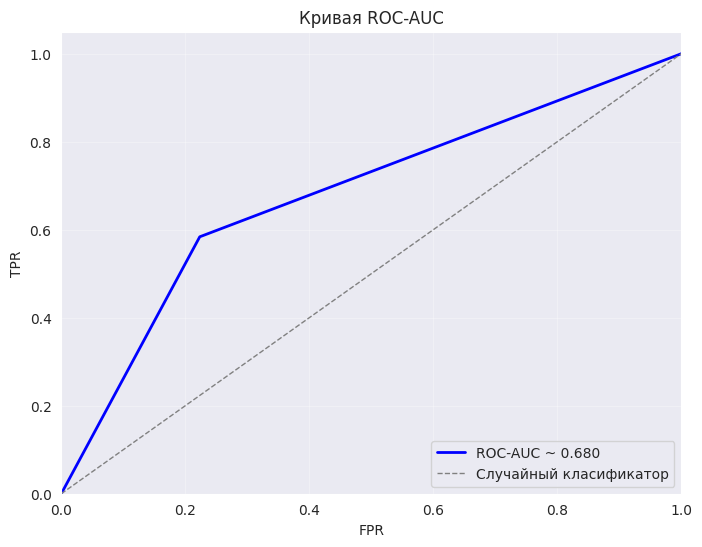

In [ ]:
plot_roc_curve(y_full['anomaly'].values, y_pred_kmns)

In [ ]:
get_classification_metrics(y['anomaly'].values, y_pred_kmns)

,0,1,accuracy,macro avg,weighted avg
precision,0.775482,0.585565,0.709043,0.680524,0.708855
recall,0.776664,0.583915,0.709043,0.680289,0.709043
f1-score,0.776073,0.584739,0.709043,0.680406,0.708948
support,12470.000000,6739.000000,0.709043,19209.000000,19209.000000


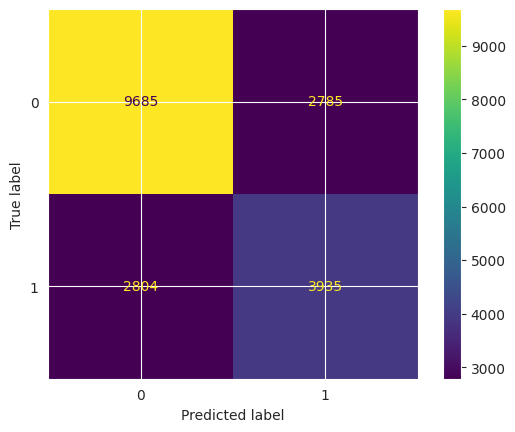

In [ ]:
plot_confusion_matrix(y, y_pred_kmns)

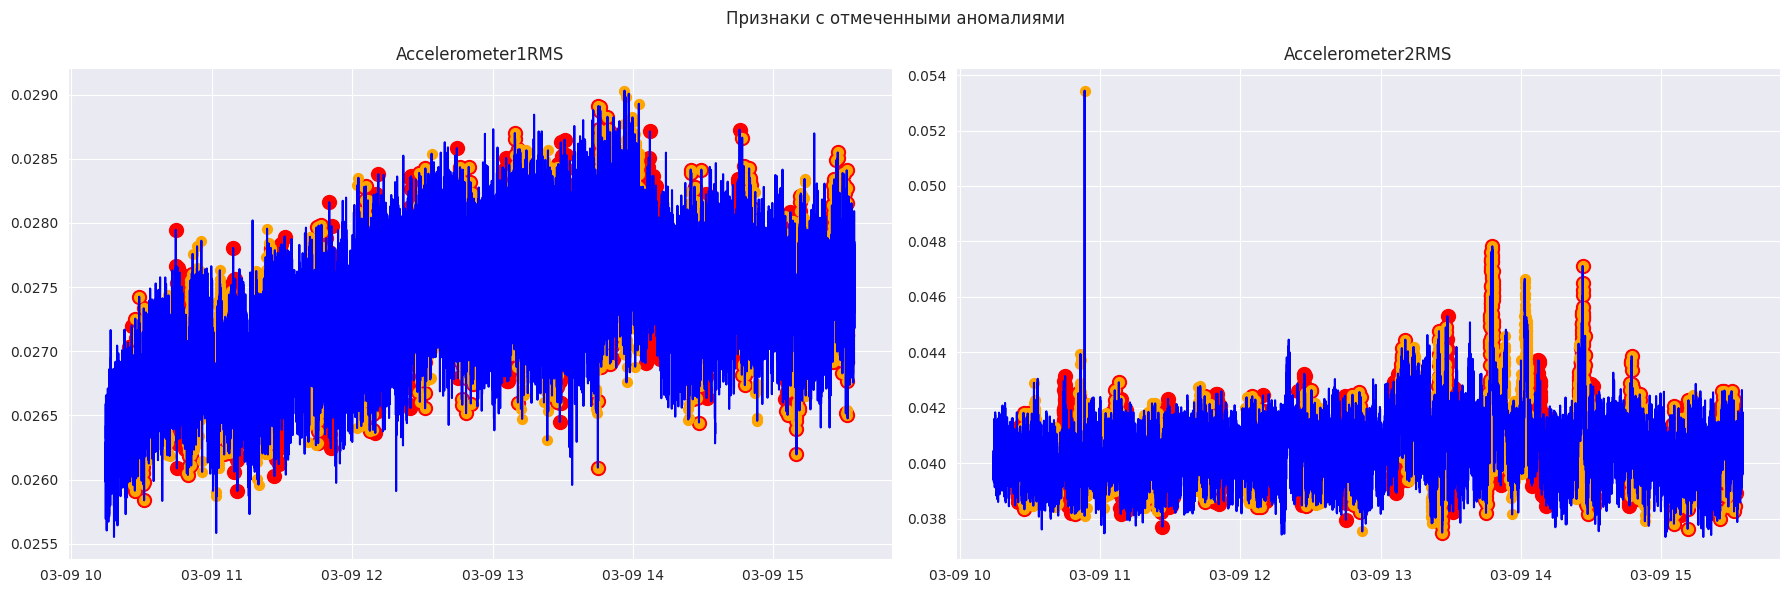

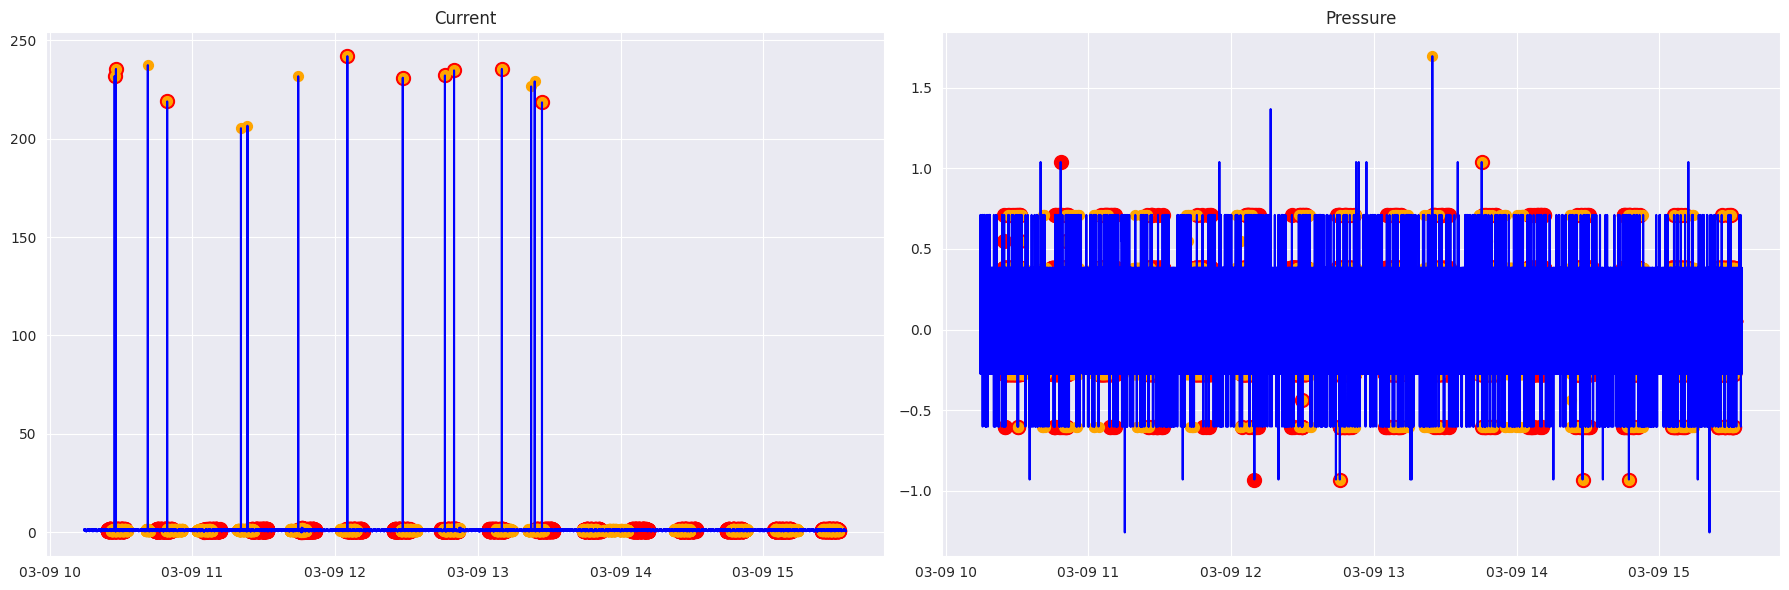

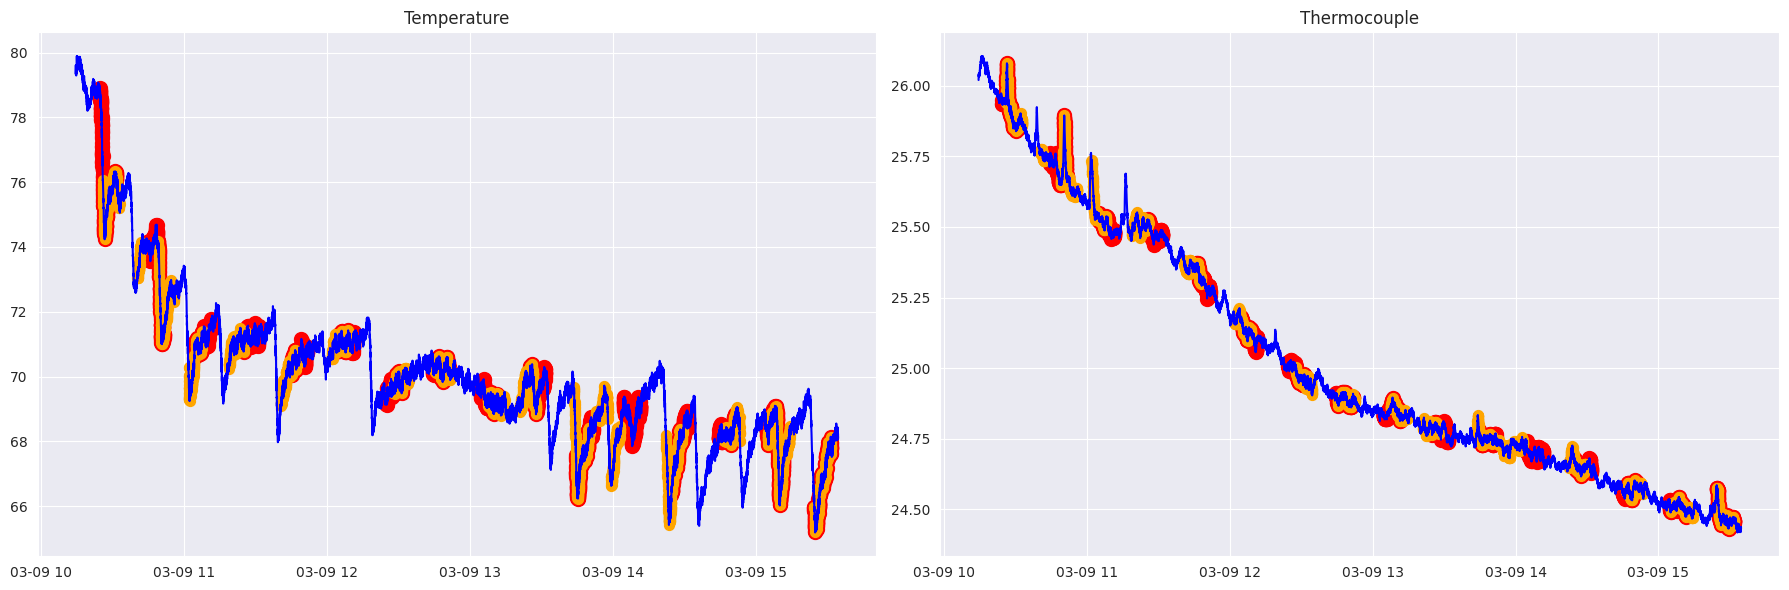

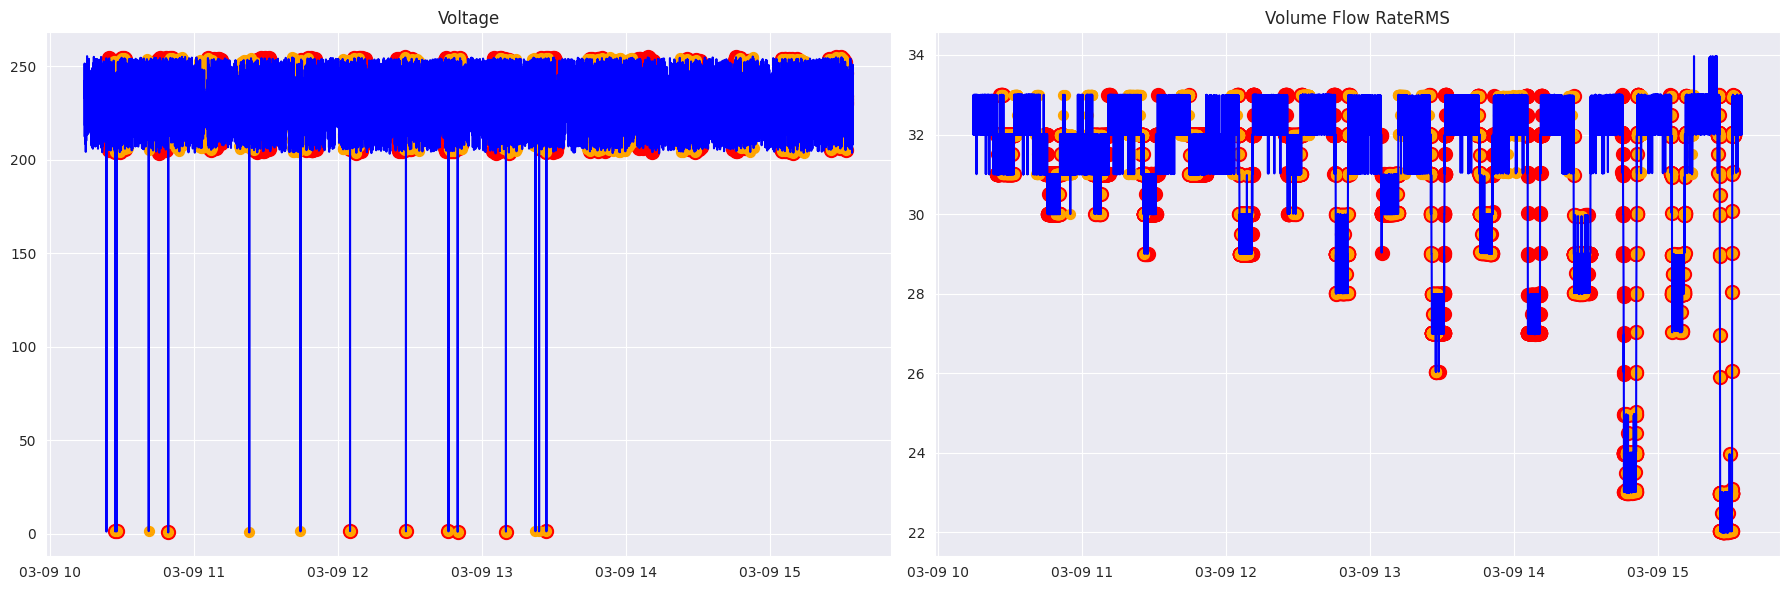

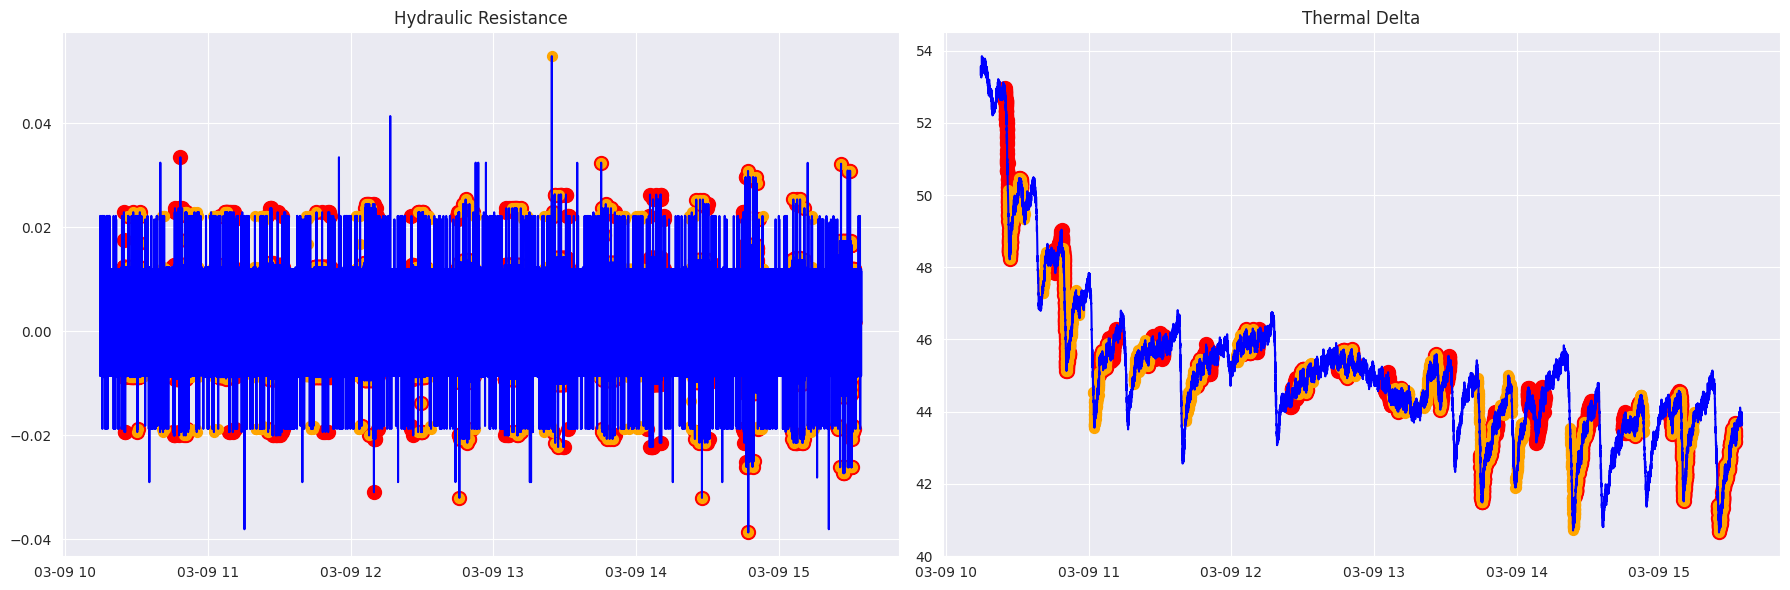

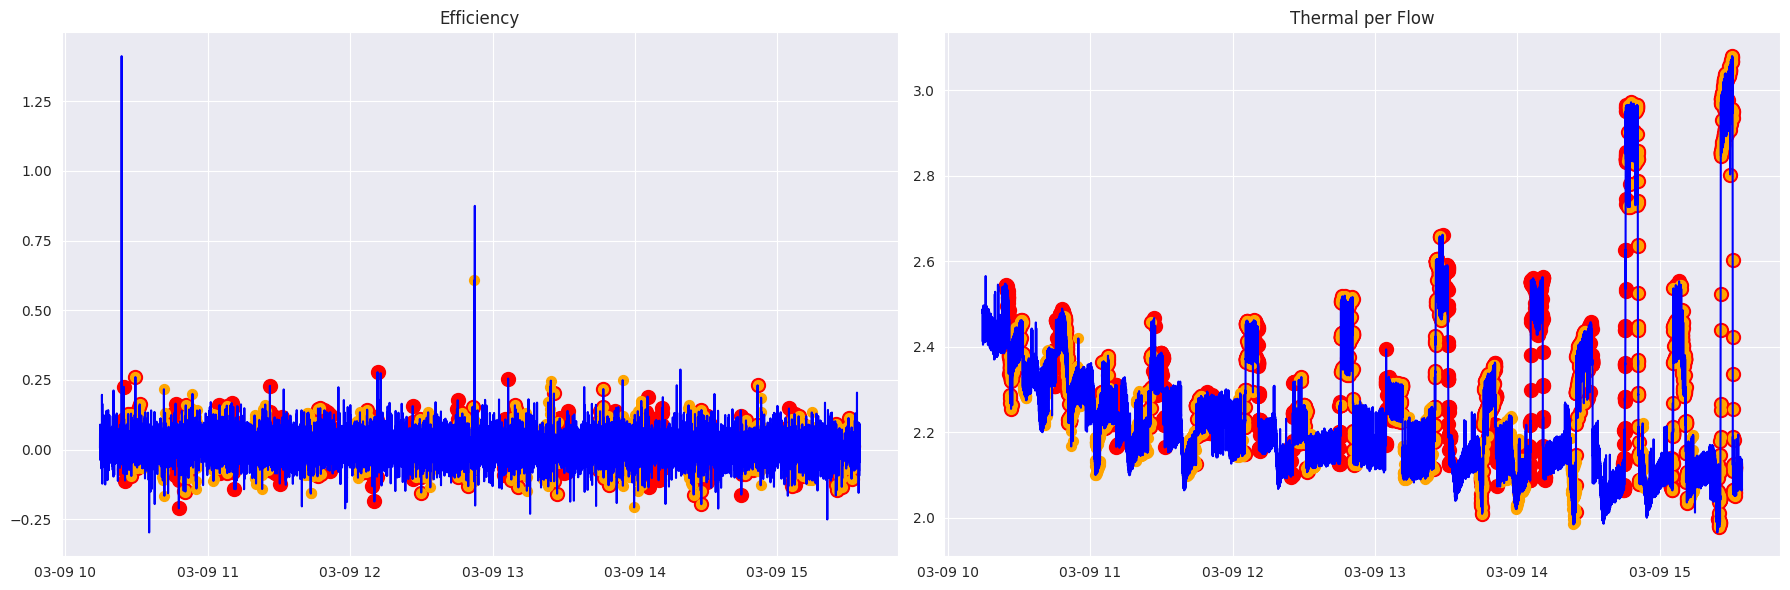

In [ ]:
plot_features_with_anomalies(
    pd.concat([X, y], axis=1),
    found_anomalies=y_pred_kmns,
    ncols=[2] * 6
)

Выводы:
- Итак, видим значительное улучшение в результатах
- И precision, и recall близки к 0.6, а значение ROC-AUC равно 0.68, что уже лучше случайного классификатора

Однако хочется ещё получше сделать

### Изоляционный лес

Ну и последний алгоритм, который мы рассмотрим - изоляционный лес

Первый шаг аналогичен оному в алгоритме K-Means - подготавливаем длинный одномерный вектор $\large{Q_i}$

Далее каждое решающее дерево строится на подвыборке $\large{Q' \subset Q}$ размера $\large{\psi}$. Каждый лист разбивается по следующему алгоритму:
1) Разбиение листа не выполняется, если $\large{\left|Q'\right| \leq 1}$ или достигнута максимальная высота дерева $\large{e=\lceil\log_2\psi\rceil}$
2) Из числа признаков $\large{m \cdot p}$ равномерно случайно выбирается один: $$\large{q \sim Uniform\left(\{1, 2, ..., p\}\right)}$$
3) Порог $\large{b}$ выбирается равномерно между минимумом и максимумом значения признака $\large{q}$ в текущей подвыборке
$$\large{b \sim Uniform\left(\underset{x\in Q'}{min} \ x^q, \underset{x\in Q'}{max} \ x^q\right)}$$
4) Разбиение осуществляется следующим образом:
   - Левый ребёнок - $\large{Q'_L=\{x \in Q' | x^q < b \}}$
   - Правый ребёнок - $\large{Q'_R=\{x \in Q' | x^q \geq b \}}$
5) Разбиение рекурсивно выполняется в детях $\large{Q'_L}$ и $\large{Q'_R}$

Далее упомянем то, как вычисляется длина пути для каждого объекта. Для объекта
$\large{x}$ длина пути $\large{h(x)}$ в дереве $\large{T}$ — это количество рёбер от корня до узла, где $\large{x}$ оказался

Если $\large{x}$ попадает во внешний узел, содержащий $\large{c}$ объектов, путь корректируется на среднюю длину неуспешного поиска в бинарном дереве:
$$\large{h(x)=e+c(c) \ ,}$$
где $\large{c(n)}$ — средняя длина пути в неудачном поиске для $\large{n}$ элементов:
$$\large{c(n)=2H(n-1)-\frac{2(n-1)}{n}} \ ,$$
где $\large{H(i)}$ - $\large{i}$-ое гармоническое число:
$$\large{H\left(i\right)=\sum_{k=1}^i\frac{1}{k} \approx ln(i) + \gamma \ ,}$$
где $\large{\gamma \approx 0.5772156649}$ - постоянная Эйлера-Маскерони

Смысл поправки $\large{c(n)}$ - если в листе осталось $\large{n > 1}$ объектов, алгоритм не смог их разделить. Ожидаемая длина дополнительного пути до полной изоляции одной точки равна $\large{c(n)}$

Теперь поговорим о том, как вычисляется оценка аномальности для каждого объекта. Итак, изоляционный лес представляет собой ансамбль из $\large{n}$ решающих деревев. Сначала для каждого объекта $\large{x}$ вычисляется средняя длина пути:
$$\large{\mathbb{E}\left[h(x)\right]=\frac{1}{n}\sum_{i=1}^n h_{T_i}(x)}$$

Значение аномальности вычисляется по следующей формуле:
$$\large{A(Q_i)=2^{-{\mathbb{E}\left[h(Q_i)\right]}}}$$

И тут опять, чем выше значение аноальности, тем более аномальным считется объект

In [ ]:
set_random_seed()

y_pred_if = fit_model(
    IsolationForest,
    X,
    y['anomaly'],
    n_trials=30,
    N=420,
    indices=last_indices,
    window_size=((300, 600), int),
    n_estimators=((200, 500), int),
    n_jobs=-1,
    random_state=random_state,
)

[I 2026-07-06 09:19:25,272] A new study created in memory with name: Оптимизация алгоритма IsolationForest
[I 2026-07-06 09:20:00,689] Trial 0 finished with value: 0.6730237679820998 and parameters: {'window_size': 397, 'n_estimators': 239}. Best is trial 0 with value: 0.6730237679820998.
[I 2026-07-06 09:20:46,044] Trial 1 finished with value: 0.640855745432153 and parameters: {'window_size': 435, 'n_estimators': 325}. Best is trial 0 with value: 0.6730237679820998.
[I 2026-07-06 09:21:39,425] Trial 2 finished with value: 0.5679594999635014 and parameters: {'window_size': 567, 'n_estimators': 353}. Best is trial 0 with value: 0.6730237679820998.
[I 2026-07-06 09:22:20,507] Trial 3 finished with value: 0.7422313417915044 and parameters: {'window_size': 314, 'n_estimators': 318}. Best is trial 3 with value: 0.7422313417915044.
[I 2026-07-06 09:23:04,939] Trial 4 finished with value: 0.6128434078194733 and parameters: {'window_size': 476, 'n_estimators': 305}. Best is trial 3 with value:

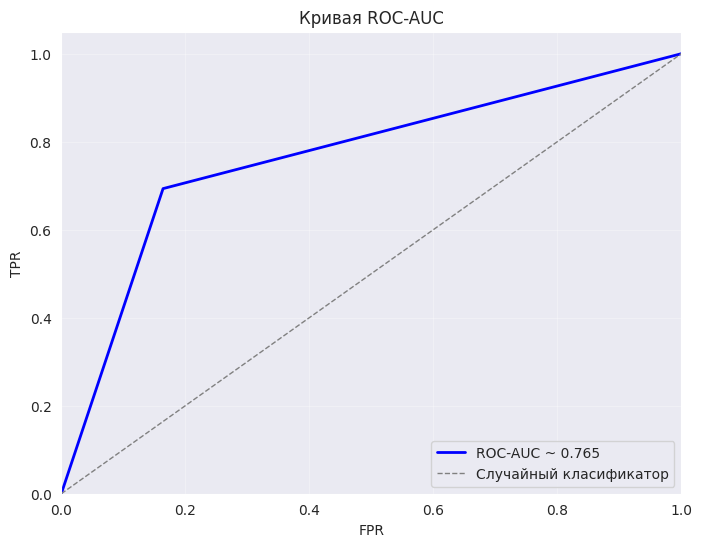

In [ ]:
plot_roc_curve(y_full['anomaly'].values, y_pred_if)

In [ ]:
get_classification_metrics(y['anomaly'].values, y_pred_if)

,0,1,accuracy,macro avg,weighted avg
precision,0.834574,0.695387,0.785882,0.764981,0.785744
recall,0.835846,0.693426,0.785882,0.764636,0.785882
f1-score,0.835210,0.694405,0.785882,0.764807,0.785812
support,12470.000000,6739.000000,0.785882,19209.000000,19209.000000


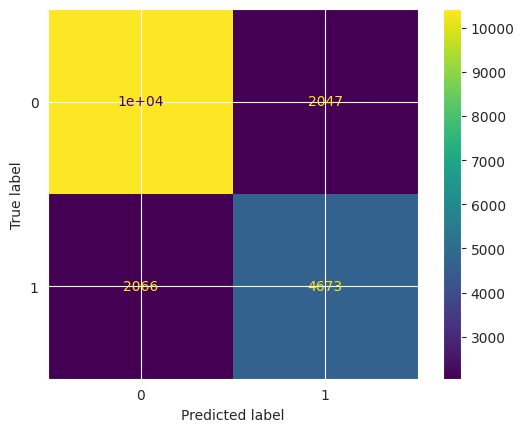

In [ ]:
plot_confusion_matrix(y, y_pred_if)

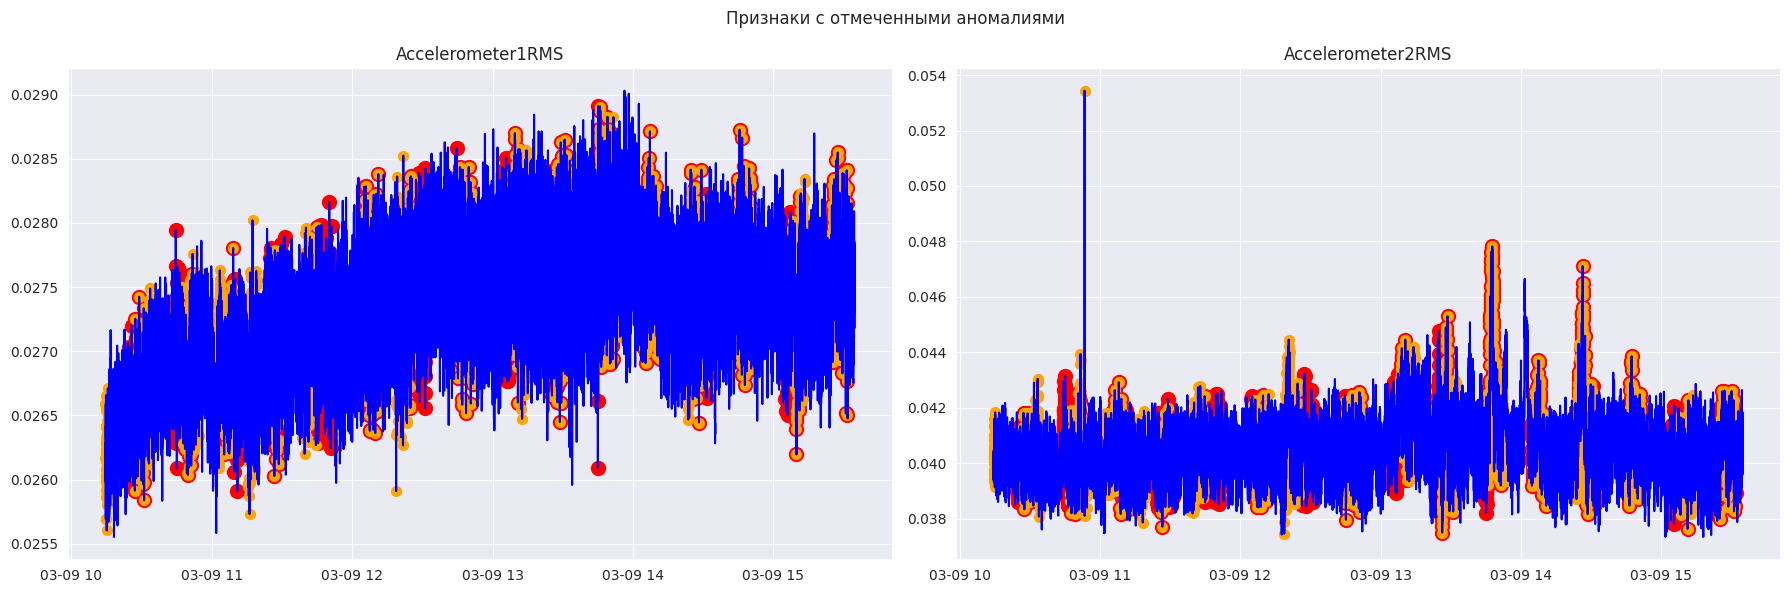

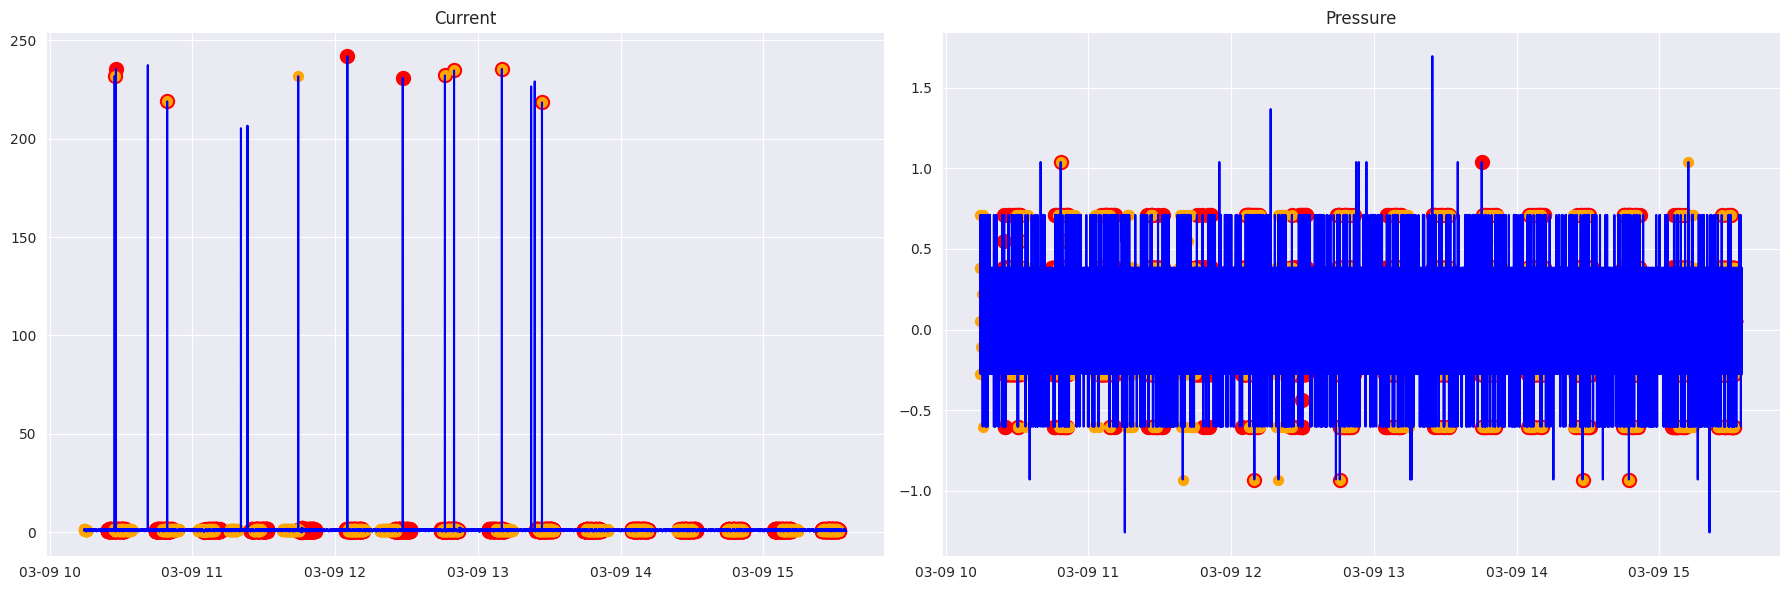

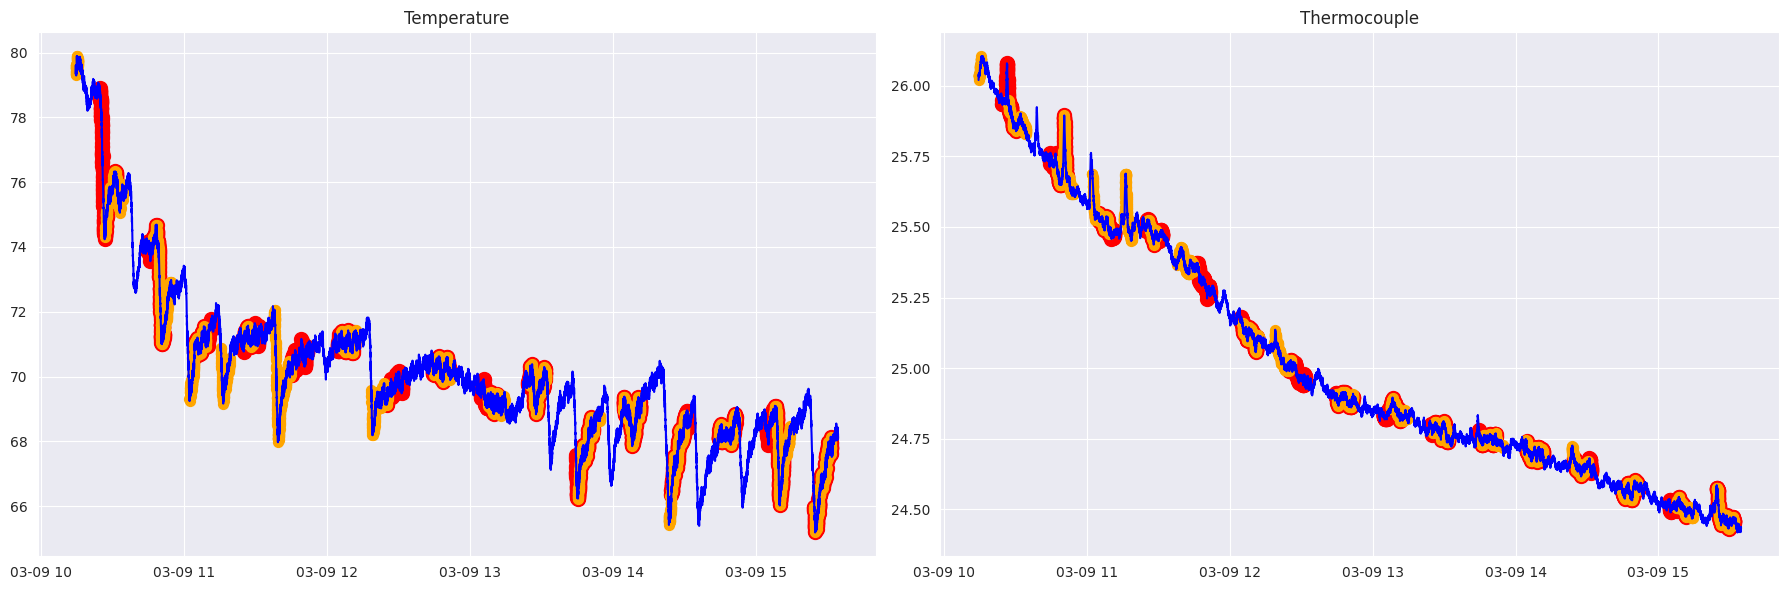

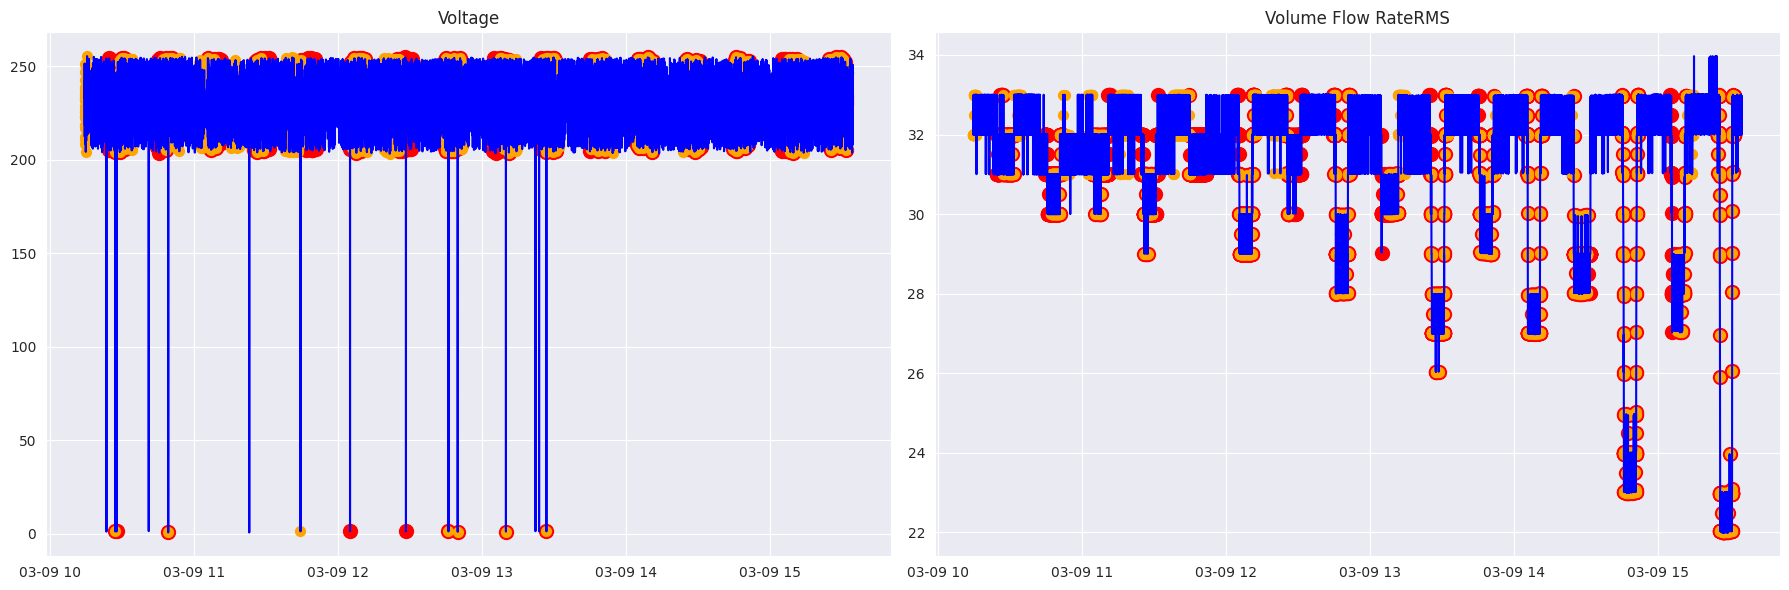

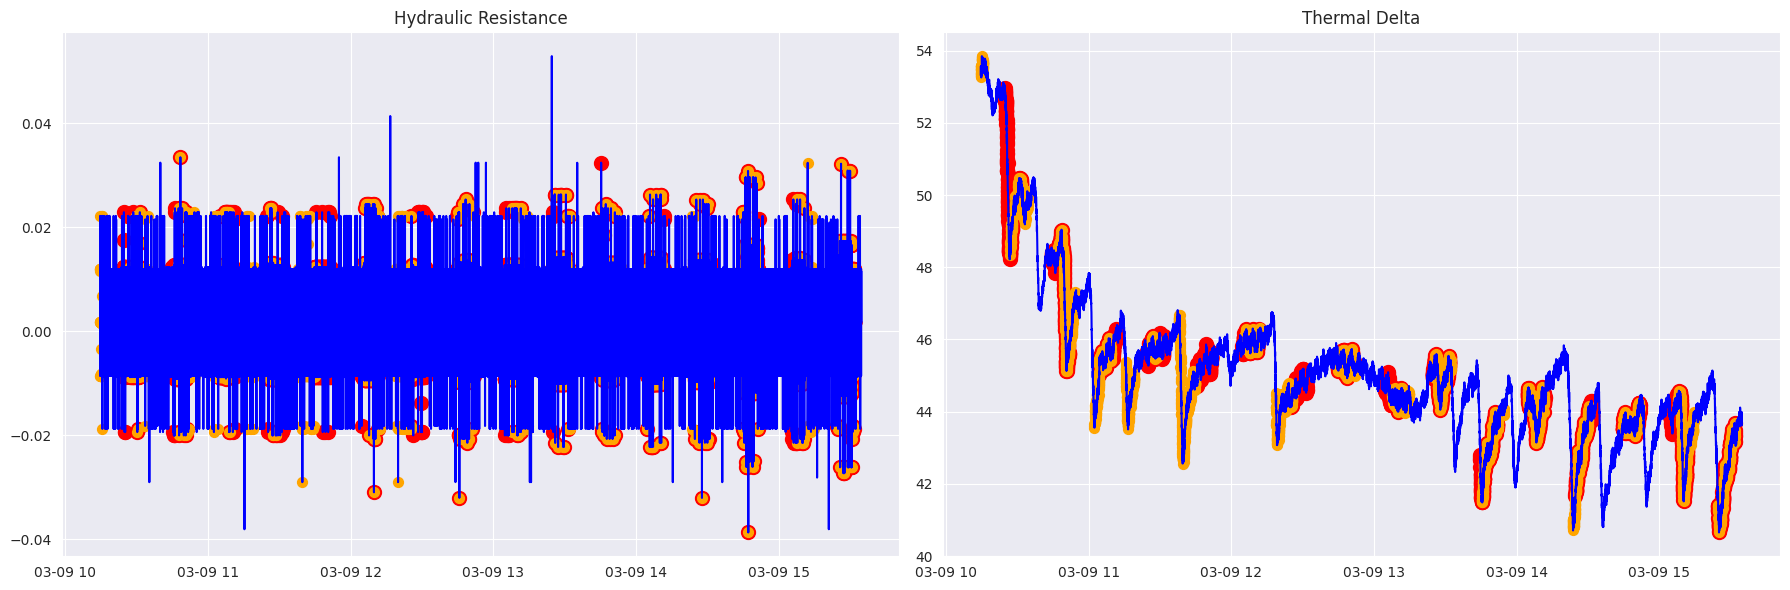

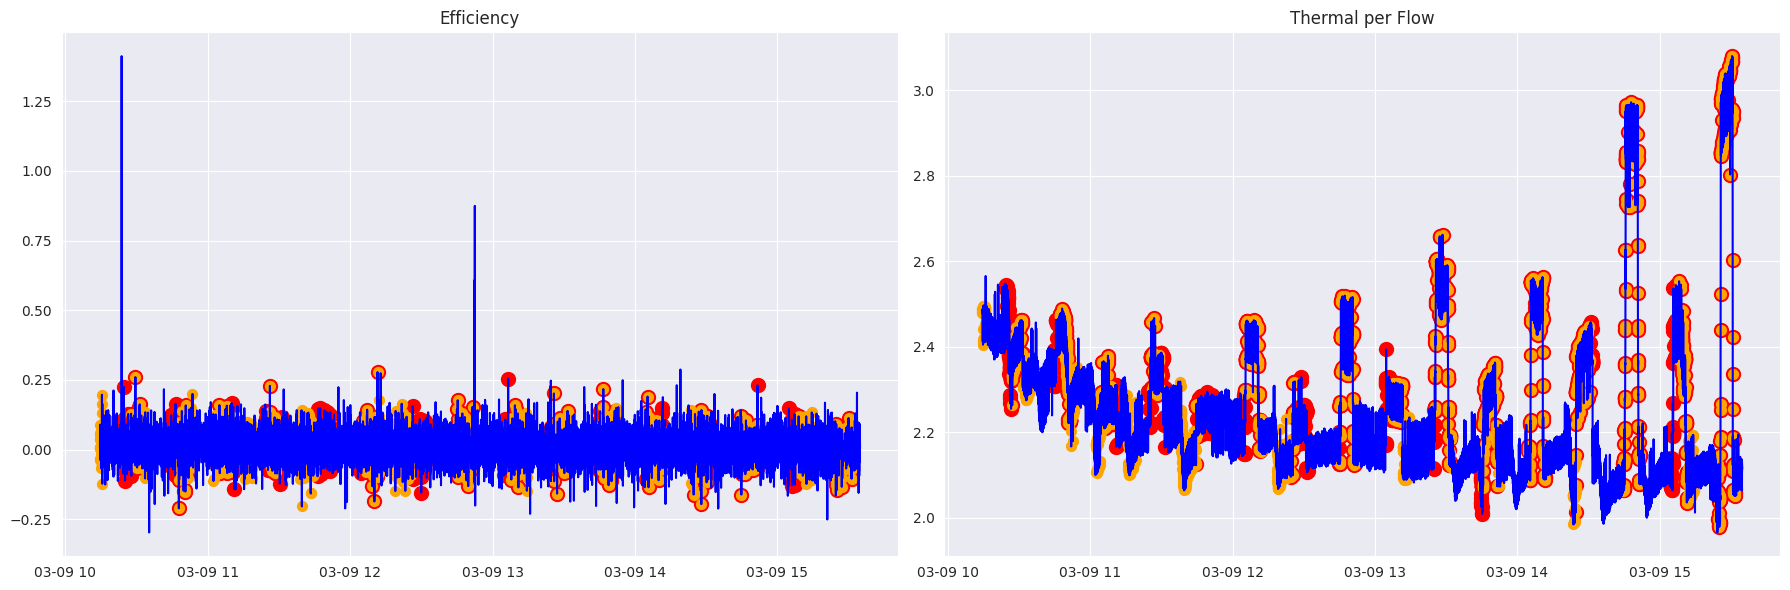

In [ ]:
plot_features_with_anomalies(
    pd.concat([X, y], axis=1),
    found_anomalies=y_pred_if,
    ncols=[2] * 6
)

Выводы:
- Вот, теперь совсем хорошо - precision с recall почти достигли значения 0.7
- ROC-AUC имеет значение в 0.765

Изоляционный лес оказался наилучшим алгоритмом из всех

## Нахождение точек изменений (changepoints)

Теперь переходим на нахождение точек изменения

Сначала напишем функцию для построения столбчатой диаграммы расстояний между найденными и ближайшими к ним реальными точками имзенения

In [ ]:
def plot_distances_distribution(changepoints, y_pred, figsize=(10, 5)):
    ax = plt.subplots(figsize=figsize)[1]
    sns.histplot(
        np.abs(
            np.concatenate(
                [changepoints[None, :] for _ in range(y_pred.shape[0])],
                axis=0
            ) - y_pred[:, None]
        ).min(axis=1),
        bins=20,
        ax=ax
      )
    plt.title('Распределение расстояний до ближайшего changepoint')
    plt.show()

Эта функция нужна для подсчёта различных метрик точек изменения

In [ ]:
def get_changepoints_metrics(changepoints, y_pred, margin=50, name='Random'):
    precision, recall = precision_recall(changepoints, y_pred, margin=margin)
    return pd.DataFrame({
        'hausdorff': [hausdorff(changepoints, y_pred).item()],
        'randindex': [randindex(list(changepoints), list(y_pred)).item()],
        'precision': [precision],
        'recall': [recall]
    }, index=[name])

Отобразим реальные точки изменения - видно, что у них есть некоторая периодичность

In [ ]:
changepoints = np.concatenate([
    np.where(y_full['changepoint'].values == 1)[0],
    [X.shape[0]]
])
changepoints

array([  600,   660,   960,  1020,  1800,  1860,  2160,  2221,  3067,
        3361,  3421,  4201,  4262,  4562,  4623,  5403,  5463,  5763,
        5823,  6603,  6663,  6964,  7023,  7803,  7863,  8163,  8224,
        9004,  9064,  9364,  9425, 10205, 10265, 10565, 10625, 11405,
       11465, 11765, 11826, 12606, 12666, 12966, 13026, 13806, 13867,
       14167, 14228, 15007, 15067, 15367, 15428, 16208, 16268, 16568,
       16628, 17408, 17468, 17768, 17828, 18608, 18669, 18969, 19029,
       19209])

### Метод снизу-вверх (BottomUp)

Первый алгоритм, который мы рассмотрим, называется BottomUp и его идея состоит в следующем:
1) Изначально каждая точка ряда является отдельным отрезком
2) Мы ищем такую пару соседних отрезков, что стоимость их объединения минимальна
   
   Стоимсоть $\large{c}$ одного отрезка $\large{d}$ в интервале [x, y] определяется следующим образом:
   $$\large{C([x,z])=\sum_{i=x}^y\left|\left|d_i - \overline{d}\right|\right|_2^2}$$

   Стоимость объединения отрезков $\large{a}$ и $\large{b}$ вычисляется так:
   $$\large{\triangle\left(a\cup b\right)=c\left(a\cup b\right) - c(a) - c(b)}$$
3) Далее эти 2 отрезка объединяяются
4) Пункты 2-3 применяются до тех пор, пока не будет достигнуто нужное число отрезков

Собственно, сами точки изменения - это границы между отрезками

На следующем рисунке визально представлен процесс работы алгоритма

![image.png](https://dev.ipol.im/~truong/ruptures-docs/build/html/_images/schema_tree.png)

In [ ]:
%%time
bottomUp = BottomUp(
    model='l2',
    min_size=50,
    jump=1
)
y_pred_bu =  np.array(bottomUp.fit_predict(X, n_bkps=64))

CPU times: user 554 ms, sys: 2.02 ms, total: 556 ms
Wall time: 586 ms


Теперь для полученного разбиения надо посчитать некоторые метрики. Я поясню, что значат первые 2:
1) Индекс Хаусдорффа - вычисляет наибольшую ошибку предсказания
   
   Пусть есть набор реальных $\large{t}$ и предскзанных $\large{\hat{t}}$ точек изменения, тогда индекс вычисляется следующим образом:
   
   $$\large{Hausdorff(t, \hat{t})=max\left(\underset{k}{max}\ \underset{l}{min}\left|t_k-\hat{t}_l\right|, \underset{k}{max}\ \underset{l}{min}\left|\hat{t}_k-t_l\right|\right)}$$

   Это очень строгая метрика - то есть даже при одном неудачном предсказании она будет игнорировать все остальные предсказания, которые могли оказаться очень хорошими

2) Индекс Рэнда - вычисляет похожесть сегментации на исходное разбиение

   Итак, пусть $\large{S}$ - исходное разбиение, а $\large{\hat{S}}$ - полученная сегментация, тогда матрица ассоциаций $\large{A}$ для исходного разбиения вычисляется следующим образом:

   $$\large{A_{ij}=\begin{cases}1 \ , \ если \ точки \ i \ и \ j \ находятся \ в \ одном \ отрезке \ в \ исходном \ разбиении \\ 0 \ , \ иначе \end{cases}}$$

   Аналогично вычисляется матрица ассоциаций и для сегментации:

   $$\large{\hat{A}_{ij}=\begin{cases}1 \ , \ если \ точки \ i \ и \ j \ находятся \ в \ одном \ отрезке \ в \ полученной \ сегментации \\ 0 \ , \ иначе \end{cases}}$$

   Тогда индекс Рэнда вычисляется очень просто по следующей формуле:
   $$\large{Rand(t, \hat{t})=\frac{\sum_{i<j}\mathbf{1}\left[A_{ij}=\hat{A}_{ij}\right]}{\frac{T(T-1)}{2}}}$$

   Индекс принимает значения от 0 до 1 и чем больше значение, тем более похожими считаются разбиения

3) Так как сам индекс точки перегиба предсказать очень трудно, то в precision и recall индекс точки перегиба считается правильно предсказанным, если отстоит хотя бы от одного из реальных индексов на занчение, не превышающее задаваемый пользователем порог $\large{s}$ (вмоём случае я определил значение этого порога в 50)

In [ ]:
get_changepoints_metrics(
    changepoints,
    y_pred_bu,
    name=[bottomUp.__class__.__name__]
)

,hausdorff,randindex,precision,recall
BottomUp,377.0,0.979801,0.390625,0.396825


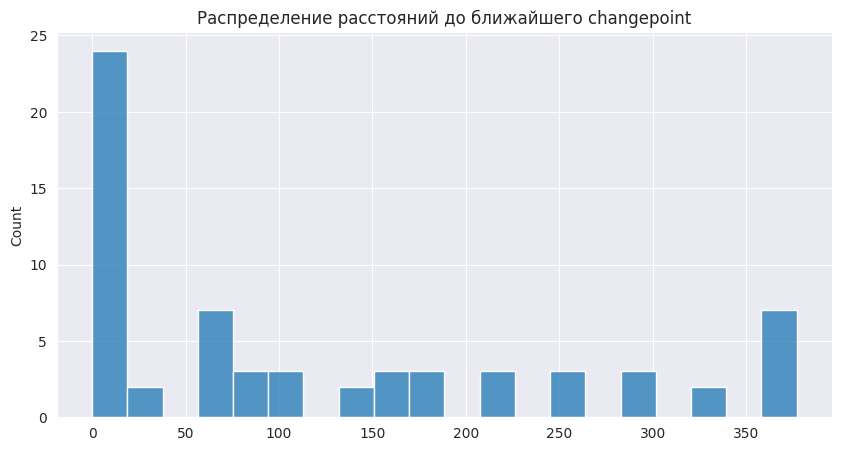

In [ ]:
plot_distances_distribution(changepoints, y_pred_bu)

Визуализируем точки изменения. Фиолетовым отчечены реальные, а жёлтым - найденные

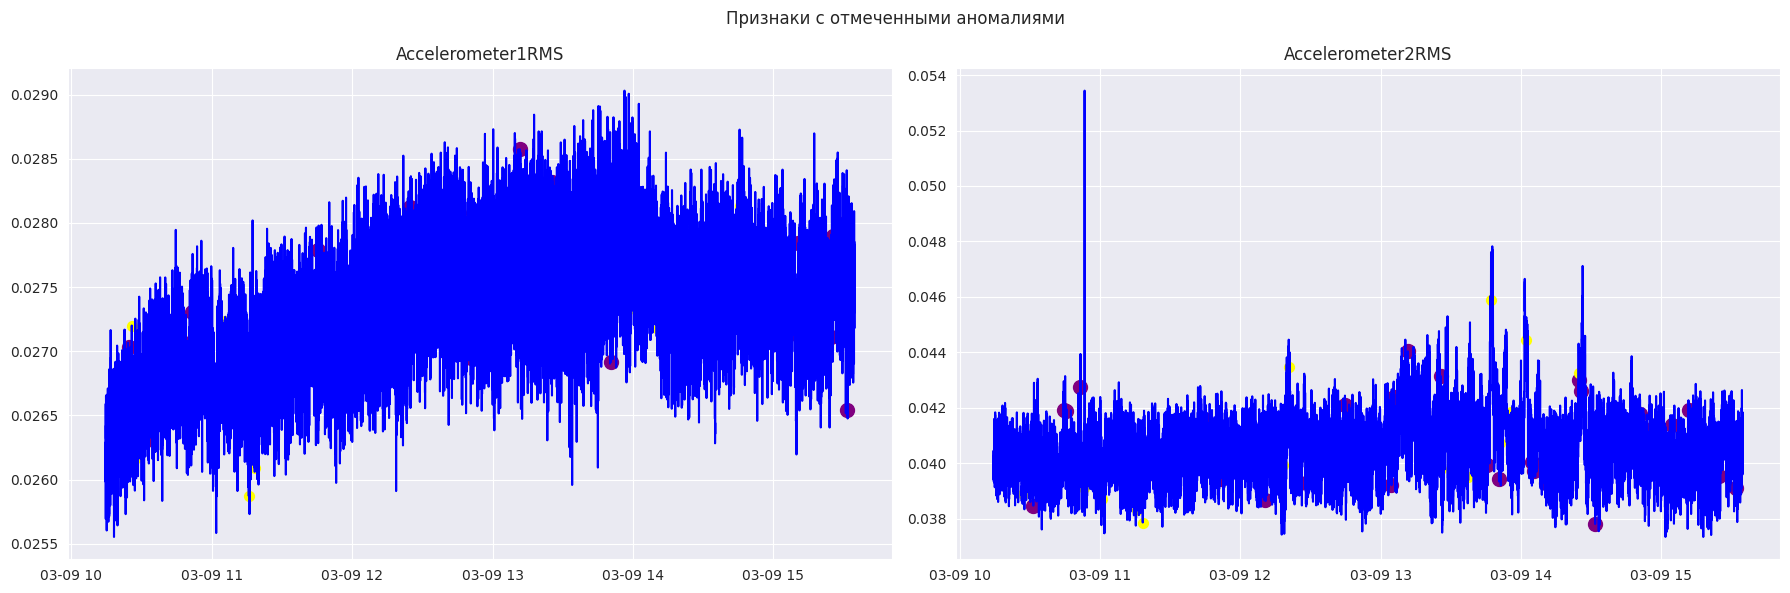

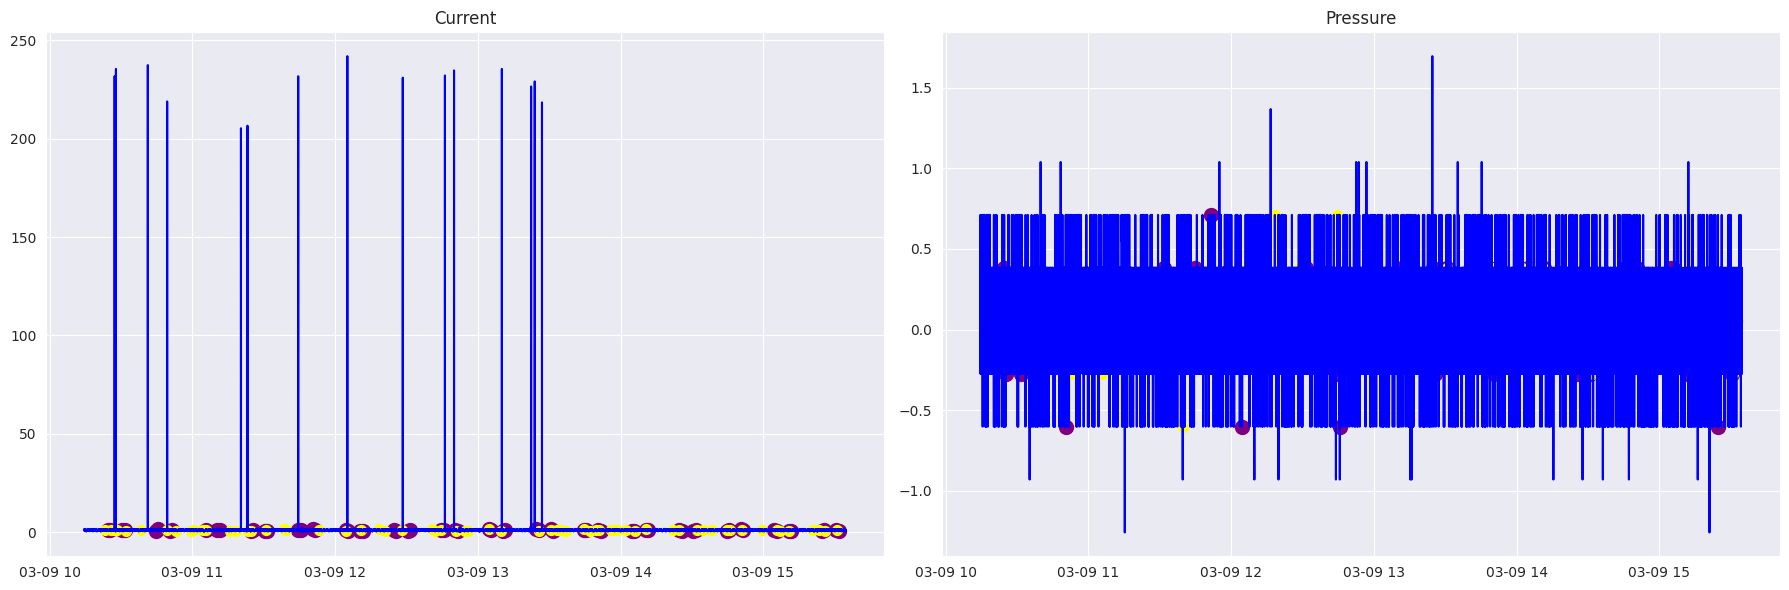

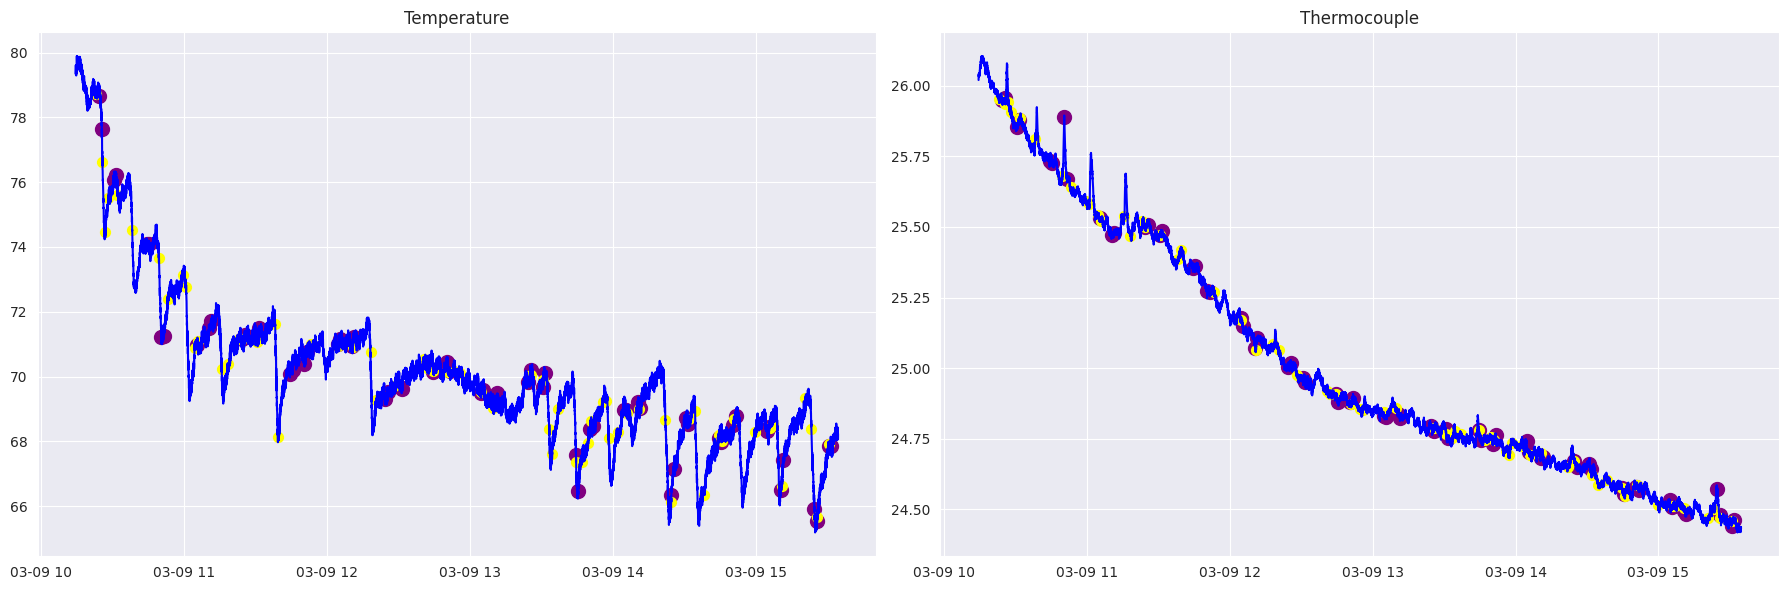

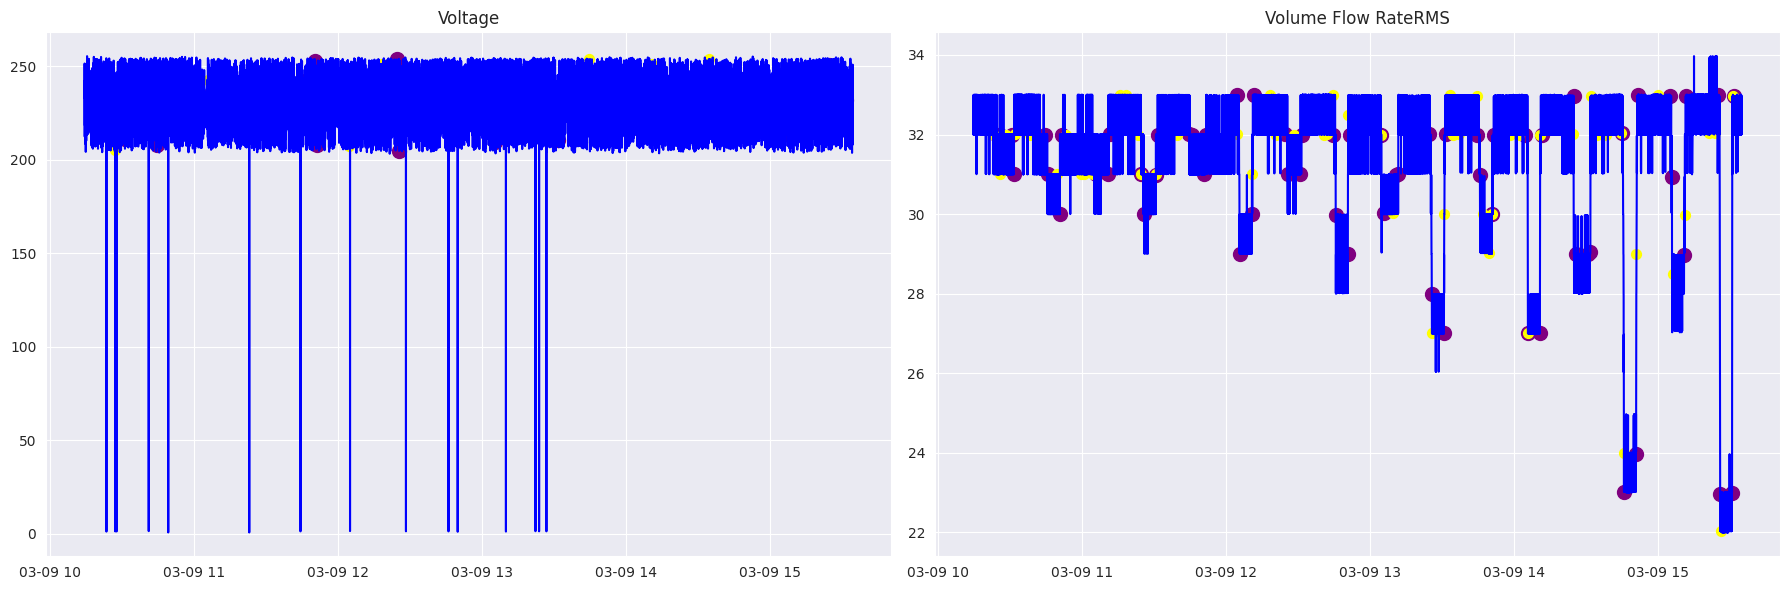

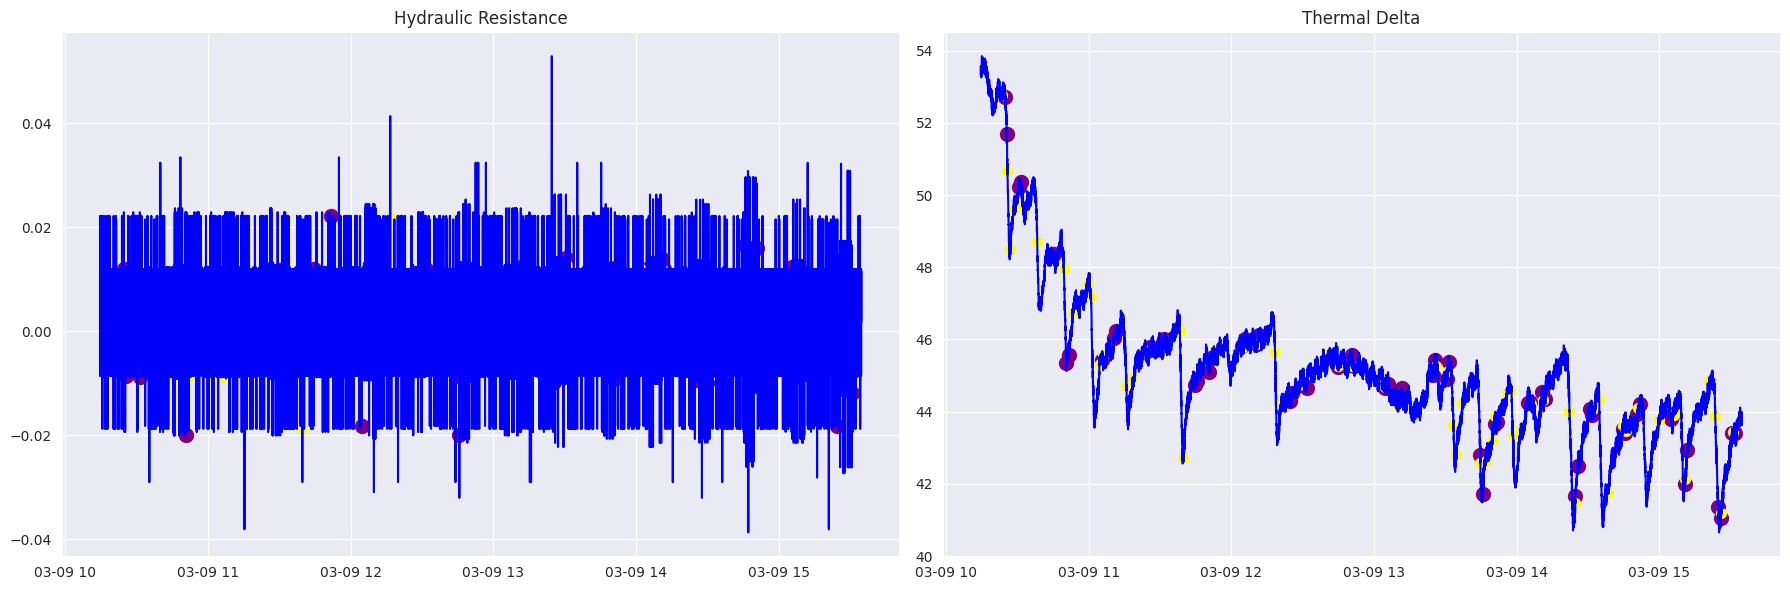

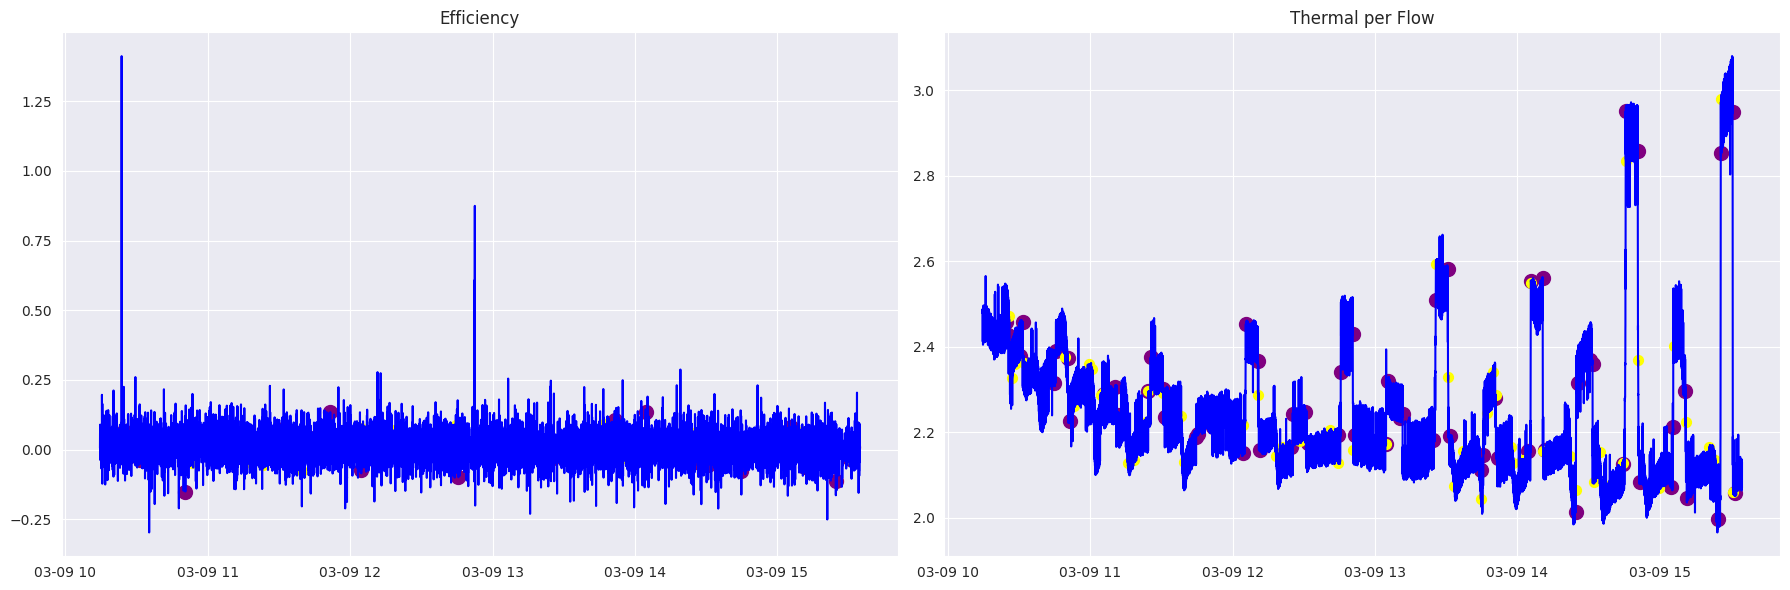

In [ ]:
plot_features_with_anomalies(
    pd.concat([X, y], axis=1),
    plot_anomalies=False,
    plot_changepoints=True,
    found_changepoints=y_pred_bu,
    ncols=[2] * 6
)

Выводы:
- Большинство расстояний до ближайшей точки изменения сосредоточены недалеко от нуля
- Индекс Рэнда - очень высокий, что говорит о том, что исходное и полученное разбиение очень похожи
- С учётом расстояния $\large{m=50}$ значения метрик precision и recall равняются почти 0.4, что не так уж плохо

### Метод бинарной сегментации

Второй рассматриваемый алгоритм - алгоритм бинарной сегментации (он по своему порядку противоположен BottomUp). Итак, идея алгоритма в следующем:
1) Изначально весь ряд - единый отрезок $\large{[x, y]}$
2) Далее ищется такая точка $\large{t}$, что выигрыш при разделении отрезка по ней максимален (выигрыш здесь - это уменьшение неоднородности)
    
   При неизменной формуле стоимости одного отрезка выигрыш для точки $\large{t}$ высчитывается следующим образом:
   $$\large{c(a;b;t)=c(a;b)-c(a;t)-c(t;b)}$$
3) Далее каждый из отрезков разбиывается на 2 части аналогичным образом
4) Пункты 2-3 повторяются до тех пор, пока не будет достигнуто нужно число отрезков

На следующем рисунке визуально представлен процесс работы алгоритма

![image.png](https://dev.ipol.im/~truong/ruptures-docs/build/html/_images/schema_binseg.png)

In [ ]:
%%time
binseg = Binseg(
    model='l2',
    min_size=50,
    jump=1
)
y_pred_bs =  np.array(binseg.fit_predict(X, n_bkps=64))

CPU times: user 3min, sys: 162 ms, total: 3min
Wall time: 3min 22s


In [ ]:
get_changepoints_metrics(
    changepoints,
    y_pred_bs,
    name=[binseg.__class__.__name__]
)

,hausdorff,randindex,precision,recall
Binseg,477.0,0.979288,0.46875,0.47619


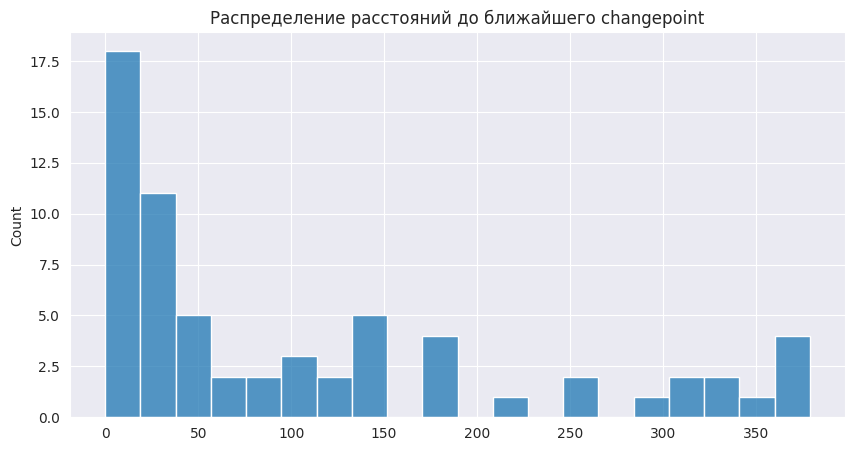

In [ ]:
plot_distances_distribution(changepoints, y_pred_bs)

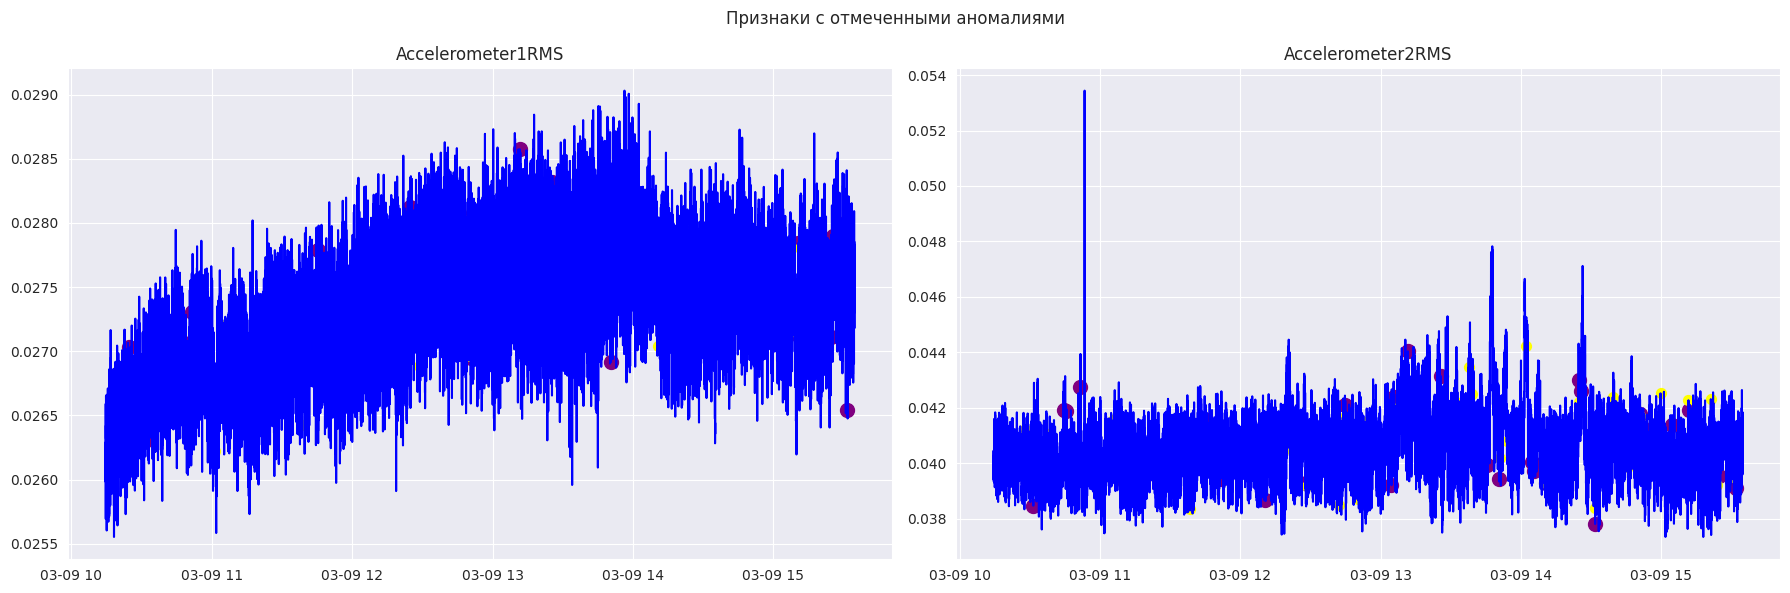

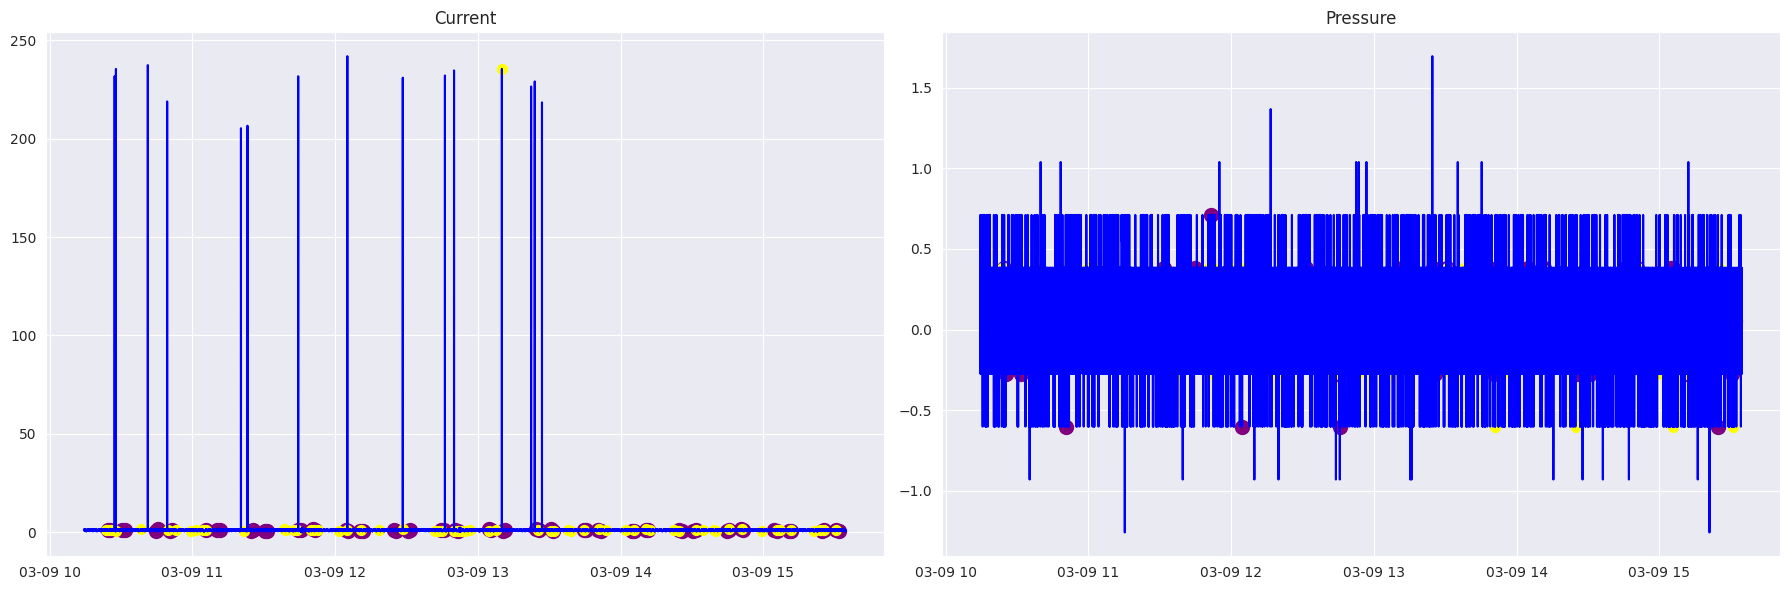

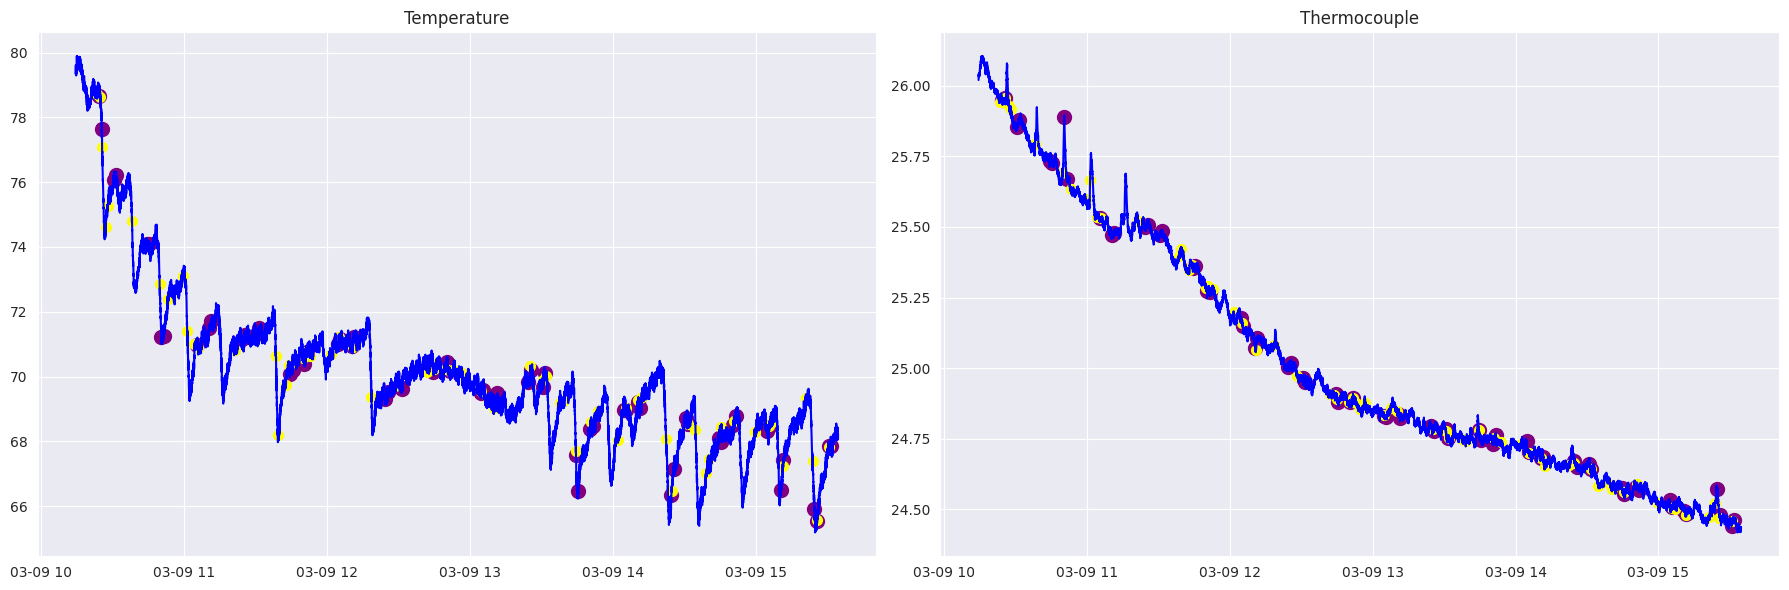

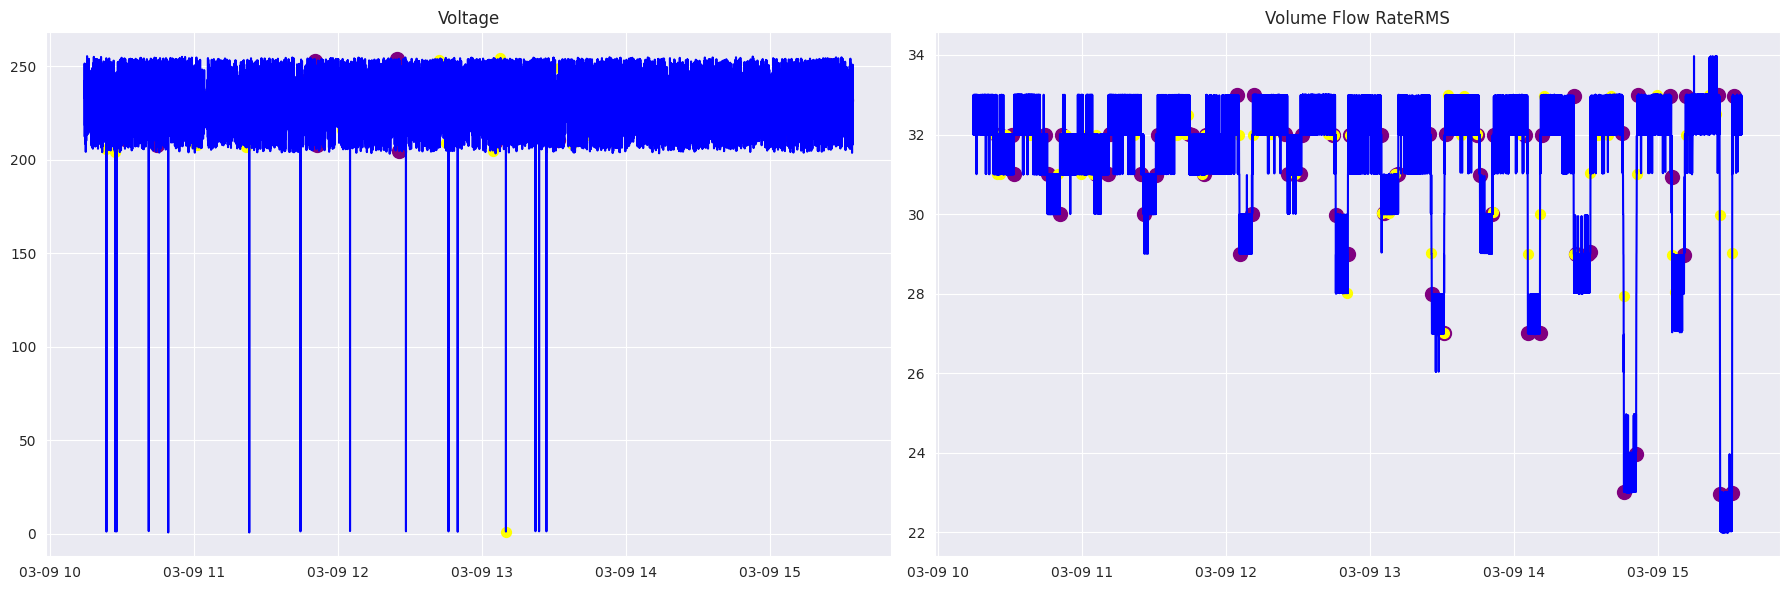

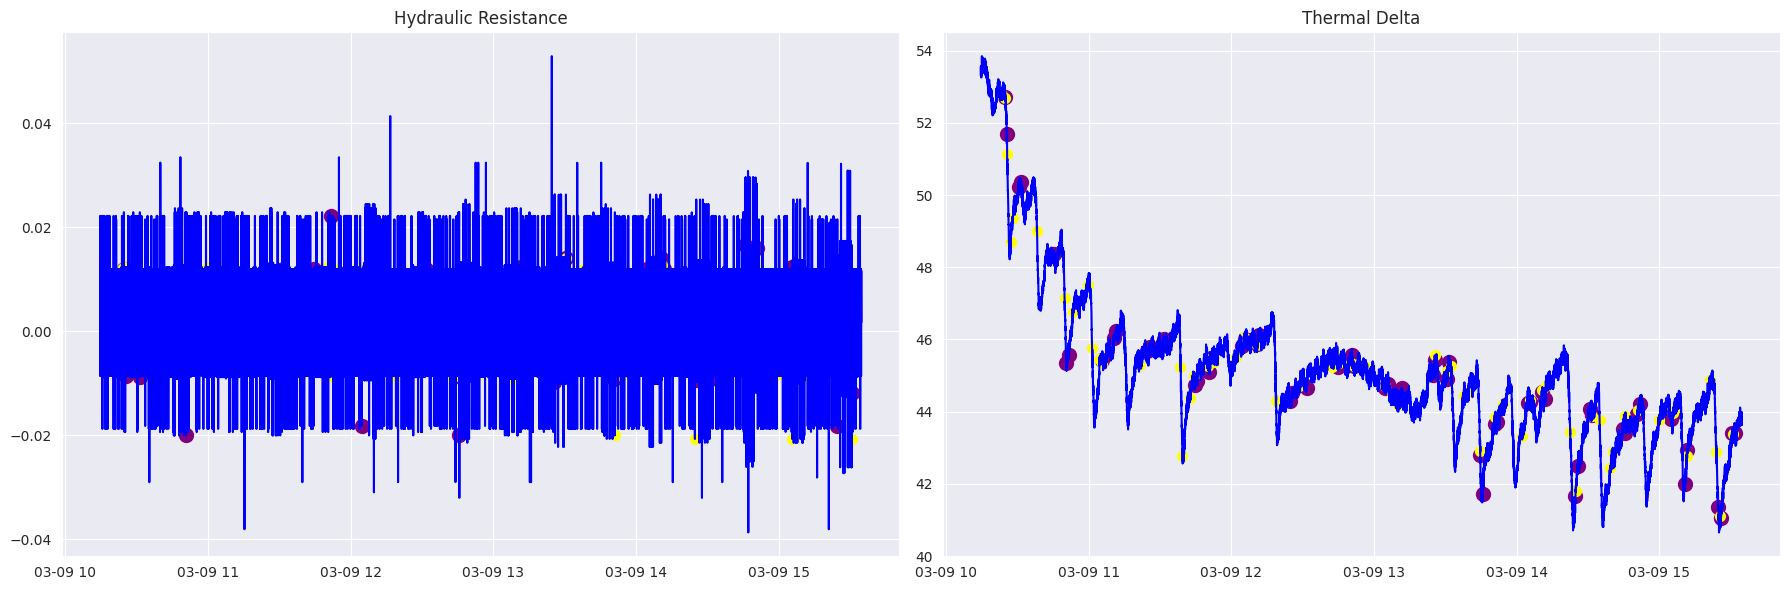

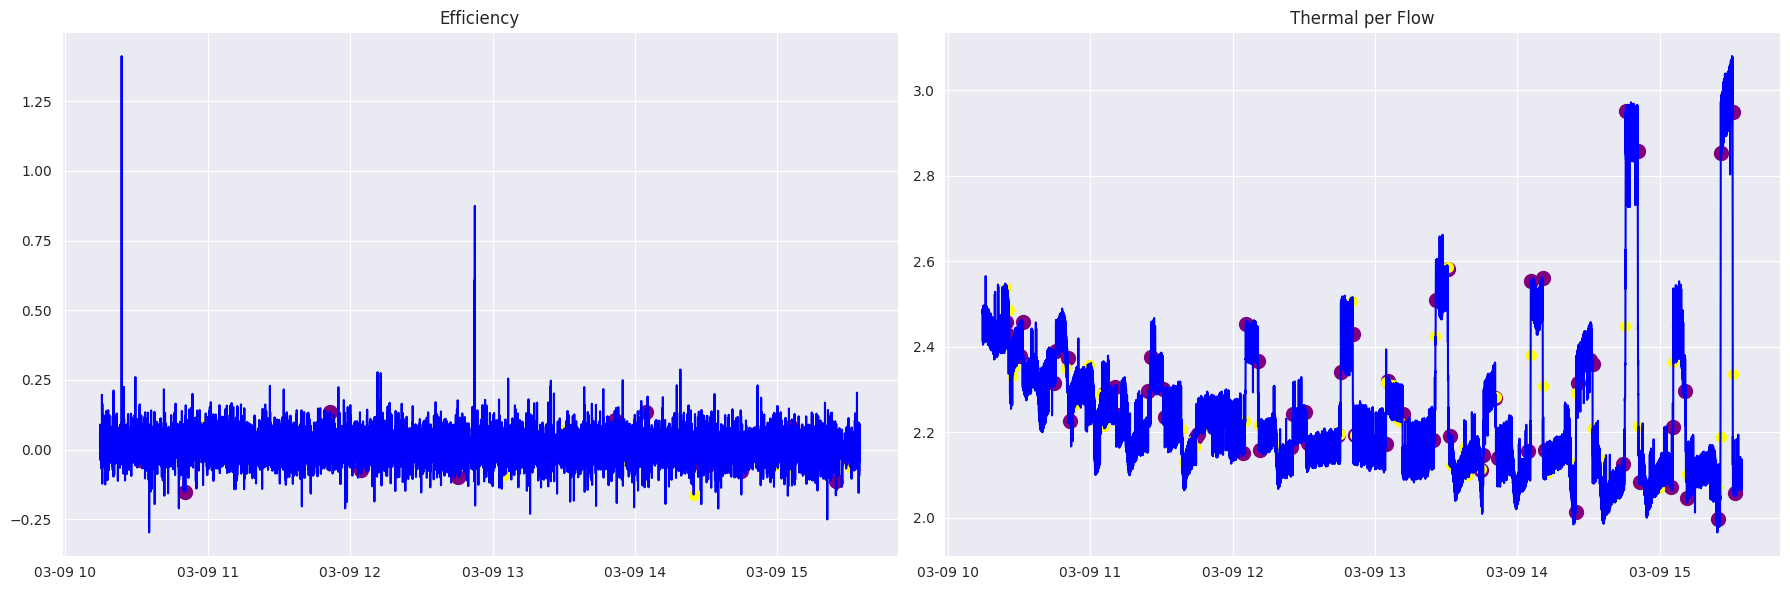

In [ ]:
plot_features_with_anomalies(
    pd.concat([X, y], axis=1),
    plot_anomalies=False,
    plot_changepoints=True,
    found_changepoints=y_pred_bs,
    ncols=[2] * 6
)

Выводы:
- Большинство расстояний до ближайшей точки изменения всё также сосредоточены недалеко от нуля, только теперь расстояниях, которые ближе к 0, стало больше
- Индекс Рэнда ещё выше, чем в предыдущем случае
- Значения метрик precision и recall ещё подросли по сравнению со случаем BottomUp

То есть если судить по метрикам и столбчатой диаграмме расстояний, то алгоритм бинарной сегментации отработал лучше

# Выводы
В данной лабораторной работе был проведён анализ данных, добавлены ноавые признаки, с помощью моделей cLSTM и cMLP было сделано предположение о том, как одни пизнаки влияют на предсказание других

С помощью алгоритмов матричного профиля, K-Means и изоляционного леса был проведён поиск аномалий, лучшим оказался случайный лес. Эти алгоритмы были выбраны из-за их разной природы, частой используемости в таких задачах и скорости

Далее с помошью алгоритмов BottomUp и бинарной сегментации был осуществлён поиск точек изменений в данных и бинарная сегментация оказалась лучше. Эти алгоритмы были выбраны за свою простоту и скорость

В качестве улучшений можно предложить:
- Создание новых признаков, более отражающих суть проведения эксперимента
- Оптимизация другой метрики (ROC-AUC, например)
- Исследование важности признаков в контексте поиска аномалий - то есть то, какие признаки в большей степени на поиск влияют
- Добавление других новых алгоритмов или даже использование ансамблевого алгоритма поиска аномалий